# State Punishment Analysis Notebook
# ===================================

This notebook provides tools for analyzing TensorBoard results from state punishment experiments.
It includes data processing, visualization, and statistical analysis functions.

## Table of Contents
1. [Imports and Dependencies](#1-imports-and-dependencies)
2. [TensorBoard Data Processing](#2-tensorboard-data-processing)
3. [Data Analysis Utilities](#3-data-analysis-utilities)
4. [Visualization Functions](#4-visualization-functions)
5. [Statistical Analysis](#5-statistical-analysis)
6. [Data Processing Pipeline](#6-data-processing-pipeline)
7. [Example Analysis](#7-example-analysis)


## 1. Imports and Dependencies


In [1]:
# Core data processing and visualization
from scipy.stats import zscore

import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import itertools
import time
from collections import defaultdict

# TensorFlow for TensorBoard processing
import tensorflow as tf
from tensorflow.python.framework.errors_impl import DataLossError

# Statistical analysis
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import pingouin as pg

# Set plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All imports successful!")


/Users/socialai/miniconda3/envs/sorrel/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Users/socialai/miniconda3/envs/sorrel/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Users/socialai/miniconda3/envs/sorrel/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/resource_han

All imports successful!


## 2. TensorBoard Data Processing


In [2]:
def tensorboard_to_csv(event_file, csv_file):
    """
    Convert TensorBoard event file data to a CSV format.

    Args:
        event_file (str): Path to the TensorBoard event file (e.g., events.out.tfevents.xxx).
        csv_file (str): Path where the output CSV file should be saved.
    """
    data_rows = []
    
    # Use tf.compat.v1 to access the summary_iterator in TensorFlow 2.x
    for e in tf.compat.v1.train.summary_iterator(event_file):
        for v in e.summary.value:
            # Only consider scalar summaries
            if v.HasField('simple_value'):
                tag = v.tag
                value = v.simple_value
                step = e.step
                data_rows.append([step, tag, value])
    
    # Write the extracted data into a CSV file
    with open(csv_file, 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Step', 'Tag', 'Value'])
        writer.writerows(data_rows)
    
    print(f"Data from {event_file} has been written to {csv_file}")


In [3]:
def tensorboard_to_separate_csv(event_file, output_dir):
    """
    Convert TensorBoard event file to separate CSV files for each metric.
    
    Args:
        event_file (str): Path to the TensorBoard event file
        output_dir (str): Directory where CSV files should be saved
    """
    tag_data = defaultdict(list)

    try:
        for e in tf.compat.v1.train.summary_iterator(event_file):
            try:
                for v in e.summary.value:
                    if v.HasField('simple_value'):
                        tag = v.tag
                        value = v.simple_value
                        step = e.step
                        tag_data[tag].append([step, value])
            except Exception as record_error:
                print(f"Skipped a corrupt record in file: {event_file}")
    except DataLossError:
        print(f"Encountered DataLossError. Possibly due to incomplete writes in file: {event_file}")

    # Save tag data to CSV files
    for tag, data_rows in tag_data.items():
        filename = f"{output_dir}/{tag.replace('/', '_')}_data.csv"
        with open(filename, 'w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['Step', 'Value'])
            writer.writerows(data_rows)
        print(f"Data for tag '{tag}' has been written to {filename}")


In [4]:
def is_file_stable(file_path, wait_time=1.0):
    """Check if a file is stable (not being written to)."""
    initial_size = os.path.getsize(file_path)
    time.sleep(wait_time)
    final_size = os.path.getsize(file_path)
    return initial_size == final_size

def process_tensorboard_results(parent_dir, output_parent_dir):
    """
    Process all TensorBoard files in a directory structure.
    
    Args:
        parent_dir (str): Parent directory containing TensorBoard event files
        output_parent_dir (str): Parent directory where CSV files should be saved
    """
    for root, dirs, files in os.walk(parent_dir):
        print(root, dirs, files)
        for file in files:
            if "tfevents" in file:
                event_file = os.path.join(root, file)
                relative_path = os.path.relpath(root, parent_dir)
                output_dir = os.path.join(output_parent_dir, relative_path)
                os.makedirs(output_dir, exist_ok=True)

                try:
                    tensorboard_to_separate_csv(event_file, output_dir)
                    print(f"Processed {event_file} -> {output_dir}")
                except Exception as e:
                    print(f"Failed to process {event_file}: {e}")


## 3. Data Analysis Utilities


In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


# def bidirectional_change_prediction(
#     s_t,
#     x_t,
#     H=500,
#     K=10,
#     standardize=True,
#     hac=True,
#     hac_maxlags=None,
# ):
#     """
#     Single-window bidirectional change-prediction test.

#     Model 1:
#         future Δs = s[t+H] - s[t]
#         predicted by x-history + s-history

#     Model 2:
#         future Δx = x[t+H] - x[t]
#         predicted by s-history + x-history
#     """

#     s = np.asarray(s_t, dtype=float)
#     x = np.asarray(x_t, dtype=float)

#     if len(s) != len(x):
#         raise ValueError("s_t and x_t must have the same length.")

#     df = pd.DataFrame({"s": s, "x": x})
#     df = df.replace([np.inf, -np.inf], np.nan).dropna()

#     if standardize:
#         for col in ["s", "x"]:
#             sd = df[col].std()
#             if sd == 0 or np.isnan(sd):
#                 raise ValueError(f"{col} has zero or undefined variance.")
#             df[col] = (df[col] - df[col].mean()) / sd

#     df["future_ds"] = df["s"].shift(-H) - df["s"]
#     df["future_dx"] = df["x"].shift(-H) - df["x"]

#     for lag in range(K + 1):
#         df[f"s_lag{lag}"] = df["s"].shift(lag)
#         df[f"x_lag{lag}"] = df["x"].shift(lag)

#     df = df.dropna().copy()

#     if len(df) < max(30, 3 * (2 * (K + 1) + 1)):
#         raise ValueError("Too few observations for this H/K/window combination.")

#     if hac:
#         if hac_maxlags is None:
#             hac_maxlags = H
#         cov_type = "HAC"
#         cov_kwds = {"maxlags": hac_maxlags}
#     else:
#         cov_type = "nonrobust"
#         cov_kwds = None

#     # ---------------------------------------------------------------------
#     # Model 1: x history -> future Δs, controlling s history
#     # ---------------------------------------------------------------------
#     x_terms = [f"x_lag{lag}" for lag in range(K + 1)]
#     s_terms = [f"s_lag{lag}" for lag in range(K + 1)]

#     X1_terms = x_terms + s_terms
#     X1 = sm.add_constant(df[X1_terms])
#     y1 = df["future_ds"]

#     if hac:
#         model_x_to_ds = sm.OLS(y1, X1).fit(cov_type=cov_type, cov_kwds=cov_kwds)
#     else:
#         model_x_to_ds = sm.OLS(y1, X1).fit()

#     hypothesis_x = " = 0, ".join(x_terms) + " = 0"
#     joint_x_to_ds = model_x_to_ds.f_test(hypothesis_x)

#     coef_x_to_ds = pd.DataFrame({
#         "coef": model_x_to_ds.params,
#         "std_err": model_x_to_ds.bse,
#         "t": model_x_to_ds.tvalues,
#         "p": model_x_to_ds.pvalues,
#     })

#     # ---------------------------------------------------------------------
#     # Model 2: s history -> future Δx, controlling x history
#     # ---------------------------------------------------------------------
#     X2_terms = s_terms + x_terms
#     X2 = sm.add_constant(df[X2_terms])
#     y2 = df["future_dx"]

#     if hac:
#         model_s_to_dx = sm.OLS(y2, X2).fit(cov_type=cov_type, cov_kwds=cov_kwds)
#     else:
#         model_s_to_dx = sm.OLS(y2, X2).fit()

#     hypothesis_s = " = 0, ".join(s_terms) + " = 0"
#     joint_s_to_dx = model_s_to_dx.f_test(hypothesis_s)

#     coef_s_to_dx = pd.DataFrame({
#         "coef": model_s_to_dx.params,
#         "std_err": model_s_to_dx.bse,
#         "t": model_s_to_dx.tvalues,
#         "p": model_s_to_dx.pvalues,
#     })

#     return {
#         "data": df,
#         "model_x_to_delta_s": model_x_to_ds,
#         "model_s_to_delta_x": model_s_to_dx,
#         "coef_x_to_delta_s": coef_x_to_ds,
#         "coef_s_to_delta_x": coef_s_to_dx,
#         "joint_x_to_delta_s": joint_x_to_ds,
#         "joint_s_to_delta_x": joint_s_to_dx,
#         "x_terms": x_terms,
#         "s_terms": s_terms,
#     }


def rolling_bidirectional_change_prediction_full(
    s_t,
    x_t,
    window_size=10000,
    step_size=1000,
    H=500,
    K=10,
    standardize=True,
    hac=True,
    hac_maxlags=None,
    min_obs=None,
    keep_errors=True,
):
    """
    Rolling bidirectional change-prediction.

    Returns:
        rolling_stats : dataframe
            One row per rolling window.
            Contains:
                - all focal lag coefficients
                - all focal lag p-values
                - joint p-values
                - R² and adjusted R²
                - coefficient sums/means

        all_coef_long : dataframe
            Long-form coefficient table:
                window × direction × lag × coef/std_err/t/p
    """

    s = np.asarray(s_t, dtype=float)
    x = np.asarray(x_t, dtype=float)

    if len(s) != len(x):
        raise ValueError("s_t and x_t must have the same length.")

    n = len(s)

    if min_obs is None:
        min_obs = max(30, 3 * (2 * (K + 1) + 1))

    rows = []
    coef_rows = []

    for window_id, start in enumerate(range(0, n - window_size + 1, step_size)):
        end = start + window_size
        center = (start + end) / 2

        s_win = s[start:end]
        x_win = x[start:end]

        base_row = {
            "window_id": window_id,
            "start": start,
            "end": end,
            "center": center,
            "H": H,
            "K": K,
            "window_size": window_size,
            "step_size": step_size,
            "success": True,
            "error": "",
        }

        try:
            res = bidirectional_change_prediction(
                s_t=s_win,
                x_t=x_win,
                H=H,
                K=K,
                standardize=standardize,
                hac=hac,
                hac_maxlags=hac_maxlags,
            )

            df_used = res["data"]
            if len(df_used) < min_obs:
                raise ValueError(f"Too few usable observations: {len(df_used)}")

            coef_x_to_ds = res["coef_x_to_delta_s"]
            coef_s_to_dx = res["coef_s_to_delta_x"]

            model_x_to_ds = res["model_x_to_delta_s"]
            model_s_to_dx = res["model_s_to_delta_x"]

            x_terms = res["x_terms"]
            s_terms = res["s_terms"]

            row = base_row.copy()
            row["n_obs"] = len(df_used)

            # Model-level rolling stats
            row["x_to_delta_s_r2"] = model_x_to_ds.rsquared
            row["x_to_delta_s_adj_r2"] = model_x_to_ds.rsquared_adj
            row["x_to_delta_s_joint_F"] = float(res["joint_x_to_delta_s"].fvalue)
            row["x_to_delta_s_joint_p"] = float(res["joint_x_to_delta_s"].pvalue)

            row["s_to_delta_x_r2"] = model_s_to_dx.rsquared
            row["s_to_delta_x_adj_r2"] = model_s_to_dx.rsquared_adj
            row["s_to_delta_x_joint_F"] = float(res["joint_s_to_delta_x"].fvalue)
            row["s_to_delta_x_joint_p"] = float(res["joint_s_to_delta_x"].pvalue)

            # Focal-block summaries
            row["x_to_delta_s_sum_coef"] = coef_x_to_ds.loc[x_terms, "coef"].sum()
            row["x_to_delta_s_mean_coef"] = coef_x_to_ds.loc[x_terms, "coef"].mean()
            row["x_to_delta_s_median_coef"] = coef_x_to_ds.loc[x_terms, "coef"].median()

            row["s_to_delta_x_sum_coef"] = coef_s_to_dx.loc[s_terms, "coef"].sum()
            row["s_to_delta_x_mean_coef"] = coef_s_to_dx.loc[s_terms, "coef"].mean()
            row["s_to_delta_x_median_coef"] = coef_s_to_dx.loc[s_terms, "coef"].median()

            # Store every focal lag coefficient and p-value in wide form
            for lag in range(K + 1):
                xt = f"x_lag{lag}"
                st = f"s_lag{lag}"

                row[f"x_to_delta_s_coef_lag{lag}"] = coef_x_to_ds.loc[xt, "coef"]
                row[f"x_to_delta_s_se_lag{lag}"] = coef_x_to_ds.loc[xt, "std_err"]
                row[f"x_to_delta_s_t_lag{lag}"] = coef_x_to_ds.loc[xt, "t"]
                row[f"x_to_delta_s_p_lag{lag}"] = coef_x_to_ds.loc[xt, "p"]

                row[f"s_to_delta_x_coef_lag{lag}"] = coef_s_to_dx.loc[st, "coef"]
                row[f"s_to_delta_x_se_lag{lag}"] = coef_s_to_dx.loc[st, "std_err"]
                row[f"s_to_delta_x_t_lag{lag}"] = coef_s_to_dx.loc[st, "t"]
                row[f"s_to_delta_x_p_lag{lag}"] = coef_s_to_dx.loc[st, "p"]

                coef_rows.append({
                    "window_id": window_id,
                    "start": start,
                    "end": end,
                    "center": center,
                    "direction": "x_to_delta_s",
                    "predictor": "x",
                    "lag": lag,
                    "term": xt,
                    "coef": coef_x_to_ds.loc[xt, "coef"],
                    "std_err": coef_x_to_ds.loc[xt, "std_err"],
                    "t": coef_x_to_ds.loc[xt, "t"],
                    "p": coef_x_to_ds.loc[xt, "p"],
                    "joint_p": float(res["joint_x_to_delta_s"].pvalue),
                    "joint_F": float(res["joint_x_to_delta_s"].fvalue),
                    "r2": model_x_to_ds.rsquared,
                    "adj_r2": model_x_to_ds.rsquared_adj,
                })

                coef_rows.append({
                    "window_id": window_id,
                    "start": start,
                    "end": end,
                    "center": center,
                    "direction": "s_to_delta_x",
                    "predictor": "s",
                    "lag": lag,
                    "term": st,
                    "coef": coef_s_to_dx.loc[st, "coef"],
                    "std_err": coef_s_to_dx.loc[st, "std_err"],
                    "t": coef_s_to_dx.loc[st, "t"],
                    "p": coef_s_to_dx.loc[st, "p"],
                    "joint_p": float(res["joint_s_to_delta_x"].pvalue),
                    "joint_F": float(res["joint_s_to_delta_x"].fvalue),
                    "r2": model_s_to_dx.rsquared,
                    "adj_r2": model_s_to_dx.rsquared_adj,
                })

            rows.append(row)

        except Exception as e:
            if keep_errors:
                row = base_row.copy()
                row["success"] = False
                row["error"] = str(e)
                row["n_obs"] = np.nan
                rows.append(row)
            else:
                continue

    rolling_stats = pd.DataFrame(rows)
    all_coef_long = pd.DataFrame(coef_rows)

    return rolling_stats, all_coef_long

def plot_all_rolling_coefficient_trajectories(
    all_coef_long,
    direction="x_to_delta_s",
    alpha=0.7,
    show_legend=True,
):
    """
    Plot trajectories of all focal lag coefficients across rolling windows.

    direction:
        "x_to_delta_s" or "s_to_delta_x"
    """

    df = all_coef_long[all_coef_long["direction"] == direction].copy()

    if df.empty:
        raise ValueError(f"No data found for direction={direction}")

    plt.figure(figsize=(11, 5))

    for lag, g in df.groupby("lag"):
        g = g.sort_values("center")
        plt.plot(
            g["center"],
            g["coef"],
            marker="o",
            linewidth=1,
            alpha=alpha,
            label=f"lag {lag}",
        )

    plt.axhline(0, linestyle="--", linewidth=1)

    if direction == "x_to_delta_s":
        title = "Rolling lag coefficients: x history → future Δs"
        ylabel = "Coefficient predicting future Δs"
    elif direction == "s_to_delta_x":
        title = "Rolling lag coefficients: s history → future Δx"
        ylabel = "Coefficient predicting future Δx"
    else:
        title = f"Rolling lag coefficients: {direction}"
        ylabel = "Coefficient"

    plt.xlabel("Window center time")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)

    if show_legend:
        plt.legend(ncol=4, fontsize=8, frameon=False)

    plt.tight_layout()
    plt.show()



def plot_rolling_coefficient_heatmap(
    all_coef_long,
    direction="x_to_delta_s",
):
    """
    Heatmap of coefficient trajectories:
        y-axis = lag
        x-axis = rolling window center
        color = coefficient
    """

    df = all_coef_long[all_coef_long["direction"] == direction].copy()

    if df.empty:
        raise ValueError(f"No data found for direction={direction}")

    pivot = df.pivot_table(
        index="lag",
        columns="center",
        values="coef",
        aggfunc="mean",
    ).sort_index()

    vmax = np.nanmax(np.abs(pivot.values))
    vmin = -vmax

    plt.figure(figsize=(12, 5))
    plt.imshow(
        pivot.values,
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        extent=[
            pivot.columns.min(),
            pivot.columns.max(),
            pivot.index.min(),
            pivot.index.max(),
        ],
    )

    plt.colorbar(label="Coefficient")

    if direction == "x_to_delta_s":
        title = "Rolling coefficient heatmap: x history → future Δs"
    elif direction == "s_to_delta_x":
        title = "Rolling coefficient heatmap: s history → future Δx"
    else:
        title = f"Rolling coefficient heatmap: {direction}"

    plt.xlabel("Window center time")
    plt.ylabel("Lag")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [6]:
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt


def plot_joint_coefficient_distributions(results, bins=20):
    """
    Plot distributions of the lag-block coefficients for the two directional models.

    Model 1:
        x history -> future Δs

    Model 2:
        s history -> future Δx
    """

    coef_x_to_ds = results["coef_x_to_delta_s"]
    coef_s_to_dx = results["coef_s_to_delta_x"]

    # Extract only the focal lag-block coefficients
    x_rows = [idx for idx in coef_x_to_ds.index if idx.startswith("x_lag")]
    s_rows = [idx for idx in coef_s_to_dx.index if idx.startswith("s_lag")]

    x_coefs = coef_x_to_ds.loc[x_rows, "coef"].to_numpy()
    s_coefs = coef_s_to_dx.loc[s_rows, "coef"].to_numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram: x -> Δs
    axes[0].hist(x_coefs, bins=bins, alpha=0.8)
    axes[0].axvline(0, linestyle="--", linewidth=1)
    axes[0].axvline(np.mean(x_coefs), linewidth=2, label=f"mean={np.mean(x_coefs):.3g}")
    axes[0].set_title("Coefficient distribution:\nx history → future Δs")
    axes[0].set_xlabel("Coefficient")
    axes[0].set_ylabel("Count")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Histogram: s -> Δx
    axes[1].hist(s_coefs, bins=bins, alpha=0.8)
    axes[1].axvline(0, linestyle="--", linewidth=1)
    axes[1].axvline(np.mean(s_coefs), linewidth=2, label=f"mean={np.mean(s_coefs):.3g}")
    axes[1].set_title("Coefficient distribution:\ns history → future Δx")
    axes[1].set_xlabel("Coefficient")
    axes[1].set_ylabel("Count")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Boxplot comparison
    axes[2].boxplot(
        [x_coefs, s_coefs],
        labels=["x → Δs", "s → Δx"],
        showmeans=True,
    )
    axes[2].axhline(0, linestyle="--", linewidth=1)
    axes[2].set_title("Lag-block coefficient comparison")
    axes[2].set_ylabel("Coefficient")
    axes[2].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
    
def plot_change_prediction_coefficients(results):
    """
    Plot coefficient profiles from bidirectional_change_prediction().

    Input:
        results = output dictionary from bidirectional_change_prediction()
    """

    coef_x_to_ds = results["coef_x_to_delta_s"]
    coef_s_to_dx = results["coef_s_to_delta_x"]

    # Extract lag coefficients
    x_rows = [idx for idx in coef_x_to_ds.index if idx.startswith("x_lag")]
    s_rows = [idx for idx in coef_s_to_dx.index if idx.startswith("s_lag")]

    x_lags = np.array([int(r.replace("x_lag", "")) for r in x_rows])
    s_lags = np.array([int(r.replace("s_lag", "")) for r in s_rows])

    x_coef = coef_x_to_ds.loc[x_rows, "coef"].to_numpy()
    x_se = coef_x_to_ds.loc[x_rows, "std_err"].to_numpy()

    s_coef = coef_s_to_dx.loc[s_rows, "coef"].to_numpy()
    s_se = coef_s_to_dx.loc[s_rows, "std_err"].to_numpy()

    # Sort by lag
    x_order = np.argsort(x_lags)
    s_order = np.argsort(s_lags)

    x_lags = x_lags[x_order]
    x_coef = x_coef[x_order]
    x_se = x_se[x_order]

    s_lags = s_lags[s_order]
    s_coef = s_coef[s_order]
    s_se = s_se[s_order]

    # Plot 1: x history -> future Δs
    plt.figure(figsize=(8, 4))
    plt.errorbar(
        x_lags,
        x_coef,
        yerr=1.96 * x_se,
        marker="o",
        capsize=3,
        linewidth=1,
    )
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Lag")
    plt.ylabel("Coefficient")
    plt.title("Does harmful behavior history predict future change in punishment?")
    plt.grid(alpha=0.3)
    plt.show()

    # Plot 2: s history -> future Δx
    plt.figure(figsize=(8, 4))
    plt.errorbar(
        s_lags,
        s_coef,
        yerr=1.96 * s_se,
        marker="o",
        capsize=3,
        linewidth=1,
    )
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Lag")
    plt.ylabel("Coefficient")
    plt.title("Does punishment history predict future change in harmful behavior?")
    plt.grid(alpha=0.3)
    plt.show()

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm


def bidirectional_change_prediction(
    s_t,
    x_t,
    H=500,
    K=10,
    standardize=True,
    hac=True,
    hac_maxlags=None,
    verbose=True,
):
    """
    Bidirectional change-prediction test.

    Tests:

    1. x -> future change in s

        Δ_H s_t = s_{t+H} - s_t

        Δ_H s_t ~ x_t, x_{t-1}, ..., x_{t-K}
                 + s_t, s_{t-1}, ..., s_{t-K}

    2. s -> future change in x

        Δ_H x_t = x_{t+H} - x_t

        Δ_H x_t ~ s_t, s_{t-1}, ..., s_{t-K}
                 + x_t, x_{t-1}, ..., x_{t-K}

    Parameters
    ----------
    s_t : array-like
        State punishment strictness time series.
    x_t : array-like
        Harmful behavior time series.
    H : int
        Future horizon. Example: H=500 tests change from t to t+500.
    K : int
        Number of history lags to include.
        K=10 includes lag0 through lag10.
    standardize : bool
        If True, z-score s_t and x_t before analysis.
        This makes coefficients more comparable.
    hac : bool
        If True, use HAC/Newey-West standard errors.
        Recommended for time series.
    hac_maxlags : int or None
        Maxlags for HAC covariance. If None, uses H.
    verbose : bool
        If True, prints coefficient tables and joint tests.

    Returns
    -------
    results : dict
        Dictionary containing:
        - data
        - model_x_to_ds
        - model_s_to_dx
        - coef_x_to_ds
        - coef_s_to_dx
        - joint_test_x_to_ds
        - joint_test_s_to_dx
    """

    s = np.asarray(s_t, dtype=float)
    x = np.asarray(x_t, dtype=float)

    if len(s) != len(x):
        raise ValueError("s_t and x_t must have the same length.")

    if H <= 0:
        raise ValueError("H must be positive.")

    if K < 0:
        raise ValueError("K must be non-negative.")

    df = pd.DataFrame({
        "s": s,
        "x": x,
    })

    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    if standardize:
        for col in ["s", "x"]:
            sd = df[col].std()
            if sd == 0 or np.isnan(sd):
                raise ValueError(f"{col} has zero or undefined variance.")
            df[col] = (df[col] - df[col].mean()) / sd

    # Future changes
    df["future_ds"] = df["s"].shift(-H) - df["s"]
    df["future_dx"] = df["x"].shift(-H) - df["x"]

    # Lagged predictors
    for lag in range(K + 1):
        df[f"s_lag{lag}"] = df["s"].shift(lag)
        df[f"x_lag{lag}"] = df["x"].shift(lag)

    df = df.dropna().copy()

    if len(df) < 50:
        raise ValueError(
            "Too few usable observations after applying H and K. "
            "Try smaller H/K or longer time series."
        )

    # -----------------------------
    # Model 1: x history -> future Δs
    # -----------------------------
    x_history_terms = [f"x_lag{lag}" for lag in range(K + 1)]
    s_control_terms = [f"s_lag{lag}" for lag in range(K + 1)]

    predictors_x_to_ds = x_history_terms + s_control_terms

    X1 = sm.add_constant(df[predictors_x_to_ds])
    y1 = df["future_ds"]

    if hac:
        if hac_maxlags is None:
            hac_maxlags = H

        model_x_to_ds = sm.OLS(y1, X1).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": hac_maxlags}
        )
    else:
        model_x_to_ds = sm.OLS(y1, X1).fit()

    # Joint test: all x lag coefficients = 0
    hypothesis_x = " = 0, ".join(x_history_terms) + " = 0"
    joint_test_x_to_ds = model_x_to_ds.f_test(hypothesis_x)

    coef_x_to_ds = pd.DataFrame({
        "coef": model_x_to_ds.params,
        "std_err": model_x_to_ds.bse,
        "t": model_x_to_ds.tvalues,
        "p": model_x_to_ds.pvalues,
    })

    # -----------------------------
    # Model 2: s history -> future Δx
    # -----------------------------
    s_history_terms = [f"s_lag{lag}" for lag in range(K + 1)]
    x_control_terms = [f"x_lag{lag}" for lag in range(K + 1)]

    predictors_s_to_dx = s_history_terms + x_control_terms

    X2 = sm.add_constant(df[predictors_s_to_dx])
    y2 = df["future_dx"]

    if hac:
        model_s_to_dx = sm.OLS(y2, X2).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": hac_maxlags}
        )
    else:
        model_s_to_dx = sm.OLS(y2, X2).fit()

    # Joint test: all s lag coefficients = 0
    hypothesis_s = " = 0, ".join(s_history_terms) + " = 0"
    joint_test_s_to_dx = model_s_to_dx.f_test(hypothesis_s)

    coef_s_to_dx = pd.DataFrame({
        "coef": model_s_to_dx.params,
        "std_err": model_s_to_dx.bse,
        "t": model_s_to_dx.tvalues,
        "p": model_s_to_dx.pvalues,
    })

    # Summaries of directional coefficients
    summary = {
        "H": H,
        "K": K,
        "n_obs": len(df),
        "x_to_delta_s_mean_coef": coef_x_to_ds.loc[x_history_terms, "coef"].mean(),
        "x_to_delta_s_sum_coef": coef_x_to_ds.loc[x_history_terms, "coef"].sum(),
        "s_to_delta_x_mean_coef": coef_s_to_dx.loc[s_history_terms, "coef"].mean(),
        "s_to_delta_x_sum_coef": coef_s_to_dx.loc[s_history_terms, "coef"].sum(),
        "x_to_delta_s_joint_F": float(joint_test_x_to_ds.fvalue),
        "x_to_delta_s_joint_p": float(joint_test_x_to_ds.pvalue),
        "s_to_delta_x_joint_F": float(joint_test_s_to_dx.fvalue),
        "s_to_delta_x_joint_p": float(joint_test_s_to_dx.pvalue),
    }

    if verbose:
        print("\n" + "=" * 80)
        print("MODEL 1: Does harmful behavior history predict future change in punishment?")
        print("Outcome: future_ds = s[t+H] - s[t]")
        print("Expected direction: x-history coefficients > 0")
        print("=" * 80)
        print(coef_x_to_ds)

        print("\nJoint test: all x-history coefficients = 0")
        print(joint_test_x_to_ds)

        print("\n" + "=" * 80)
        print("MODEL 2: Does punishment history predict future change in harmful behavior?")
        print("Outcome: future_dx = x[t+H] - x[t]")
        print("Expected direction: s-history coefficients < 0")
        print("=" * 80)
        print(coef_s_to_dx)

        print("\nJoint test: all s-history coefficients = 0")
        print(joint_test_s_to_dx)

        print("\n" + "=" * 80)
        print("COMPACT SUMMARY")
        print("=" * 80)
        for k, v in summary.items():
            print(f"{k}: {v}")

    return {
        "data": df,
        "model_x_to_delta_s": model_x_to_ds,
        "model_s_to_delta_x": model_s_to_dx,
        "coef_x_to_delta_s": coef_x_to_ds,
        "coef_s_to_delta_x": coef_s_to_dx,
        "joint_test_x_to_delta_s": joint_test_x_to_ds,
        "joint_test_s_to_delta_x": joint_test_s_to_dx,
        "summary": summary,
    }

In [8]:
# define a rolling window correlation function
from scipy.stats import pearsonr

def moving_avg(x, k):
    if k <= 1:
        return x.copy()
    return np.convolve(x, np.ones(k) / k, mode="same")

def check_percentage_of_above_threshold(array, threshold, prop):
    proportion = np.mean(array > threshold)
    if proportion >= prop:
        return 1
    elif np.mean(array < threshold) >= prop:
        return -1
    else:
        return 0

def rolling_window_correlation(x, y, window):
    """
    Calculate the rolling window correlation and p-value between two 1D arrays.

    Args:
        x (array-like): First time series.
        y (array-like): Second time series.
        window (int): Window size for rolling correlation.

    Returns:
        tuple: (corrs, pvals)
            corrs: np.ndarray of correlation coefficients, length = len(x) - window + 1
            pvals: np.ndarray of p-values, same length
    """
    x = np.asarray(x)
    y = np.asarray(y)
    
    if len(x) != len(y):
        raise ValueError("Input arrays must have the same length.")
    if window < 1 or window > len(x):
        raise ValueError("Window size must be between 1 and the length of the input arrays.")

    corrs = []
    pvals = []
    prop =[]
    for i in range(len(x) - window + 1):
        x_win = x[i:i+window]
        y_win = y[i:i+window]
        # Remove nan pairs
        mask = ~np.isnan(x_win) & ~np.isnan(y_win)
        if np.sum(mask) < 2:
            corrs.append(np.nan)
            pvals.append(np.nan)
            prop.append(np.nan)
        else:
            r, p = pearsonr(x_win[mask], y_win[mask])
            corrs.append(r)
            pvals.append(p)
            prop.append(check_percentage_of_above_threshold(x_win[mask], 0.3, 0.6))
    return np.array(corrs), np.array(pvals), np.array(prop)



In [9]:
def trim_and_calculate_mean(array_list):
    """
    Trim arrays to the same length and calculate mean.
    
    Args:
        array_list: List of arrays to process
        
    Returns:
        numpy.ndarray: Array of trimmed arrays
    """
    min_length = min(len(arr) for arr in array_list)
    trimmed_arrays = [arr[:min_length] for arr in array_list]
    return np.array(trimmed_arrays)

def exponential_moving_average(data, alpha):
    """
    Calculate the exponential moving average (EMA) of a 1D array.

    Args:
        data (array-like): The input data
        alpha (float): The smoothing factor (0 < alpha <= 1)

    Returns:
        numpy.ndarray: The EMA values
    """
    if not (0 < alpha <= 1):
        raise ValueError("Alpha must be between 0 and 1.")

    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return np.array(ema)

def rolling_average(data, window_size):
    """
    Calculate the rolling average of a 1D array.

    Args:
        data (array-like): The input data
        window_size (int): The size of the rolling window

    Returns:
        numpy.ndarray: The rolling average values
    """
    if window_size < 1:
        raise ValueError("Window size must be at least 1.")
    if len(data) < window_size:
        raise ValueError("Data length must be at least equal to the window size.")
    
    weights = np.ones(window_size) / window_size
    return np.convolve(data, weights, mode='valid')


## 4. Visualization Functions


In [10]:
def plot_average_trajectory(time_series, error_type='std', time_points=None, 
                           xlabel='Time', ylabel='Value', title='Average Trajectory'):
    """
    Plot the average trajectory of a set of time series with error bars.

    Parameters:
    - time_series (2D array-like): A set of time series, shape (n_series, n_time_points)
    - error_type (str): Either 'std' for standard deviation or 'sem' for standard error
    - time_points (1D array-like, optional): Time points corresponding to the time series
    - xlabel (str): Label for the x-axis
    - ylabel (str): Label for the y-axis
    - title (str): Title of the plot
    """
    time_series = np.array(time_series)
    if time_points is None:
        time_points = np.arange(time_series.shape[1])
    else:
        time_points = np.array(time_points)
    
    if time_series.shape[1] != len(time_points):
        raise ValueError("Length of time_points must match the number of columns in time_series.")
    
    # Compute average and error
    mean_trajectory = np.mean(time_series, axis=0)
    if error_type == 'std':
        error = np.std(time_series, axis=0)
    elif error_type == 'sem':
        error = np.std(time_series, axis=0) / np.sqrt(time_series.shape[0])
    else:
        raise ValueError("error_type must be 'std' or 'sem'.")
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(time_points, mean_trajectory, label='Mean Trajectory', color='blue')
    plt.fill_between(time_points, mean_trajectory - error, mean_trajectory + error, 
                     alpha=0.3, color='blue', label='Error')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_multiple_conditions(data_list, labels, window_size=200, title="Comparison"):
    """
    Plot multiple conditions with rolling average smoothing.
    
    Args:
        data_list: List of data arrays for each condition
        labels: List of labels for each condition
        window_size: Window size for rolling average
        title: Plot title
    """
    plt.figure(figsize=(12, 6))
    
    for i, (data, label) in enumerate(zip(data_list, labels)):
        if len(data) > window_size:
            smoothed = rolling_average(data, window_size)
            plt.plot(smoothed, label=label, alpha=0.8)
        else:
            plt.plot(data, label=label, alpha=0.8)
    
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## 5. Statistical Analysis


In [11]:
# ============================================================
# Spectral band-power analysis package
# Welch PSD + band power + condition comparison + statistics
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch, detrend
from scipy.integrate import trapezoid
from scipy.stats import ttest_ind, ttest_rel, mannwhitneyu, wilcoxon

import statsmodels.formula.api as smf


# ------------------------------------------------------------
# 1. Single-run spectral band summary
# ------------------------------------------------------------

def spectral_band_summary(
    y,
    fs=1.0,
    nperseg=32768,
    period_bands=None,
    analysis_period_range=(2, 50000),
    detrend_type="linear",
    standardize=True,
    scaling="density",
):
    """
    Compute spectral power in predefined period bands for one time series.

    Parameters
    ----------
    y : array-like
        Time series.
    fs : float
        Sampling frequency. Use fs=1.0 if one observation per simulation step.
    nperseg : int
        Segment length for Welch PSD.
    period_bands : dict
        Dictionary mapping band names to (min_period, max_period).
        Example:
            {
                "high_freq_fast_corrections": (50, 1000),
                "mid_freq_adjustments": (1000, 5000),
                "low_freq_regime_cycles": (5000, 20000),
            }
    analysis_period_range : tuple
        Period range used as denominator for band_power_ratio.
    detrend_type : {"linear", "constant", None}
        Detrending before spectral analysis.
    standardize : bool
        Whether to z-score the series.
    scaling : {"density", "spectrum"}
        Passed to scipy.signal.welch.

    Returns
    -------
    band_df : pd.DataFrame
        Band-level spectral power summary.
    spectrum_df : pd.DataFrame
        Full spectrum with frequency, period, and power.
    """

    if period_bands is None:
        period_bands = {
            "very_fast": (2, 50),
            "high_freq_fast_corrections": (50, 1000),
            "mid_freq_adjustments": (1000, 5000),
            "low_freq_regime_cycles": (5000, 20000),
            "very_slow_drift": (20000, 50000),
        }

    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    if len(y) < 10:
        raise ValueError("Time series is too short.")

    if np.nanstd(y) == 0:
        raise ValueError("Time series has zero variance.")

    if detrend_type is not None:
        y = detrend(y, type=detrend_type)

    y = y - np.nanmean(y)

    if standardize:
        y = y / np.nanstd(y)

    nperseg = min(int(nperseg), len(y))

    freqs, power = welch(
        y,
        fs=fs,
        nperseg=nperseg,
        scaling=scaling,
    )

    periods = np.full_like(freqs, np.nan, dtype=float)
    nonzero = freqs > 0
    periods[nonzero] = 1.0 / freqs[nonzero]

    spectrum_df = pd.DataFrame({
        "frequency": freqs,
        "period": periods,
        "power": power,
    })

    p_min_total, p_max_total = analysis_period_range
    analysis_mask = (
        (spectrum_df["frequency"] > 0)
        & (spectrum_df["period"] >= p_min_total)
        & (spectrum_df["period"] <= p_max_total)
    )

    if not analysis_mask.any():
        raise ValueError("No frequencies fall within the analysis_period_range.")

    total_power = trapezoid(
        spectrum_df.loc[analysis_mask, "power"],
        spectrum_df.loc[analysis_mask, "frequency"],
    )

    rows = []

    for band_name, (p_min, p_max) in period_bands.items():
        band_mask = (
            (spectrum_df["frequency"] > 0)
            & (spectrum_df["period"] >= p_min)
            & (spectrum_df["period"] <= p_max)
        )

        if band_mask.any():
            band_power = trapezoid(
                spectrum_df.loc[band_mask, "power"],
                spectrum_df.loc[band_mask, "frequency"],
            )
        else:
            band_power = np.nan

        rows.append({
            "band": band_name,
            "period_min": p_min,
            "period_max": p_max,
            "band_power": band_power,
            "band_power_ratio": band_power / total_power if total_power > 0 else np.nan,
            "total_analyzed_power": total_power,
            "nperseg": nperseg,
            "frequency_resolution": fs / nperseg,
        })

    band_df = pd.DataFrame(rows)

    # Dominant period inside analysis range
    idx_peak = spectrum_df.loc[analysis_mask, "power"].idxmax()
    dominant_frequency = spectrum_df.loc[idx_peak, "frequency"]
    dominant_period = spectrum_df.loc[idx_peak, "period"]
    dominant_power = spectrum_df.loc[idx_peak, "power"]
    median_power = spectrum_df.loc[analysis_mask, "power"].median()

    band_df["dominant_frequency"] = dominant_frequency
    band_df["dominant_period"] = dominant_period
    band_df["peak_to_median_power"] = (
        dominant_power / median_power if median_power > 0 else np.nan
    )

    return band_df, spectrum_df


# ------------------------------------------------------------
# 2. Compare two conditions for one run
# ------------------------------------------------------------

def compare_two_condition_spectra(
    visible_series,
    hidden_series,
    period_bands=None,
    fs=1.0,
    nperseg=32768,
    analysis_period_range=(2, 50000),
    detrend_type="linear",
    standardize=True,
    condition_names=("Visible punishment", "Hidden punishment"),
):
    """
    Compare spectral band power for one visible run and one hidden run.

    Returns
    -------
    band_summary : pd.DataFrame
        Band-level summary for both conditions.
    spectrum_summary : pd.DataFrame
        Full spectrum for both conditions.
    """

    visible_band, visible_spectrum = spectral_band_summary(
        visible_series,
        fs=fs,
        nperseg=nperseg,
        period_bands=period_bands,
        analysis_period_range=analysis_period_range,
        detrend_type=detrend_type,
        standardize=standardize,
    )

    hidden_band, hidden_spectrum = spectral_band_summary(
        hidden_series,
        fs=fs,
        nperseg=nperseg,
        period_bands=period_bands,
        analysis_period_range=analysis_period_range,
        detrend_type=detrend_type,
        standardize=standardize,
    )

    visible_band["condition"] = condition_names[0]
    hidden_band["condition"] = condition_names[1]

    visible_spectrum["condition"] = condition_names[0]
    hidden_spectrum["condition"] = condition_names[1]

    band_summary = pd.concat([visible_band, hidden_band], ignore_index=True)
    spectrum_summary = pd.concat([visible_spectrum, hidden_spectrum], ignore_index=True)

    return band_summary, spectrum_summary


# ------------------------------------------------------------
# 3. Multiple runs / seeds
# ------------------------------------------------------------

def spectral_summary_across_runs(
    runs,
    period_bands=None,
    fs=1.0,
    nperseg=32768,
    analysis_period_range=(2, 50000),
    detrend_type="linear",
    standardize=True,
):
    """
    Compute spectral band summaries across many runs/seeds.

    Parameters
    ----------
    runs : dict
        Nested dict or dict of lists.

        Option A:
            {
                "visible": [series_seed0, series_seed1, ...],
                "hidden":  [series_seed0, series_seed1, ...],
            }

        Option B:
            {
                "visible": {"seed0": series, "seed1": series, ...},
                "hidden":  {"seed0": series, "seed1": series, ...},
            }

    Returns
    -------
    df : pd.DataFrame
        One row per condition × seed × band.
    """

    rows = []

    for condition, seed_data in runs.items():

        if isinstance(seed_data, dict):
            iterable = seed_data.items()
        else:
            iterable = enumerate(seed_data)

        for seed, y in iterable:
            band_df, _ = spectral_band_summary(
                y,
                fs=fs,
                nperseg=nperseg,
                period_bands=period_bands,
                analysis_period_range=analysis_period_range,
                detrend_type=detrend_type,
                standardize=standardize,
            )

            band_df = band_df.copy()
            band_df["condition"] = condition
            band_df["seed"] = seed
            rows.append(band_df)

    return pd.concat(rows, ignore_index=True)


# ------------------------------------------------------------
# 4. Statistical comparison between conditions
# ------------------------------------------------------------

def compare_conditions_on_band(
    df,
    band,
    condition_a="visible",
    condition_b="hidden",
    value_col="band_power_ratio",
    paired=True,
    test="t",
):
    """
    Statistical comparison of one spectral metric between two conditions.

    Parameters
    ----------
    df : pd.DataFrame
        Output from spectral_summary_across_runs.
    band : str
        Band name, e.g. "low_freq_regime_cycles".
    condition_a : str
        Baseline condition.
    condition_b : str
        Comparison condition.
    value_col : str
        Metric to compare:
            "band_power_ratio"
            "band_power"
            "dominant_period"
            "peak_to_median_power"
    paired : bool
        Whether seeds are paired across conditions.
    test : {"t", "nonparametric"}
        Statistical test type.

    Returns
    -------
    result : dict
    """

    sub = df[df["band"] == band].copy()

    if paired:
        wide = (
            sub.pivot_table(
                index="seed",
                columns="condition",
                values=value_col,
                aggfunc="mean",
            )
            .dropna(subset=[condition_a, condition_b])
        )

        a = wide[condition_a].to_numpy()
        b = wide[condition_b].to_numpy()

        if test == "nonparametric":
            stat, p = wilcoxon(b, a)
            test_name = "paired Wilcoxon"
        else:
            stat, p = ttest_rel(b, a)
            test_name = "paired t-test"

    else:
        a = sub[sub["condition"] == condition_a][value_col].dropna().to_numpy()
        b = sub[sub["condition"] == condition_b][value_col].dropna().to_numpy()

        if test == "nonparametric":
            stat, p = mannwhitneyu(b, a, alternative="two-sided")
            test_name = "Mann-Whitney U"
        else:
            stat, p = ttest_ind(b, a, equal_var=False)
            test_name = "Welch t-test"

    mean_a = np.mean(a)
    mean_b = np.mean(b)
    diff = mean_b - mean_a

    sd_a = np.std(a, ddof=1) if len(a) > 1 else np.nan
    sd_b = np.std(b, ddof=1) if len(b) > 1 else np.nan
    pooled_sd = np.sqrt((sd_a**2 + sd_b**2) / 2)

    cohens_d = diff / pooled_sd if pooled_sd and pooled_sd > 0 else np.nan

    return {
        "band": band,
        "metric": value_col,
        "condition_a": condition_a,
        "condition_b": condition_b,
        "mean_a": mean_a,
        "mean_b": mean_b,
        "mean_difference_b_minus_a": diff,
        "sd_a": sd_a,
        "sd_b": sd_b,
        "cohens_d": cohens_d,
        "test": test_name,
        "statistic": stat,
        "p_value": p,
        "n_a": len(a),
        "n_b": len(b),
    }


def compare_all_bands(
    df,
    condition_a="visible",
    condition_b="hidden",
    value_cols=("band_power_ratio", "band_power"),
    paired=True,
    test="t",
):
    """
    Run condition comparisons for all bands and selected metrics.

    Returns
    -------
    comparison_df : pd.DataFrame
    """

    rows = []

    for band in df["band"].unique():
        for value_col in value_cols:
            result = compare_conditions_on_band(
                df,
                band=band,
                condition_a=condition_a,
                condition_b=condition_b,
                value_col=value_col,
                paired=paired,
                test=test,
            )
            rows.append(result)

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 5. Plotting functions
# ------------------------------------------------------------

def plot_band_power_by_condition(
    df,
    value_col="band_power_ratio",
    condition_order=None,
    title=None,
):
    """
    Bar plot of band power metric by condition.

    Works for either:
        - single-run band_summary
        - multi-run run_band_df

    If multi-run, shows mean ± SEM.
    """

    if condition_order is None:
        condition_order = list(df["condition"].unique())

    summary = (
        df.groupby(["condition", "band"])[value_col]
        .agg(["mean", "sem"])
        .reset_index()
    )

    bands = list(summary["band"].unique())
    x = np.arange(len(bands))
    width = 0.8 / len(condition_order)

    plt.figure(figsize=(10, 5))

    for i, condition in enumerate(condition_order):
        sub = summary[summary["condition"] == condition].set_index("band").reindex(bands)
        xpos = x - 0.4 + width / 2 + i * width

        plt.bar(
            xpos,
            sub["mean"],
            width=width,
            yerr=sub["sem"],
            capsize=3,
            label=condition,
        )

    plt.xticks(x, bands, rotation=30, ha="right")
    plt.ylabel(value_col)
    plt.title(title or f"{value_col} by spectral band")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_power_spectra(
    spectrum_df,
    condition_order=None,
    min_period=None,
    max_period=None,
    normalize=False,
    title="Power spectra by condition",
):
    """
    Plot power spectra by condition.

    Parameters
    ----------
    spectrum_df : pd.DataFrame
        Output spectrum_summary from compare_two_condition_spectra, or equivalent.
        Must contain: condition, frequency, period, power.
    normalize : bool
        If True, normalize each condition's power by total area in plotted range.
    """

    if condition_order is None:
        condition_order = list(spectrum_df["condition"].unique())

    plt.figure(figsize=(9, 4))

    for condition in condition_order:
        sub = spectrum_df[spectrum_df["condition"] == condition].copy()

        mask = sub["frequency"] > 0

        if min_period is not None:
            mask &= sub["period"] >= min_period

        if max_period is not None:
            mask &= sub["period"] <= max_period

        sub = sub[mask].dropna(subset=["period", "power"])

        if len(sub) == 0:
            continue

        sub = sub.sort_values("period")

        y = sub["power"].to_numpy()
        x_freq = sub["frequency"].to_numpy()

        if normalize:
            area = trapezoid(y, x_freq)
            if area > 0:
                y = y / area

        plt.plot(
            sub["period"],
            y,
            label=condition,
        )

    plt.xscale("log")
    plt.xlabel("Period / cycle length")
    plt.ylabel("Normalized power" if normalize else "Power spectral density")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Optional mixed model for condition × band
# ------------------------------------------------------------

def mixed_model_condition_by_band(
    df,
    value_col="band_power_ratio",
    seed_col="seed",
):
    """
    Mixed model:
        value ~ condition * band + (1 | seed)

    Useful when each seed contributes multiple bands.
    """

    model_df = df.copy()
    model_df[value_col] = pd.to_numeric(model_df[value_col], errors="coerce")
    model_df = model_df.dropna(subset=[value_col, "condition", "band", seed_col])

    model = smf.mixedlm(
        f"{value_col} ~ condition * band",
        data=model_df,
        groups=model_df[seed_col],
    )

    fit = model.fit(reml=False)
    return fit


# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------

# period_bands = {
#     "high_freq_fast_corrections": (50, 1000),
#     "mid_freq_adjustments": (1000, 5000),
#     "low_freq_regime_cycles": (5000, 20000),
# }
#
# # One run comparison:
# band_summary, spectrum_summary = compare_two_condition_spectra(
#     visible_series=x_visible,
#     hidden_series=x_hidden,
#     period_bands=period_bands,
#     fs=1.0,
#     nperseg=32768,
#     analysis_period_range=(50, 20000),
#     condition_names=("visible", "hidden"),
# )
#
# print(band_summary)
#
# plot_power_spectra(
#     spectrum_summary,
#     condition_order=["visible", "hidden"],
#     min_period=50,
#     max_period=20000,
#     normalize=False,
# )
#
# plot_band_power_by_condition(
#     band_summary,
#     value_col="band_power_ratio",
#     condition_order=["visible", "hidden"],
# )
#
# # Multiple-run comparison:
# runs = {
#     "visible": visible_runs,  # list of arrays, one per seed
#     "hidden": hidden_runs,    # list of arrays, one per seed
# }
#
# run_band_df = spectral_summary_across_runs(
#     runs,
#     period_bands=period_bands,
#     fs=1.0,
#     nperseg=32768,
#     analysis_period_range=(50, 20000),
#     detrend_type="linear",
#     standardize=True,
# )
#
# comparison_df = compare_all_bands(
#     run_band_df,
#     condition_a="visible",
#     condition_b="hidden",
#     value_cols=("band_power_ratio", "band_power"),
#     paired=True,
#     test="t",
# )
#
# print(run_band_df)
# print(comparison_df)
#
# plot_band_power_by_condition(
#     run_band_df,
#     value_col="band_power_ratio",
#     condition_order=["visible", "hidden"],
# )
#
# plot_band_power_by_condition(
#     run_band_df,
#     value_col="band_power",
#     condition_order=["visible", "hidden"],
# )

In [12]:
def coefficient_of_variation(timestamps):
    """
    Calculate the coefficient of variation (CV) of inter-visit intervals.
    
    Parameters:
    - timestamps: A list or array of timestamps representing the times of visits or events
    
    Returns:
    - CV: The coefficient of variation (standard deviation / mean) of inter-visit intervals
    """
    inter_visit_intervals = np.diff(timestamps)
    mean_interval = np.mean(inter_visit_intervals)
    std_dev_interval = np.std(inter_visit_intervals)
    cv = std_dev_interval / mean_interval
    return cv

def fourier_transform_periodicity(data):
    """
    Perform a Fourier Transform to find the dominant frequency and quantify periodicity.
    
    Parameters:
    - data: A list or array representing the time series data
    
    Returns:
    - dominant_period: The period corresponding to the dominant frequency
    - power_at_dominant_frequency: The strength of the dominant frequency
    """
    fft_result = np.fft.fft(data)
    frequencies = np.fft.fftfreq(len(data))
    power = np.abs(fft_result)
    
    dominant_frequency = frequencies[np.argmax(power)]
    dominant_period = 1 / dominant_frequency
    
    return dominant_period, power[np.argmax(power)]

def correlation_analysis(x, y, method='spearman'):
    """
    Perform correlation analysis between two variables.
    
    Args:
        x, y: Arrays to correlate
        method: 'pearson' or 'spearman'
        
    Returns:
        correlation coefficient and p-value
    """
    if method == 'pearson':
        return pearsonr(x, y)
    elif method == 'spearman':
        return spearmanr(x, y)
    else:
        raise ValueError("Method must be 'pearson' or 'spearman'")

def multiple_regression_analysis(data_dict, target_var):
    """
    Perform multiple regression analysis.
    
    Args:
        data_dict: Dictionary with variable names as keys and arrays as values
        target_var: Name of the target variable
        
    Returns:
        Dictionary with regression results
    """
    df = pd.DataFrame(data_dict)
    
    # Separate features and target
    feature_vars = [col for col in df.columns if col != target_var]
    X = df[feature_vars]
    y = df[target_var]
    
    # Fit model
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # Calculate metrics
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    return {
        'intercept': model.intercept_,
        'coefficients': dict(zip(feature_vars, model.coef_)),
        'mse': mse,
        'r2': r2
    }

def policy_entropy(s, bins=20, range_=(0.0, 1.0), normalize=True):
    """
    Shannon entropy of punishment level distribution.

    Parameters
    ----------
    s : array-like
        Time series.
    bins : int
        Number of bins.
    range_ : tuple
        Value range.
    normalize : bool
        If True, return entropy normalized to [0,1].

    Returns
    -------
    H : float
    """
    s = np.asarray(s)
    
    hist, _ = np.histogram(s, bins=bins, range=range_, density=False)
    p = hist / hist.sum()
    
    p = p[p > 0]
    H = -np.sum(p * np.log(p))
    
    if normalize:
        H = H / np.log(bins)
    
    return H


## 6. Data Processing Pipeline


In [13]:
def load_experiment_data(folders, entity_names, agent_filter=None):
    """
    Load and process data from multiple experiment folders.
    
    Args:
        folders: List of experiment folder names
        entity_names: List of entity/metric names to load
        agent_filter: Optional filter for specific agents (e.g., 'Agent_0')
        
    Returns:
        Dictionary with processed data for each folder and entity
    """
    results = {}
    
    for folder in folders:
        results[folder] = {}
        parent_dir = os.path.join('res', folder)
        
        if not os.path.exists(parent_dir):
            print(f"Warning: Directory {parent_dir} does not exist")
            continue
            
        files = os.listdir(parent_dir)
        
        for entity_name in entity_names:
            entity_data = []
            
            for f in files:
                if entity_name in f:
                    if agent_filter is None or agent_filter in f:
                        file_path = os.path.join(parent_dir, f)
                        try:
                            data = pd.read_csv(file_path)
                            entity_data.append(data['Value'].to_numpy())
                        except Exception as e:
                            print(f"Error reading {file_path}: {e}")
            
            if entity_data:
                # Calculate mean across runs
                processed_data = np.mean(trim_and_calculate_mean(entity_data), axis=0)
                results[folder][entity_name] = processed_data
            else:
                print(f"No data found for {entity_name} in {folder}")
    
    return results

def compare_conditions(data_dict, metric_name, labels=None, window_size=200):
    """
    Compare a specific metric across different conditions.
    
    Args:
        data_dict: Dictionary with experiment data
        metric_name: Name of the metric to compare
        labels: Optional labels for conditions
        window_size: Window size for smoothing
    """
    data_list = []
    condition_labels = []
    
    for folder, metrics in data_dict.items():
        if metric_name in metrics:
            data_list.append(metrics[metric_name])
            condition_labels.append(folder if labels is None else labels[len(data_list)-1])
    
    if data_list:
        plot_multiple_conditions(data_list, condition_labels, window_size, f"{metric_name} Comparison")
    else:
        print(f"No data found for metric: {metric_name}")


### 6.5 system_analysis plots

In [14]:
from turtle import title


def system_analysis(f, include_controls, use_rate, factorized_actions, smooth_social_harm_window, smooth_punishment_window, window_size, step_size, lag=1, start_timepoint=0, xlim=None):
    # load the data
    social_harm = pd.read_csv(f'{f}/Mean_mean_social_harm_received_data.csv')[:xlim]
    resource_A = pd.read_csv(f'{f}/Mean_mean_a_encounters_data.csv')[:xlim]
    resource_B = pd.read_csv(f'{f}/Mean_mean_b_encounters_data.csv')[:xlim]
    resource_C = pd.read_csv(f'{f}/Mean_mean_c_encounters_data.csv')[:xlim]
    resource_D = pd.read_csv(f'{f}/Mean_mean_d_encounters_data.csv')[:xlim]
    resource_E = pd.read_csv(f'{f}/Mean_mean_e_encounters_data.csv')[:xlim]
    resource_total = resource_A + resource_B + resource_C + resource_D + resource_E
    punishment_levels = pd.read_csv(f'{f}/Global_average_punishment_level_data.csv')[:xlim]
    # if not factorized_actions:
    #     vote_increase_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_increase_data.csv')[:xlim]
    #     vote_decrease_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_decrease_data.csv')[:xlim]
    # else:
    #     action_1 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_1_data.csv')[:xlim]
    #     action_4 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_4_data.csv')[:xlim]
    #     action_7 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_7_data.csv')[:xlim]
    #     action_10 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_10_data.csv')[:xlim]
    #     action_13 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_13_data.csv')[:xlim]
    #     vote_increase_freq = action_1 + action_4 + action_7 + action_10 + action_13

    #     action_2 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_2_data.csv')[:xlim]
    #     action_5 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_5_data.csv')[:xlim]
    #     action_8 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_8_data.csv')[:xlim]
    #     action_11 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_11_data.csv')[:xlim]
    #     action_14 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_14_data.csv')[:xlim]
    #     vote_decrease_freq = action_2 + action_5 + action_8 + action_11 + action_14

    # remove missing values
    social_harm = social_harm.rename(columns={'Value': 'social_harm'})
    resource_total = resource_total.rename(columns={'Value': 'resource_total'})
    punishment_levels = punishment_levels.rename(columns={'Value': 'punishment_levels'})
    # vote_increase_freq = vote_increase_freq.rename(columns={'Value': 'vote_increase_freq'})
    # vote_decrease_freq = vote_decrease_freq.rename(columns={'Value': 'vote_decrease_freq'})
    df_harm_and_punishment = pd.concat([social_harm, punishment_levels, resource_total], axis=1)
    df_harm_and_punishment = df_harm_and_punishment.dropna()
    social_harm = df_harm_and_punishment['social_harm']
    punishment_levels = df_harm_and_punishment['punishment_levels']
    if use_rate:
        social_harm = social_harm/(df_harm_and_punishment['resource_total'])


    # setup results dict 
    results_dict = {"window_centers_": [], "correlations_":[], "pval":[], "title":[]}
    # collective harm at time t ~ punishment at time t
    correlations = []
    p_values = []
    window_centers = []

    sh_win = social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean()
    p_win = punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean()

    for start in range(0, len(sh_win) - window_size + 1, step_size):
        end = start + window_size
        x_win = p_win[start:end]
        y_win = sh_win[start:end]
        # Only compute correlation if window has varied data
        if np.std(x_win) > 0 and np.std(y_win) > 0:
            corr, pval = pearsonr(x_win, y_win)
        else:
            corr, pval = np.nan, np.nan
        correlations.append(corr)
        p_values.append(pval)
        window_centers.append(start + window_size // 2)

    correlations = np.array(correlations)
    p_values = np.array(p_values)
    window_centers = np.array(window_centers)

    # Create a single figure with 4x1 subplots
    fig, (ax1, ax3, ax2, ax4) = plt.subplots(1, 4, figsize=(60, 10))

    # Plot 1: Rolling window correlation: Social harm vs. punishment (no lag)
    mask_sig = p_values < 0.05
    mask_nonsig = ~mask_sig

    results_dict["window_centers_"].extend(window_centers)
    results_dict["correlations_"].extend(correlations)
    results_dict["pval"].extend(p_values)
    results_dict["title"].extend(["Rolling window correlation: Social harm vs. punishment (no lag)" for _ in range(len(window_centers))])

    ax1.plot(window_centers[mask_nonsig], correlations[mask_nonsig], 'o', color='blue', label='Nonsignificant (p >= 0.05)', markersize=3)
    ax1.plot(window_centers[mask_sig], correlations[mask_sig], 'o', color='red', label='Significant (p < 0.05)', markersize=3)

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Correlation coefficient")
    ax1.set_title("Rolling window correlation: Social harm vs. punishment (no lag)")
    ax1.legend()
    ax1.axhline(0, color='black', linewidth=1)
    ax1.set_ylim(-1, 1)
    if xlim is not None:
        ax1.set_xlim((None, xlim))
    ax1.grid(alpha=0.3)
    
    # punishment at time t ~ delta collective harm at time t 
    mode = 'regression'
    correlations = []
    p_values = []
    window_centers = []

    social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean())
    punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean())

    # social_harm_diff = np.diff(social_harm[start_timepoint:], n=lag)
    social_harm_diff = social_harm_arr[start_timepoint+lag:] - social_harm_arr[start_timepoint:-lag]
    punishment_for_corr = punishment_arr[start_timepoint:][:-lag]
    social_harm_for_corr = social_harm_arr[start_timepoint:][:-lag]

    s_coefs = []
    s_pvalues = []
    window_centers = []

    for start in range(0, len(social_harm_diff) - window_size + 1, step_size):
        end = start + window_size
        x_win = social_harm_for_corr[start:end]
        s_win = punishment_for_corr[start:end]
        y_win = social_harm_diff[start:end]

        # z-score all variables
        x_win_z = zscore(x_win)
        s_win_z = zscore(s_win)
        y_win_z = zscore(y_win)

        # Check for invalid values (inf or nan) that can occur when variance is zero
        if (np.any(~np.isfinite(y_win_z)) or 
            np.any(~np.isfinite(x_win_z)) or 
            np.any(~np.isfinite(s_win_z))):
            # Skip this window if any variable has invalid values
            s_coefs.append(np.nan)
            s_pvalues.append(np.nan)
            window_centers.append(start + window_size // 2)
            continue

        if mode == 'regression':
            if include_controls:
            # Prepare regression matrix: Δx_{t+1} ~ x_t + s
                X = np.column_stack([x_win_z, s_win_z])
                X = sm.add_constant(X)
                model = sm.OLS(y_win_z, X).fit()
                # Store coefficient and p-value of s (punishment)
                s_coefs.append(model.params[2])
                s_pvalues.append(model.pvalues[2])
            else:
                # Prepare regression matrix: Δx_{t+1} ~ s
                X = np.column_stack([s_win_z])
                X = sm.add_constant(X)
                model = sm.OLS(y_win_z, X).fit()
                # Store coefficient and p-value of s (punishment)
                s_coefs.append(model.params[1])
                s_pvalues.append(model.pvalues[1])
        elif mode == 'partial_corr':
            if include_controls:
                # Partial correlation: Δx_{t+1} with s, controlling for x_t
                df_win = pd.DataFrame({'y': y_win_z, 'x': x_win_z, 's': s_win_z})
                try:
                    partial_corr_result = pg.partial_corr(data=df_win, x='y', y='s', covar='x')
                    s_coefs.append(partial_corr_result['r'].values[0])
                    s_pvalues.append(partial_corr_result['p-val'].values[0])
                except:
                    s_coefs.append(np.nan)
                    s_pvalues.append(np.nan)
            else:
                # Partial correlation: Δx_{t+1} with s, controlling for x_t
                df_win = pd.DataFrame({'y': y_win_z, 's': s_win_z})
                try:
                    partial_corr_result = pg.partial_corr(data=df_win, x='y', y='s')
                    s_coefs.append(partial_corr_result['r'].values[0])
                    s_pvalues.append(partial_corr_result['p-val'].values[0])
                except:
                    s_coefs.append(np.nan)
                    s_pvalues.append(np.nan)
        
        window_centers.append(start + window_size // 2)

    # Convert to arrays for plotting
    s_coefs = np.array(s_coefs)
    s_pvalues = np.array(s_pvalues)
    window_centers = np.array(window_centers)

    results_dict["window_centers_"].extend(window_centers)
    results_dict["correlations_"].extend(s_coefs)
    results_dict["pval"].extend(s_pvalues)
    results_dict["title"].extend([f"Rolling window regression (Δ social harm at T+{lag} ~ punishment at T + social harm at T)" for _ in range(len(window_centers))])

    # Plot 2: Rolling coefficient for punishment (s) with significance
    alpha = 0.05
    is_significant = s_pvalues < alpha
    ax2.axhline(0, color='k', linestyle='--', alpha=0.7)
    ax2.scatter(window_centers[is_significant], s_coefs[is_significant], color='red', label='Significant (p < 0.05)', s=1)
    ax2.scatter(window_centers[~is_significant], s_coefs[~is_significant], color='blue', label='Not significant', s=1)
    ax2.set_xlabel("Timepoint (window center)")
    ax2.set_ylabel("Regression coefficient (punishment)")
    ax2.set_title(f"Rolling window regression (Δ social harm at T+{lag} ~ punishment at T + social harm at T)")
    ax2.legend()
    ax2.set_ylim(-1, 1)
    if xlim is not None:
        ax2.set_xlim((None, xlim))
    ax2.grid(alpha=0.3)


    # collective_harm_at_t ~ delta_punishment_at_t+1
    regression_coefs = []
    regression_pvals = []
    window_centers = []

    y_label = f"Δ punishment at T+{lag}"
    x_label = "social_harm at T"

    social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean())
    punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean())

    for start in range(0, len(social_harm_arr) - window_size - lag + 1, step_size):
        stop = start + window_size
        # The outcome: difference in punishment at T+lag vs T
        y = punishment_arr[start+lag:stop] - punishment_arr[start:stop-lag]
        # The regressors: social harm at T, punishment at T
        x1 = social_harm_arr[start:stop-lag]
        x2 = punishment_arr[start:stop-lag]  

        # z-score
        y = zscore(y)
        x1 = zscore(x1)
        x2 = zscore(x2)
    
        # Check for invalid values (inf or nan) or zero variance that can occur when variance is zero
        if (np.any(~np.isfinite(y)) or np.any(~np.isfinite(x1)) or np.any(~np.isfinite(x2)) or
            np.var(y) == 0 or np.var(x1) == 0 or np.var(x2) == 0):
            regression_coefs.append(np.nan)
            regression_pvals.append(np.nan)
        else:
            if mode == 'regression':
                if include_controls:
                    X = np.column_stack([x1, x2])
                    X = sm.add_constant(X)
                    model = sm.OLS(y, X).fit()
                    # coef for "social_harm at T" is at index 1 (const, x1, x2)
                    regression_coefs.append(model.params[1])
                    regression_pvals.append(model.pvalues[1])
                else:
                    X = np.column_stack([x1])
                    X = sm.add_constant(X)
                    model = sm.OLS(y, X).fit()
                    regression_pvals.append(model.pvalues[1])
                    # coef for "social_harm at T" is at index 1 (const, x1, x2)
                    regression_coefs.append(model.params[1])
            elif mode == 'partial_corr':
                # Partial correlation: y (Δ punishment) with x1 (social harm), controlling for x2 (punishment)
                df_win = pd.DataFrame({'y': y, 'x1': x1, 'x2': x2})
                try:
                    partial_corr_result = pg.partial_corr(data=df_win, x='y', y='x1', covar='x2')
                    regression_coefs.append(partial_corr_result['r'].values[0])
                    regression_pvals.append(partial_corr_result['p-val'].values[0])
                except:
                    regression_coefs.append(np.nan)
                    regression_pvals.append(np.nan)
    

        window_centers.append(start + window_size//2)

    regression_coefs = np.array(regression_coefs)
    regression_pvals = np.array(regression_pvals)
    window_centers = np.array(window_centers)

    # Plot 3: Rolling window regression for punishment
    alpha = 0.05
    is_significant = regression_pvals < alpha

    results_dict["window_centers_"].extend(window_centers)
    results_dict["correlations_"].extend(regression_coefs)
    results_dict["pval"].extend(regression_pvals)
    results_dict["title"].extend([f"Rolling window regression: Δ punishment at T+{lag} ~ social harm at T + punishment at T" for _ in range(len(window_centers))])

    ax3.scatter(window_centers[is_significant], regression_coefs[is_significant], s=2, color='red', label="Significant (p < 0.05)")
    ax3.scatter(window_centers[~is_significant], regression_coefs[~is_significant], s=2, color='blue', label="Not significant (p ≥ 0.05)")
    ax3.axhline(0, color='black', linewidth=1)
    ax3.set_ylim(-1, 1)
    ax3.set_xlabel("Timepoint (window center)")
    if mode == 'regression':
        ax3.set_ylabel("Regression coefficient for social harm at T")
        ax3.set_title(f"Rolling window regression: Δ punishment at T+{lag} ~ social harm at T + punishment at T")
    elif mode == 'partial_corr':
        ax3.set_ylabel("Partial correlation coefficient (social harm at T | punishment at T)")
        ax3.set_title(f"Rolling window partial correlation: Δ punishment at T+{lag} with social harm at T (controlling for punishment at T)")
    ax3.legend()
    if xlim is not None:
        ax3.set_xlim((None, xlim))
    ax3.grid()

    # delta punishment ~ delta social harm
    dx = social_harm_arr[1:] - social_harm_arr[:-1]
    dx = dx[1:]
    xvals = social_harm_arr[1:-1]
    svals = punishment_arr[:-1]
    ds = svals[1:] - svals[:-1]


    dx = dx[:]
    x_t = xvals[:]
    ds_t = ds[:]

    n_points = len(x_t)
    rolling_coefs = []
    rolling_pvalues = []
    window_centers = []

    for start in range(0, n_points - window_size + 1, step_size):
        end = start + window_size

        # Prepare variables for regression in the window
        y_win = dx[start:end]
        x_win = x_t[start:end]
        ds_win = ds_t[start:end]
        
        # z-score all variables
        y_win_z = zscore(y_win)
        x_win_z = zscore(x_win)
        ds_win_z = zscore(ds_win)

        # Check for invalid values (inf or nan) that can occur when variance is zero
        if (np.any(~np.isfinite(y_win_z)) or 
            np.any(~np.isfinite(x_win_z)) or 
            np.any(~np.isfinite(ds_win_z))):
            # Skip this window if any variable has invalid values
            rolling_coefs.append(np.nan)
            rolling_pvalues.append(np.nan)
            window_centers.append(start + window_size // 2)
            continue
        if include_controls:
            # Design matrix: x_t, Δs_t (with constant intercept)
            X = np.column_stack([x_win_z, ds_win_z])
            X = sm.add_constant(X)
            model = sm.OLS(y_win_z, X).fit()
            rolling_coefs.append(model.params[2])        # coefficients [x_t, Δs_t]
            rolling_pvalues.append(model.pvalues[2])     # p-values [x_t, Δs_t]
        else:
            X = np.column_stack([ds_win_z])
            X = sm.add_constant(X)
            model = sm.OLS(y_win_z, X).fit()
            rolling_coefs.append(model.params[1])        # coefficients [Δs_t]
            rolling_pvalues.append(model.pvalues[1])     # p-values [Δs_t]
        window_centers.append(start + window_size // 2)

    rolling_coefs = np.array(rolling_coefs)     # shape: [windows, 2]
    rolling_pvalues = np.array(rolling_pvalues) # shape: [windows, 2]
    window_centers = np.array(window_centers)

    # Plot 4: Rolling window regression for delta punishment ~ delta social harm
    alpha = 0.05
    # Filter out nan values for plotting
    valid_mask = np.isfinite(rolling_coefs) & np.isfinite(rolling_pvalues)
    is_significant_ds = (rolling_pvalues < alpha) & valid_mask


    results_dict["window_centers_"].extend(window_centers)
    results_dict["correlations_"].extend(rolling_coefs)
    results_dict["pval"].extend(rolling_pvalues)
    results_dict["title"].extend([r"Rolling window regression: $\Delta x_t+1 \sim x_t + \Delta s_t$" for _ in range(len(window_centers))])

    ax4.scatter(window_centers[is_significant_ds], rolling_coefs[is_significant_ds], s=2, color='red', label="Δs_t significant (p<0.05)")
    ax4.scatter(window_centers[valid_mask & ~is_significant_ds], rolling_coefs[valid_mask & ~is_significant_ds], s=2, color='blue', label="Δs_t not significant")
    ax4.axhline(0, color='black', linewidth=1)
    ax4.set_ylim(-1, 1)
    ax4.set_xlabel("Timepoint (window center)")
    ax4.set_ylabel("Beta coefficient")
    ax4.set_title(r"Rolling window regression: $\Delta x_t+1 \sim x_t + \Delta s_t$")
    ax4.legend()
    if xlim is not None:
        ax4.set_xlim((None, xlim))
    ax4.grid()
    
    # Adjust layout and show all subplots together
    plt.tight_layout()
    plt.show()

    results_df = pd.DataFrame(results_dict)
    return results_df

In [15]:
# optimized package for reactive-control correlation/regression tests

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr, zscore


def _read_value_csv(path, name, xlim=None):
    df = pd.read_csv(path)
    if xlim is not None:
        df = df.iloc[:xlim]
    if "Value" not in df.columns:
        raise ValueError(f"{path} does not contain a 'Value' column.")
    return df["Value"].rename(name)


def _safe_zscore(a):
    a = np.asarray(a, dtype=float)
    if np.any(~np.isfinite(a)) or np.nanstd(a) == 0:
        return None
    z = zscore(a)
    if np.any(~np.isfinite(z)):
        return None
    return z


def _rolling_corr(x, y, window_size, step_size):
    rows = []
    n = min(len(x), len(y))

    for start in range(0, n - window_size + 1, step_size):
        end = start + window_size
        x_win = np.asarray(x[start:end], dtype=float)
        y_win = np.asarray(y[start:end], dtype=float)
        center = start + window_size // 2

        if (
            np.any(~np.isfinite(x_win))
            or np.any(~np.isfinite(y_win))
            or np.std(x_win) == 0
            or np.std(y_win) == 0
        ):
            coef, pval = np.nan, np.nan
        else:
            coef, pval = pearsonr(x_win, y_win)

        rows.append(
            {
                "window_center": center,
                "coef": coef,
                "pval": pval,
            }
        )

    return pd.DataFrame(rows)


def _rolling_regression(
    df,
    outcome,
    focal_predictor,
    controls=None,
    window_size=1000,
    step_size=100,
    standardize=True,
):
    if controls is None:
        controls = []

    # avoid duplicate predictors
    predictors = []
    for p in [focal_predictor] + controls:
        if p not in predictors:
            predictors.append(p)

    needed_cols = [outcome] + predictors

    rows = []
    n = len(df)

    for start in range(0, n - window_size + 1, step_size):
        end = start + window_size
        win = df.iloc[start:end][needed_cols].dropna()
        center = start + window_size // 2

        if len(win) < max(30, len(predictors) + 5):
            rows.append(
                {
                    "window_center": center,
                    "coef": np.nan,
                    "pval": np.nan,
                    "r2": np.nan,
                    "n_obs": len(win),
                }
            )
            continue

        y = win[outcome].to_numpy(dtype=float)
        X_cols = []
        valid = True

        if standardize:
            y_z = _safe_zscore(y)
            if y_z is None:
                valid = False
            else:
                y = y_z

            for col in predictors:
                z = _safe_zscore(win[col].to_numpy(dtype=float))
                if z is None:
                    valid = False
                    break
                X_cols.append(z)
        else:
            if np.std(y) == 0 or np.any(~np.isfinite(y)):
                valid = False

            for col in predictors:
                arr = win[col].to_numpy(dtype=float)
                if np.std(arr) == 0 or np.any(~np.isfinite(arr)):
                    valid = False
                    break
                X_cols.append(arr)

        if not valid:
            rows.append(
                {
                    "window_center": center,
                    "coef": np.nan,
                    "pval": np.nan,
                    "r2": np.nan,
                    "n_obs": len(win),
                }
            )
            continue

        X = sm.add_constant(np.column_stack(X_cols))
        model = sm.OLS(y, X).fit()

        rows.append(
            {
                "window_center": center,
                "coef": model.params[1],      # focal predictor coefficient
                "pval": model.pvalues[1],     # focal predictor p-value
                "r2": model.rsquared,
                "n_obs": len(win),
            }
        )

    return pd.DataFrame(rows)


def _plot_rolling_stat(
    ax,
    result_df,
    title,
    ylabel="Coefficient",
    alpha=0.05,
    ylim=(-1, 1),
):
    df = result_df.copy()

    valid = np.isfinite(df["coef"]) & np.isfinite(df["pval"])
    sig = valid & (df["pval"] < alpha)
    nonsig = valid & (df["pval"] >= alpha)

    ax.scatter(
        df.loc[nonsig, "window_center"],
        df.loc[nonsig, "coef"],
        s=6,
        color="blue",
        label=f"p ≥ {alpha}",
    )
    ax.scatter(
        df.loc[sig, "window_center"],
        df.loc[sig, "coef"],
        s=8,
        color="red",
        label=f"p < {alpha}",
    )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Window center")
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)


def system_analysis_reactive_control(
    f,
    include_controls=True,
    use_rate=False,
    smooth_social_harm_window=1,
    smooth_punishment_window=1,
    window_size=1000,
    step_size=100,
    lag=1,
    start_timepoint=0,
    xlim=None,
    alpha=0.05,
    standardize=True,
    make_plot=True,
    panel2_use_recent_avg_harm=False,
    panel2_recent_avg_window=100,
):
    """
    Reactive-control analysis.

    Variables:
        x_t = social harm
        s_t = punishment level

    Tests:

    1. corr(x_t, s_t)
       Expected: negative

    2. Harm level -> future punishment change:
       If panel2_use_recent_avg_harm=False:
           s[t+lag] - s[t] ~ x_t + s_t
       If panel2_use_recent_avg_harm=True:
           s[t+lag] - s[t] ~ recent_avg_x_t + s_t

       Expected coefficient: positive

    3. Punishment level -> future harm change:
       x[t+lag] - x[t] ~ s_t + x_t
       Expected coefficient on s_t: negative

    4. Punishment change -> future harm change:
       x[t+lag] - x[t] ~ s[t] - s[t-lag] + x_t + s_t
       Expected coefficient on past Δs: negative

    5. Harm change -> future punishment change:
       s[t+lag] - s[t] ~ x[t] - x[t-lag] + x_t + s_t
       Expected coefficient on past Δx: positive

    Notes:
        - Tests 4 and 5 control for BOTH current state values x_t and s_t.
        - Panel 2 can optionally use recent average harm instead of current harm.
    """

    # ------------------------------------------------------------------
    # Load data
    # ------------------------------------------------------------------
    social_harm = _read_value_csv(
        os.path.join(f, "Mean_mean_social_harm_received_data.csv"),
        "social_harm",
        xlim=xlim,
    )

    resource_A = _read_value_csv(
        os.path.join(f, "Mean_mean_a_encounters_data.csv"),
        "resource_A",
        xlim=xlim,
    )
    resource_B = _read_value_csv(
        os.path.join(f, "Mean_mean_b_encounters_data.csv"),
        "resource_B",
        xlim=xlim,
    )
    resource_C = _read_value_csv(
        os.path.join(f, "Mean_mean_c_encounters_data.csv"),
        "resource_C",
        xlim=xlim,
    )
    resource_D = _read_value_csv(
        os.path.join(f, "Mean_mean_d_encounters_data.csv"),
        "resource_D",
        xlim=xlim,
    )
    resource_E = _read_value_csv(
        os.path.join(f, "Mean_mean_e_encounters_data.csv"),
        "resource_E",
        xlim=xlim,
    )

    punishment = _read_value_csv(
        os.path.join(f, "Global_average_punishment_level_data.csv"),
        "punishment",
        xlim=xlim,
    )

    resource_total = (
        resource_A + resource_B + resource_C + resource_D + resource_E
    ).rename("resource_total")

    data = pd.concat(
        [
            social_harm,
            punishment,
            resource_total,
            resource_A,
            resource_B,
            resource_C,
            resource_D,
            resource_E,
        ],
        axis=1,
    ).dropna()

    if use_rate:
        data["social_harm_raw"] = data["social_harm"]
        data["social_harm"] = (
            data["social_harm"] / data["resource_total"].replace(0, np.nan)
        )

    data = data.iloc[start_timepoint:].reset_index(drop=True)

    # ------------------------------------------------------------------
    # Smooth base variables
    # ------------------------------------------------------------------
    data["x"] = (
        data["social_harm"]
        .rolling(
            window=smooth_social_harm_window,
            min_periods=smooth_social_harm_window,
        )
        .mean()
    )

    data["s"] = (
        data["punishment"]
        .rolling(
            window=smooth_punishment_window,
            min_periods=smooth_punishment_window,
        )
        .mean()
    )

    # ------------------------------------------------------------------
    # Panel 2 optional recent-average harm predictor
    # This is a level-like accumulated disorder variable.
    # ------------------------------------------------------------------
    data[f"recent_avg_x_T{panel2_recent_avg_window}"] = (
        data["x"]
        .rolling(
            window=panel2_recent_avg_window,
            min_periods=panel2_recent_avg_window,
        )
        .mean()
    )

    # ------------------------------------------------------------------
    # Future and past changes
    # ------------------------------------------------------------------
    data[f"future_dx_lag{lag}"] = data["x"].shift(-lag) - data["x"]
    data[f"future_ds_lag{lag}"] = data["s"].shift(-lag) - data["s"]

    data[f"past_dx_lag{lag}"] = data["x"] - data["x"].shift(lag)
    data[f"past_ds_lag{lag}"] = data["s"] - data["s"].shift(lag)

    results = []

    # ------------------------------------------------------------------
    # Test 1: level association
    # corr(x_t, s_t)
    # ------------------------------------------------------------------
    res_corr = _rolling_corr(
        x=data["x"].to_numpy(),
        y=data["s"].to_numpy(),
        window_size=window_size,
        step_size=step_size,
    )
    res_corr["test"] = "level_corr_x_s"
    res_corr["formula"] = "corr(x_t, s_t)"
    res_corr["expected_sign"] = "negative"
    results.append(res_corr)

    # ------------------------------------------------------------------
    # Test 2: harm level -> future punishment change
    # Either current harm x_t or recent average harm recent_avg_x
    # ------------------------------------------------------------------
    if panel2_use_recent_avg_harm:
        panel2_focal = f"recent_avg_x_T{panel2_recent_avg_window}"
        panel2_test_name = "recent_avg_x_to_future_ds"
        panel2_formula = (
            f"s[t+{lag}] - s[t] ~ mean(x over last {panel2_recent_avg_window})"
            + (" + s_t" if include_controls else "")
        )
        panel2_title = (
            f"Recent average harm → future punishment change\n"
            f"s[t+{lag}] - s[t] ~ mean(x[t-{panel2_recent_avg_window}+1:t])"
            + (" + s_t" if include_controls else "")
            + "\nExpected: positive"
        )
    else:
        panel2_focal = "x"
        panel2_test_name = "x_to_future_ds"
        panel2_formula = (
            f"s[t+{lag}] - s[t] ~ x_t"
            + (" + s_t" if include_controls else "")
        )
        panel2_title = (
            f"Harm level → future punishment change\n"
            f"s[t+{lag}] - s[t] ~ x_t"
            + (" + s_t" if include_controls else "")
            + "\nExpected: positive"
        )

    controls = ["s"] if include_controls else []
    res_panel2 = _rolling_regression(
        data,
        outcome=f"future_ds_lag{lag}",
        focal_predictor=panel2_focal,
        controls=controls,
        window_size=window_size,
        step_size=step_size,
        standardize=standardize,
    )
    res_panel2["test"] = panel2_test_name
    res_panel2["formula"] = panel2_formula
    res_panel2["expected_sign"] = "positive"
    results.append(res_panel2)

    # ------------------------------------------------------------------
    # Test 3: punishment level -> future harm change
    # x[t+lag] - x[t] ~ s_t + x_t
    # ------------------------------------------------------------------
    controls = ["x"] if include_controls else []
    res_s_to_future_dx = _rolling_regression(
        data,
        outcome=f"future_dx_lag{lag}",
        focal_predictor="s",
        controls=controls,
        window_size=window_size,
        step_size=step_size,
        standardize=standardize,
    )
    res_s_to_future_dx["test"] = "s_to_future_dx"
    res_s_to_future_dx["formula"] = (
        f"x[t+{lag}] - x[t] ~ s_t"
        + (" + x_t" if include_controls else "")
    )
    res_s_to_future_dx["expected_sign"] = "negative"
    results.append(res_s_to_future_dx)

    # ------------------------------------------------------------------
    # Test 4: past punishment change -> future harm change
    # x[t+lag] - x[t] ~ s[t] - s[t-lag] + x_t + s_t
    # ------------------------------------------------------------------
    controls = ["x", "s"] if include_controls else []
    res_past_ds_to_future_dx = _rolling_regression(
        data,
        outcome=f"future_dx_lag{lag}",
        focal_predictor=f"past_ds_lag{lag}",
        controls=controls,
        window_size=window_size,
        step_size=step_size,
        standardize=standardize,
    )
    res_past_ds_to_future_dx["test"] = "past_ds_to_future_dx"
    res_past_ds_to_future_dx["formula"] = (
        f"x[t+{lag}] - x[t] ~ s[t] - s[t-{lag}]"
        + (" + x_t + s_t" if include_controls else "")
    )
    res_past_ds_to_future_dx["expected_sign"] = "negative"
    results.append(res_past_ds_to_future_dx)

    # ------------------------------------------------------------------
    # Test 5: past harm change -> future punishment change
    # s[t+lag] - s[t] ~ x[t] - x[t-lag] + x_t + s_t
    # ------------------------------------------------------------------
    controls = ["x", "s"] if include_controls else []
    res_past_dx_to_future_ds = _rolling_regression(
        data,
        outcome=f"future_ds_lag{lag}",
        focal_predictor=f"past_dx_lag{lag}",
        controls=controls,
        window_size=window_size,
        step_size=step_size,
        standardize=standardize,
    )
    res_past_dx_to_future_ds["test"] = "past_dx_to_future_ds"
    res_past_dx_to_future_ds["formula"] = (
        f"s[t+{lag}] - s[t] ~ x[t] - x[t-{lag}]"
        + (" + x_t + s_t" if include_controls else "")
    )
    res_past_dx_to_future_ds["expected_sign"] = "positive"
    results.append(res_past_dx_to_future_ds)

    results_df = pd.concat(results, ignore_index=True)

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    if make_plot:
        fig, axes = plt.subplots(1, 5, figsize=(36, 6), sharey=True)

        plot_specs = [
            (
                "level_corr_x_s",
                "Level association\ncorr(x_t, s_t)\nExpected: negative",
                "Correlation",
            ),
            (
                panel2_test_name,
                panel2_title,
                "Beta",
            ),
            (
                "s_to_future_dx",
                f"Punishment level → future harm change\n"
                f"x[t+{lag}] - x[t] ~ s_t"
                + (" + x_t" if include_controls else "")
                + "\nExpected: negative",
                "Beta",
            ),
            (
                "past_ds_to_future_dx",
                f"Punishment change → future harm change\n"
                f"x[t+{lag}] - x[t] ~ s[t] - s[t-{lag}]"
                + (" + x_t + s_t" if include_controls else "")
                + "\nExpected: negative",
                "Beta",
            ),
            (
                "past_dx_to_future_ds",
                f"Harm change → future punishment change\n"
                f"s[t+{lag}] - s[t] ~ x[t] - x[t-{lag}]"
                + (" + x_t + s_t" if include_controls else "")
                + "\nExpected: positive",
                "Beta",
            ),
        ]

        for ax, (test_name, title, ylabel) in zip(axes, plot_specs):
            df_plot = results_df[results_df["test"] == test_name]
            _plot_rolling_stat(
                ax,
                df_plot,
                title=title,
                ylabel=ylabel,
                alpha=alpha,
                ylim=(-1, 1),
            )

        plt.tight_layout()
        plt.show()

    return results_df, data

In [16]:
def system_analysis_using_rate(
    f,
    include_controls,
    use_rate,
    factorized_actions,
    smooth_social_harm_window,
    smooth_punishment_window,
    window_size,
    step_size,
    lag,
    start_timepoint,
    xlim=None
):
    # load the data
    # social_harm = pd.read_csv(f'{f}/Mean_mean_social_harm_received_data.csv')[:xlim]
    resource_A = pd.read_csv(f'{f}/Mean_mean_a_encounters_data.csv')[:xlim]
    resource_B = pd.read_csv(f'{f}/Mean_mean_b_encounters_data.csv')[:xlim]
    resource_C = pd.read_csv(f'{f}/Mean_mean_c_encounters_data.csv')[:xlim]
    resource_D = pd.read_csv(f'{f}/Mean_mean_d_encounters_data.csv')[:xlim]
    resource_E = pd.read_csv(f'{f}/Mean_mean_e_encounters_data.csv')[:xlim]
    resource_total = resource_A + resource_B + resource_C + resource_D + resource_E
    punishment_levels = pd.read_csv(f'{f}/Global_average_punishment_level_data.csv')[:xlim]
    social_harm = resource_A / resource_total
    if not factorized_actions:
        vote_increase_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_increase_data.csv')[:xlim]
        vote_decrease_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_decrease_data.csv')[:xlim]
    else:
        action_1 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_1_data.csv')[:xlim]
        action_4 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_4_data.csv')[:xlim]
        action_7 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_7_data.csv')[:xlim]
        action_10 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_10_data.csv')[:xlim]
        action_13 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_13_data.csv')[:xlim]
        vote_increase_freq = action_1 + action_4 + action_7 + action_10 + action_13

        action_2 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_2_data.csv')[:xlim]
        action_5 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_5_data.csv')[:xlim]
        action_8 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_8_data.csv')[:xlim]
        action_11 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_11_data.csv')[:xlim]
        action_14 = pd.read_csv(f'{f}/Mean_mean_action_freq_action_14_data.csv')[:xlim]
        vote_decrease_freq = action_2 + action_5 + action_8 + action_11 + action_14

    # remove missing values
    social_harm = social_harm.rename(columns={'Value': 'social_harm'})
    resource_total = resource_total.rename(columns={'Value': 'resource_total'})
    punishment_levels = punishment_levels.rename(columns={'Value': 'punishment_levels'})
    vote_increase_freq = vote_increase_freq.rename(columns={'Value': 'vote_increase_freq'})
    vote_decrease_freq = vote_decrease_freq.rename(columns={'Value': 'vote_decrease_freq'})
    df_harm_and_punishment = pd.concat([social_harm, punishment_levels, resource_total], axis=1)
    df_harm_and_punishment = df_harm_and_punishment.dropna()
    social_harm = df_harm_and_punishment['social_harm']
    punishment_levels = df_harm_and_punishment['punishment_levels']
    if use_rate:
        social_harm = social_harm/(df_harm_and_punishment['resource_total'])

    # Use "rate" (difference) for social harm and punishment levels:
    social_harm = social_harm.diff().fillna(0)
    punishment_levels = punishment_levels.diff().fillna(0)

    # collective harm at time t ~ punishment at time t
    correlations = []
    p_values = []
    window_centers = []

    sh_win = social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean()
    p_win = punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean()

    for start in range(0, len(sh_win) - window_size + 1, step_size):
        end = start + window_size
        x_win = p_win[start:end]
        y_win = sh_win[start:end]
        # Only compute correlation if window has varied data
        if np.std(x_win) > 0 and np.std(y_win) > 0:
            corr, pval = pearsonr(x_win, y_win)
        else:
            corr, pval = np.nan, np.nan
        correlations.append(corr)
        p_values.append(pval)
        window_centers.append(start + window_size // 2)

    correlations = np.array(correlations)
    p_values = np.array(p_values)
    window_centers = np.array(window_centers)

    # Create a single figure with 4x1 subplots
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(32, 10))

    # Plot 1: Rolling window correlation: Social harm (rate) vs. punishment (rate) (no lag)
    mask_sig = p_values < 0.05
    mask_nonsig = ~mask_sig

    ax1.plot(window_centers[mask_nonsig], correlations[mask_nonsig], 'o', color='blue', label='Nonsignificant (p >= 0.05)', markersize=3)
    ax1.plot(window_centers[mask_sig], correlations[mask_sig], 'o', color='red', label='Significant (p < 0.05)', markersize=3)

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Correlation coefficient")
    ax1.set_title("Rolling window correlation: Social harm (rate) vs. punishment (rate) (no lag)")
    ax1.legend()
    ax1.axhline(0, color='black', linewidth=1)
    ax1.set_ylim(-1, 1)
    if xlim is not None:
        ax1.set_xlim((None, xlim))
    ax1.grid(alpha=0.3)
    
    # punishment at time t ~ delta collective harm at time t 
    mode = 'regression'
    correlations2 = []
    p_values2 = []
    window_centers2 = []

    social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean())
    punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean())

    # social_harm_diff = np.diff(social_harm[start_timepoint:], n=lag)
    social_harm_diff = social_harm_arr[start_timepoint+lag:] - social_harm_arr[start_timepoint:-lag]
    punishment_for_corr = punishment_arr[start_timepoint:][:-lag]
    social_harm_for_corr = social_harm_arr[start_timepoint:][:-lag]

    s_coefs = []
    s_pvalues = []
    window_centers_reg = []

    for start in range(0, len(social_harm_diff) - window_size + 1, step_size):
        end = start + window_size
        x_win = social_harm_for_corr[start:end]
        s_win = punishment_for_corr[start:end]
        y_win = social_harm_diff[start:end]

        # z-score all variables
        x_win_z = zscore(x_win)
        s_win_z = zscore(s_win)
        y_win_z = zscore(y_win)

        # Check for invalid values (inf or nan) that can occur when variance is zero
        if (np.any(~np.isfinite(y_win_z)) or 
            np.any(~np.isfinite(x_win_z)) or 
            np.any(~np.isfinite(s_win_z))):
            # Skip this window if any variable has invalid values
            s_coefs.append(np.nan)
            s_pvalues.append(np.nan)
            window_centers_reg.append(start + window_size // 2)
            continue

        if mode == 'regression':
            if include_controls:
                # Prepare regression matrix: Δx_{t+1} ~ x_t + s
                X = np.column_stack([x_win_z, s_win_z])
                X = sm.add_constant(X)
                model = sm.OLS(y_win_z, X).fit()
                # Store coefficient and p-value of s (punishment)
                s_coefs.append(model.params[2])
                s_pvalues.append(model.pvalues[2])
            else:
                # Prepare regression matrix: Δx_{t+1} ~ s
                X = np.column_stack([s_win_z])
                X = sm.add_constant(X)
                model = sm.OLS(y_win_z, X).fit()
                # Store coefficient and p-value of s (punishment)
                s_coefs.append(model.params[1])
                s_pvalues.append(model.pvalues[1])
        elif mode == 'partial_corr':
            if include_controls:
                # Partial correlation: Δx_{t+1} with s, controlling for x_t
                df_win = pd.DataFrame({'y': y_win_z, 'x': x_win_z, 's': s_win_z})
                try:
                    partial_corr_result = pg.partial_corr(data=df_win, x='y', y='s', covar='x')
                    s_coefs.append(partial_corr_result['r'].values[0])
                    s_pvalues.append(partial_corr_result['p-val'].values[0])
                except:
                    s_coefs.append(np.nan)
                    s_pvalues.append(np.nan)
            else:
                # Partial correlation: Δx_{t+1} with s, controlling for x_t
                df_win = pd.DataFrame({'y': y_win_z, 's': s_win_z})
                try:
                    partial_corr_result = pg.partial_corr(data=df_win, x='y', y='s')
                    s_coefs.append(partial_corr_result['r'].values[0])
                    s_pvalues.append(partial_corr_result['p-val'].values[0])
                except:
                    s_coefs.append(np.nan)
                    s_pvalues.append(np.nan)
        
        window_centers_reg.append(start + window_size // 2)

    # Convert to arrays for plotting
    s_coefs = np.array(s_coefs)
    s_pvalues = np.array(s_pvalues)
    window_centers_reg = np.array(window_centers_reg)

    # Plot 2: Rolling coefficient for punishment (s) with significance
    alpha = 0.05
    is_significant = s_pvalues < alpha
    ax2.axhline(0, color='k', linestyle='--', alpha=0.7)
    ax2.scatter(window_centers_reg[is_significant], s_coefs[is_significant], color='red', label='Significant (p < 0.05)', s=1)
    ax2.scatter(window_centers_reg[~is_significant], s_coefs[~is_significant], color='blue', label='Not significant', s=1)
    ax2.set_xlabel("Timepoint (window center)")
    ax2.set_ylabel("Regression coefficient (punishment)")
    ax2.set_title(f"Rolling window regression (Δ social harm at T+{lag} ~ punishment at T + social harm at T) [rate]")
    ax2.legend()
    ax2.set_ylim(-1, 1)
    if xlim is not None:
        ax2.set_xlim((None, xlim))
    ax2.grid(alpha=0.3)

    # collective_harm_at_t ~ delta_punishment_at_t+1 (RATE version)
    regression_coefs = []
    regression_pvals = []
    window_centers3 = []

    social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean())
    punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean())

    for start in range(0, len(social_harm_arr) - window_size - lag + 1, step_size):
        stop = start + window_size
        # The outcome: difference in punishment at T+lag vs T
        y = punishment_arr[start+lag:stop] - punishment_arr[start:stop-lag]
        # The regressors: social harm at T, punishment at T
        x1 = social_harm_arr[start:stop-lag]
        x2 = punishment_arr[start:stop-lag]  

        # z-score
        y = zscore(y)
        x1 = zscore(x1)
        x2 = zscore(x2)
    
        # Check for invalid values (inf or nan) or zero variance that can occur when variance is zero
        if (np.any(~np.isfinite(y)) or np.any(~np.isfinite(x1)) or np.any(~np.isfinite(x2)) or
            np.var(y) == 0 or np.var(x1) == 0 or np.var(x2) == 0):
            regression_coefs.append(np.nan)
            regression_pvals.append(np.nan)
        else:
            if mode == 'regression':
                if include_controls:
                    X = np.column_stack([x1, x2])
                    X = sm.add_constant(X)
                    model = sm.OLS(y, X).fit()
                    # coef for "social_harm at T" is at index 1 (const, x1, x2)
                    regression_coefs.append(model.params[1])
                    regression_pvals.append(model.pvalues[1])
                else:
                    X = np.column_stack([x1])
                    X = sm.add_constant(X)
                    model = sm.OLS(y, X).fit()
                    regression_pvals.append(model.pvalues[1])
                    # coef for "social_harm at T" is at index 1 (const, x1, x2)
                    regression_coefs.append(model.params[1])
            elif mode == 'partial_corr':
                # Partial correlation: y (Δ punishment) with x1 (social harm), controlling for x2 (punishment)
                df_win = pd.DataFrame({'y': y, 'x1': x1, 'x2': x2})
                try:
                    partial_corr_result = pg.partial_corr(data=df_win, x='y', y='x1', covar='x2')
                    regression_coefs.append(partial_corr_result['r'].values[0])
                    regression_pvals.append(partial_corr_result['p-val'].values[0])
                except:
                    regression_coefs.append(np.nan)
                    regression_pvals.append(np.nan)
    

        window_centers3.append(start + window_size//2)

    regression_coefs = np.array(regression_coefs)
    regression_pvals = np.array(regression_pvals)
    window_centers3 = np.array(window_centers3)

    # Plot 3: Rolling window regression for punishment (rate)
    alpha = 0.05
    is_significant = regression_pvals < alpha

    ax3.scatter(window_centers3[is_significant], regression_coefs[is_significant], s=2, color='red', label="Significant (p < 0.05)")
    ax3.scatter(window_centers3[~is_significant], regression_coefs[~is_significant], s=2, color='blue', label="Not significant (p ≥ 0.05)")
    ax3.axhline(0, color='black', linewidth=1)
    ax3.set_ylim(-1, 1)
    ax3.set_xlabel("Timepoint (window center)")
    if mode == 'regression':
        ax3.set_ylabel("Regression coefficient for social harm at T")
        ax3.set_title(f"Rolling window regression: Δ punishment at T+{lag} ~ social harm at T + punishment at T [rate]")
    elif mode == 'partial_corr':
        ax3.set_ylabel("Partial correlation coefficient (social harm at T | punishment at T)")
        ax3.set_title(f"Rolling window partial correlation: Δ punishment at T+{lag} with social harm at T (controlling for punishment at T) [rate]")
    ax3.legend()
    if xlim is not None:
        ax3.set_xlim((None, xlim))
    ax3.grid()

    # delta punishment ~ delta social harm (rate)
    dx = social_harm_arr[1:] - social_harm_arr[:-1]
    dx = dx[1:]
    xvals = social_harm_arr[1:-1]
    svals = punishment_arr[:-1]
    ds = svals[1:] - svals[:-1]

    dx = dx[:]
    x_t = xvals[:]
    ds_t = ds[:]

    n_points = len(x_t)
    rolling_coefs = []
    rolling_pvalues = []
    window_centers4 = []

    for start in range(0, n_points - window_size + 1, step_size):
        end = start + window_size

        # Prepare variables for regression in the window
        y_win = dx[start:end]
        x_win = x_t[start:end]
        ds_win = ds_t[start:end]
        
        # z-score all variables
        y_win_z = zscore(y_win)
        x_win_z = zscore(x_win)
        ds_win_z = zscore(ds_win)

        # Check for invalid values (inf or nan) that can occur when variance is zero
        if (np.any(~np.isfinite(y_win_z)) or 
            np.any(~np.isfinite(x_win_z)) or 
            np.any(~np.isfinite(ds_win_z))):
            # Skip this window if any variable has invalid values
            rolling_coefs.append(np.nan)
            rolling_pvalues.append(np.nan)
            window_centers4.append(start + window_size // 2)
            continue
        if include_controls:
            # Design matrix: x_t, Δs_t (with constant intercept)
            X = np.column_stack([x_win_z, ds_win_z])
            X = sm.add_constant(X)
            model = sm.OLS(y_win_z, X).fit()
            rolling_coefs.append(model.params[2])        # coefficients [x_t, Δs_t]
            rolling_pvalues.append(model.pvalues[2])     # p-values [x_t, Δs_t]
        else:
            X = np.column_stack([ds_win_z])
            X = sm.add_constant(X)
            model = sm.OLS(y_win_z, X).fit()
            rolling_coefs.append(model.params[1])        # coefficients [Δs_t]
            rolling_pvalues.append(model.pvalues[1])     # p-values [Δs_t]
        window_centers4.append(start + window_size // 2)

    rolling_coefs = np.array(rolling_coefs)     
    rolling_pvalues = np.array(rolling_pvalues) 
    window_centers4 = np.array(window_centers4)

    # Plot 4: Rolling window regression for delta punishment ~ delta social harm (rate)
    alpha = 0.05
    # Filter out nan values for plotting
    valid_mask = np.isfinite(rolling_coefs) & np.isfinite(rolling_pvalues)
    is_significant_ds = (rolling_pvalues < alpha) & valid_mask

    ax4.scatter(window_centers4[is_significant_ds], rolling_coefs[is_significant_ds], s=2, color='red', label="Δs_t significant (p<0.05)")
    ax4.scatter(window_centers4[valid_mask & ~is_significant_ds], rolling_coefs[valid_mask & ~is_significant_ds], s=2, color='blue', label="Δs_t not significant")
    ax4.axhline(0, color='black', linewidth=1)
    ax4.set_ylim(-1, 1)
    ax4.set_xlabel("Timepoint (window center)")
    ax4.set_ylabel("Beta coefficient")
    ax4.set_title(r"Rolling window regression: $\Delta x_t+1 \sim x_t + \Delta s_t$ [rate]")
    ax4.legend()
    if xlim is not None:
        ax4.set_xlim((None, xlim))
    ax4.grid()
    
    # Adjust layout and show all subplots together
    plt.tight_layout()
    plt.show()
    # # load the data
    # social_harm = pd.read_csv(f'{f}/Mean_mean_social_harm_received_data.csv')[:xlim]
    # resource_A = pd.read_csv(f'{f}/Mean_mean_a_encounters_data.csv')[:xlim]
    # resource_B = pd.read_csv(f'{f}/Mean_mean_b_encounters_data.csv')[:xlim]
    # resource_C = pd.read_csv(f'{f}/Mean_mean_c_encounters_data.csv')[:xlim]
    # resource_D = pd.read_csv(f'{f}/Mean_mean_d_encounters_data.csv')[:xlim]
    # resource_E = pd.read_csv(f'{f}/Mean_mean_e_encounters_data.csv')[:xlim]
    # resource_total = resource_A + resource_B + resource_C + resource_D + resource_E
    # punishment_levels = pd.read_csv(f'{f}/Global_average_punishment_level_data.csv')[:xlim]
    # vote_increase_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_increase_data.csv')[:xlim]
    # vote_decrease_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_decrease_data.csv')[:xlim]


    # # remove missing values
    # social_harm = social_harm.rename(columns={'Value': 'social_harm'})
    # resource_total = resource_total.rename(columns={'Value': 'resource_total'})
    # punishment_levels = punishment_levels.rename(columns={'Value': 'punishment_levels'})
    # vote_increase_freq = vote_increase_freq.rename(columns={'Value': 'vote_increase_freq'})
    # vote_decrease_freq = vote_decrease_freq.rename(columns={'Value': 'vote_decrease_freq'})
    # df_harm_and_punishment = pd.concat([social_harm, punishment_levels], axis=1)
    # df_harm_and_punishment = df_harm_and_punishment.dropna()
    # social_harm = df_harm_and_punishment['social_harm']/(resource_total['resource_total']*3)
    # punishment_levels = df_harm_and_punishment['punishment_levels']

    # # collective harm at time t ~ punishment at time t
    # correlations = []
    # p_values = []
    # window_centers = []

    # sh_win = social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean()
    # p_win = punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean()

    # for start in range(0, len(sh_win) - window_size + 1, step_size):
    #     end = start + window_size
    #     x_win = p_win[start:end]
    #     y_win = sh_win[start:end]
    #     # Only compute correlation if window has varied data
    #     if np.std(x_win) > 0 and np.std(y_win) > 0:
    #         corr, pval = pearsonr(x_win, y_win)
    #     else:
    #         corr, pval = np.nan, np.nan
    #     correlations.append(corr)
    #     p_values.append(pval)
    #     window_centers.append(start + window_size // 2)

    # correlations = np.array(correlations)
    # p_values = np.array(p_values)
    # window_centers = np.array(window_centers)

    # # Create a single figure with 2x2 subplots
    # fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 32))

    # # Plot 1: Rolling window correlation: Social harm vs. punishment (no lag)
    # mask_sig = p_values < 0.05
    # mask_nonsig = ~mask_sig

    # ax1.plot(window_centers[mask_nonsig], correlations[mask_nonsig], 'o', color='blue', label='Nonsignificant (p >= 0.05)', markersize=3)
    # ax1.plot(window_centers[mask_sig], correlations[mask_sig], 'o', color='red', label='Significant (p < 0.05)', markersize=3)

    # ax1.set_xlabel("Epoch")
    # ax1.set_ylabel("Correlation coefficient")
    # ax1.set_title("Rolling window correlation: Social harm vs. punishment (no lag)")
    # ax1.legend()
    # ax1.axhline(0, color='black', linewidth=1)
    # ax1.set_ylim(-1, 1)
    # if xlim is not None:
    #     ax1.set_xlim((None, xlim))
    # ax1.grid(alpha=0.3)
    
    # # punishment at time t ~ delta collective harm at time t 
    # mode = 'regression'
    # correlations = []
    # p_values = []
    # window_centers = []

    # social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean())
    # punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean())

    # # social_harm_diff = np.diff(social_harm[start_timepoint:], n=lag)
    # social_harm_diff = social_harm_arr[start_timepoint+lag:] - social_harm_arr[start_timepoint:-lag]
    # punishment_for_corr = punishment_arr[start_timepoint:][:-lag]
    # social_harm_for_corr = social_harm_arr[start_timepoint:][:-lag]

    # s_coefs = []
    # s_pvalues = []
    # window_centers = []

    # for start in range(0, len(social_harm_diff) - window_size + 1, step_size):
    #     end = start + window_size
    #     x_win = social_harm_for_corr[start:end]
    #     s_win = punishment_for_corr[start:end]
    #     y_win = social_harm_diff[start:end]

    #     # z-score all variables
    #     x_win_z = zscore(x_win)
    #     s_win_z = zscore(s_win)
    #     y_win_z = zscore(y_win)

    #     # Check for invalid values (inf or nan) that can occur when variance is zero
    #     if (np.any(~np.isfinite(y_win_z)) or 
    #         np.any(~np.isfinite(x_win_z)) or 
    #         np.any(~np.isfinite(s_win_z))):
    #         # Skip this window if any variable has invalid values
    #         s_coefs.append(np.nan)
    #         s_pvalues.append(np.nan)
    #         window_centers.append(start + window_size // 2)
    #         continue

    #     if mode == 'regression':
    #         if include_controls:
    #         # Prepare regression matrix: Δx_{t+1} ~ x_t + s
    #             X = np.column_stack([x_win_z, s_win_z])
    #             X = sm.add_constant(X)
    #             model = sm.OLS(y_win_z, X).fit()
    #             # Store coefficient and p-value of s (punishment)
    #             s_coefs.append(model.params[2])
    #             s_pvalues.append(model.pvalues[2])
    #         else:
    #             # Prepare regression matrix: Δx_{t+1} ~ s
    #             X = np.column_stack([s_win_z])
    #             X = sm.add_constant(X)
    #             model = sm.OLS(y_win_z, X).fit()
    #             # Store coefficient and p-value of s (punishment)
    #             s_coefs.append(model.params[1])
    #             s_pvalues.append(model.pvalues[1])
    #     elif mode == 'partial_corr':
    #         if include_controls:
    #             # Partial correlation: Δx_{t+1} with s, controlling for x_t
    #             df_win = pd.DataFrame({'y': y_win_z, 'x': x_win_z, 's': s_win_z})
    #             try:
    #                 partial_corr_result = pg.partial_corr(data=df_win, x='y', y='s', covar='x')
    #                 s_coefs.append(partial_corr_result['r'].values[0])
    #                 s_pvalues.append(partial_corr_result['p-val'].values[0])
    #             except:
    #                 s_coefs.append(np.nan)
    #                 s_pvalues.append(np.nan)
    #         else:
    #             # Partial correlation: Δx_{t+1} with s, controlling for x_t
    #             df_win = pd.DataFrame({'y': y_win_z, 's': s_win_z})
    #             try:
    #                 partial_corr_result = pg.partial_corr(data=df_win, x='y', y='s')
    #                 s_coefs.append(partial_corr_result['r'].values[0])
    #                 s_pvalues.append(partial_corr_result['p-val'].values[0])
    #             except:
    #                 s_coefs.append(np.nan)
    #                 s_pvalues.append(np.nan)
        
    #     window_centers.append(start + window_size // 2)

    # # Convert to arrays for plotting
    # s_coefs = np.array(s_coefs)
    # s_pvalues = np.array(s_pvalues)
    # window_centers = np.array(window_centers)

    # # Plot 2: Rolling coefficient for punishment (s) with significance
    # alpha = 0.05
    # is_significant = s_pvalues < alpha
    # ax2.axhline(0, color='k', linestyle='--', alpha=0.7)
    # ax2.scatter(window_centers[is_significant], s_coefs[is_significant], color='red', label='Significant (p < 0.05)', s=1)
    # ax2.scatter(window_centers[~is_significant], s_coefs[~is_significant], color='blue', label='Not significant', s=1)
    # ax2.set_xlabel("Timepoint (window center)")
    # ax2.set_ylabel("Regression coefficient (punishment)")
    # ax2.set_title(f"Rolling window regression (Δ social harm at T+{lag} ~ punishment at T + social harm at T)")
    # ax2.legend()
    # ax2.set_ylim(-1, 1)
    # if xlim is not None:
    #     ax2.set_xlim((None, xlim))
    # ax2.grid(alpha=0.3)


    # # collective_harm_at_t ~ delta_punishment_at_t+1
    # regression_coefs = []
    # regression_pvals = []
    # window_centers = []

    # y_label = f"Δ punishment at T+{lag}"
    # x_label = "social_harm at T"

    # social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean())
    # punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean())

    # for start in range(0, len(social_harm_arr) - window_size - lag + 1, step_size):
    #     stop = start + window_size
    #     # The outcome: difference in punishment at T+lag vs T
    #     y = punishment_arr[start+lag:stop] - punishment_arr[start:stop-lag]
    #     # The regressors: social harm at T, punishment at T
    #     x1 = social_harm_arr[start:stop-lag]
    #     x2 = punishment_arr[start:stop-lag]  

    #     # z-score
    #     y = zscore(y)
    #     x1 = zscore(x1)
    #     x2 = zscore(x2)
    
    #     # Check for invalid values (inf or nan) or zero variance that can occur when variance is zero
    #     if (np.any(~np.isfinite(y)) or np.any(~np.isfinite(x1)) or np.any(~np.isfinite(x2)) or
    #         np.var(y) == 0 or np.var(x1) == 0 or np.var(x2) == 0):
    #         regression_coefs.append(np.nan)
    #         regression_pvals.append(np.nan)
    #     else:
    #         if mode == 'regression':
    #             if include_controls:
    #                 X = np.column_stack([x1, x2])
    #                 X = sm.add_constant(X)
    #                 model = sm.OLS(y, X).fit()
    #                 # coef for "social_harm at T" is at index 1 (const, x1, x2)
    #                 regression_coefs.append(model.params[1])
    #                 regression_pvals.append(model.pvalues[1])
    #             else:
    #                 X = np.column_stack([x1])
    #                 X = sm.add_constant(X)
    #                 model = sm.OLS(y, X).fit()
    #                 regression_pvals.append(model.pvalues[1])
    #                 # coef for "social_harm at T" is at index 1 (const, x1, x2)
    #                 regression_coefs.append(model.params[1])
    #         elif mode == 'partial_corr':
    #             # Partial correlation: y (Δ punishment) with x1 (social harm), controlling for x2 (punishment)
    #             df_win = pd.DataFrame({'y': y, 'x1': x1, 'x2': x2})
    #             try:
    #                 partial_corr_result = pg.partial_corr(data=df_win, x='y', y='x1', covar='x2')
    #                 regression_coefs.append(partial_corr_result['r'].values[0])
    #                 regression_pvals.append(partial_corr_result['p-val'].values[0])
    #             except:
    #                 regression_coefs.append(np.nan)
    #                 regression_pvals.append(np.nan)
    

    #     window_centers.append(start + window_size//2)

    # regression_coefs = np.array(regression_coefs)
    # regression_pvals = np.array(regression_pvals)
    # window_centers = np.array(window_centers)

    # # Plot 3: Rolling window regression for punishment
    # alpha = 0.05
    # is_significant = regression_pvals < alpha

    # ax3.scatter(window_centers[is_significant], regression_coefs[is_significant], s=2, color='red', label="Significant (p < 0.05)")
    # ax3.scatter(window_centers[~is_significant], regression_coefs[~is_significant], s=2, color='blue', label="Not significant (p ≥ 0.05)")
    # ax3.axhline(0, color='black', linewidth=1)
    # ax3.set_ylim(-1, 1)
    # ax3.set_xlabel("Timepoint (window center)")
    # if mode == 'regression':
    #     ax3.set_ylabel("Regression coefficient for social harm at T")
    #     ax3.set_title(f"Rolling window regression: Δ punishment at T+{lag} ~ social harm at T + punishment at T")
    # elif mode == 'partial_corr':
    #     ax3.set_ylabel("Partial correlation coefficient (social harm at T | punishment at T)")
    #     ax3.set_title(f"Rolling window partial correlation: Δ punishment at T+{lag} with social harm at T (controlling for punishment at T)")
    # ax3.legend()
    # if xlim is not None:
    #     ax3.set_xlim((None, xlim))
    # ax3.grid()

    # # delta punishment ~ delta social harm
    # dx = social_harm_arr[1:] - social_harm_arr[:-1]
    # dx = dx[1:]
    # xvals = social_harm_arr[1:-1]
    # svals = punishment_arr[:-1]
    # ds = svals[1:] - svals[:-1]


    # dx = dx[:]
    # x_t = xvals[:]
    # ds_t = ds[:]

    # n_points = len(x_t)
    # rolling_coefs = []
    # rolling_pvalues = []
    # window_centers = []

    # for start in range(0, n_points - window_size + 1, step_size):
    #     end = start + window_size

    #     # Prepare variables for regression in the window
    #     y_win = dx[start:end]
    #     x_win = x_t[start:end]
    #     ds_win = ds_t[start:end]
        
    #     # z-score all variables
    #     y_win_z = zscore(y_win)
    #     x_win_z = zscore(x_win)
    #     ds_win_z = zscore(ds_win)

    #     # Check for invalid values (inf or nan) that can occur when variance is zero
    #     if (np.any(~np.isfinite(y_win_z)) or 
    #         np.any(~np.isfinite(x_win_z)) or 
    #         np.any(~np.isfinite(ds_win_z))):
    #         # Skip this window if any variable has invalid values
    #         rolling_coefs.append(np.nan)
    #         rolling_pvalues.append(np.nan)
    #         window_centers.append(start + window_size // 2)
    #         continue
    #     if include_controls:
    #         # Design matrix: x_t, Δs_t (with constant intercept)
    #         X = np.column_stack([x_win_z, ds_win_z])
    #         X = sm.add_constant(X)
    #         model = sm.OLS(y_win_z, X).fit()
    #         rolling_coefs.append(model.params[2])        # coefficients [x_t, Δs_t]
    #         rolling_pvalues.append(model.pvalues[2])     # p-values [x_t, Δs_t]
    #     else:
    #         X = np.column_stack([ds_win_z])
    #         X = sm.add_constant(X)
    #         model = sm.OLS(y_win_z, X).fit()
    #         rolling_coefs.append(model.params[1])        # coefficients [Δs_t]
    #         rolling_pvalues.append(model.pvalues[1])     # p-values [Δs_t]
    #     window_centers.append(start + window_size // 2)

    # rolling_coefs = np.array(rolling_coefs)     # shape: [windows, 2]
    # rolling_pvalues = np.array(rolling_pvalues) # shape: [windows, 2]
    # window_centers = np.array(window_centers)

    # # Plot 4: Rolling window regression for delta punishment ~ delta social harm
    # alpha = 0.05
    # # Filter out nan values for plotting
    # valid_mask = np.isfinite(rolling_coefs) & np.isfinite(rolling_pvalues)
    # is_significant_ds = (rolling_pvalues < alpha) & valid_mask

    # ax4.scatter(window_centers[is_significant_ds], rolling_coefs[is_significant_ds], s=2, color='red', label="Δs_t significant (p<0.05)")
    # ax4.scatter(window_centers[valid_mask & ~is_significant_ds], rolling_coefs[valid_mask & ~is_significant_ds], s=2, color='blue', label="Δs_t not significant")
    # ax4.axhline(0, color='black', linewidth=1)
    # ax4.set_ylim(-1, 1)
    # ax4.set_xlabel("Timepoint (window center)")
    # ax4.set_ylabel("Beta coefficient")
    # ax4.set_title(r"Rolling window regression: $\Delta x_t+1 \sim x_t + \Delta s_t$")
    # ax4.legend()
    # if xlim is not None:
    #     ax4.set_xlim((None, xlim))
    # ax4.grid()
    
    # # Adjust layout and show all subplots together
    # plt.tight_layout()
    # plt.show()

In [17]:
def system_analysis_multi(f, smooth_social_harm_window, smooth_punishment_window, window_size, step_size, lag=1, start_timepoint=0, xlim=None):
    # load the data
    social_harm = pd.read_csv(f'{f}/Mean_mean_social_harm_received_data.csv')[:xlim]
    punishment_levels = pd.read_csv(f'{f}/Global_average_punishment_level_data.csv')[:xlim]
    vote_increase_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_increase_data.csv')[:xlim]
    vote_decrease_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_decrease_data.csv')[:xlim]


    # remove missing values
    social_harm = social_harm.rename(columns={'Value': 'social_harm'})
    punishment_levels = punishment_levels.rename(columns={'Value': 'punishment_levels'})
    vote_increase_freq = vote_increase_freq.rename(columns={'Value': 'vote_increase_freq'})
    vote_decrease_freq = vote_decrease_freq.rename(columns={'Value': 'vote_decrease_freq'})
    df_harm_and_punishment = pd.concat([social_harm, punishment_levels], axis=1)
    df_harm_and_punishment = df_harm_and_punishment.dropna()
    social_harm = df_harm_and_punishment['social_harm']
    punishment_levels = df_harm_and_punishment['punishment_levels']

    # collective harm at time t ~ punishment at time t
    correlations = []
    p_values = []
    window_centers = []

    sh_win = social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean()
    p_win = punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean()

    for start in range(0, len(sh_win) - window_size + 1, step_size):
        end = start + window_size
        x_win = p_win[start:end]
        y_win = sh_win[start:end]
        # Only compute correlation if window has varied data
        if np.std(x_win) > 0 and np.std(y_win) > 0:
            corr, pval = pearsonr(x_win, y_win)
        else:
            corr, pval = np.nan, np.nan
        correlations.append(corr)
        p_values.append(pval)
        window_centers.append(start + window_size // 2)

    correlations = np.array(correlations)
    p_values = np.array(p_values)
    window_centers = np.array(window_centers)

    # Create a single figure with 2x2 subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

    # Plot 1: Rolling window correlation: Social harm vs. punishment (no lag)
    mask_sig = p_values < 0.05
    mask_nonsig = ~mask_sig

    ax1.plot(window_centers[mask_nonsig], correlations[mask_nonsig], 'o', color='blue', label='Nonsignificant (p >= 0.05)', markersize=3)
    ax1.plot(window_centers[mask_sig], correlations[mask_sig], 'o', color='red', label='Significant (p < 0.05)', markersize=3)

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Correlation coefficient")
    ax1.set_title("Rolling window correlation: Social harm vs. punishment (no lag)")
    ax1.legend()
    ax1.axhline(0, color='black', linewidth=1)
    ax1.set_ylim(-1, 1)
    if xlim is not None:
        ax1.set_xlim((None, xlim))
    ax1.grid(alpha=0.3)
    
    # punishment at time t ~ delta collective harm at time t 
    mode = 'regression'
    correlations = []
    p_values = []
    window_centers = []

    social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean())
    punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean())

    # social_harm_diff = np.diff(social_harm[start_timepoint:], n=lag)
    social_harm_diff = social_harm_arr[start_timepoint+lag:] - social_harm_arr[start_timepoint:-lag]
    punishment_for_corr = punishment_arr[start_timepoint:][:-lag]
    social_harm_for_corr = social_harm_arr[start_timepoint:][:-lag]

    s_coefs = []
    s_pvalues = []
    h_coefs = []
    h_pvalues = []
    window_centers = []

    for start in range(0, len(social_harm_diff) - window_size + 1, step_size):
        end = start + window_size
        x_win = social_harm_for_corr[start:end]
        s_win = punishment_for_corr[start:end]
        y_win = social_harm_diff[start:end]

        # z-score all variables
        x_win_z = zscore(x_win)
        s_win_z = zscore(s_win)
        y_win_z = zscore(y_win)

        # Check for invalid values (inf or nan) that can occur when variance is zero
        if (np.any(~np.isfinite(y_win_z)) or 
            np.any(~np.isfinite(x_win_z)) or 
            np.any(~np.isfinite(s_win_z))):
            # Skip this window if any variable has invalid values
            s_coefs.append(np.nan)
            s_pvalues.append(np.nan)
            h_coefs.append(np.nan)
            h_pvalues.append(np.nan)
            window_centers.append(start + window_size // 2)
            continue

        if mode == 'regression':
            # Prepare regression matrix: Δx_{t+1} ~ x_t + s
            X = np.column_stack([x_win_z, s_win_z])
            X = sm.add_constant(X)
            model = sm.OLS(y_win_z, X).fit()
            # Store coefficient and p-value of s (punishment)
            s_coefs.append(model.params[2])
            s_pvalues.append(model.pvalues[2])
            h_coefs.append(model.params[1])
            h_pvalues.append(model.pvalues[1])
        elif mode == 'partial_corr':
            # Partial correlation: Δx_{t+1} with s, controlling for x_t
            df_win = pd.DataFrame({'y': y_win_z, 'x': x_win_z, 's': s_win_z})
            try:
                partial_corr_result = pg.partial_corr(data=df_win, x='y', y='s', covar='x')
                s_coefs.append(partial_corr_result['r'].values[0])
                s_pvalues.append(partial_corr_result['p-val'].values[0])
                h_coefs.append(partial_corr_result['r'].values[0])
                h_pvalues.append(partial_corr_result['p-val'].values[0])
            except:
                s_coefs.append(np.nan)
                s_pvalues.append(np.nan)
                h_coefs.append(np.nan)
                h_pvalues.append(np.nan)
        
        window_centers.append(start + window_size // 2)

    # Convert to arrays for plotting
    s_coefs = np.array(s_coefs)
    s_pvalues = np.array(s_pvalues)
    h_coefs = np.array(h_coefs)
    h_pvalues = np.array(h_pvalues)
    window_centers = np.array(window_centers)

    # Plot 2: Rolling coefficient for punishment (s) with significance
    alpha = 0.05
    is_significant = s_pvalues < alpha
    is_significant_h = h_pvalues < alpha
    ax2.axhline(0, color='k', linestyle='--', alpha=0.7)
    ax2.scatter(window_centers[is_significant], s_coefs[is_significant], color='red', label='predictor of interest, significant (p < 0.05)', s=1)
    ax2.scatter(window_centers[~is_significant], s_coefs[~is_significant], color='blue', label='predictor of interest, not significant (p ≥ 0.05)', s=1)
    ax2.scatter(window_centers[is_significant_h], h_coefs[is_significant_h], color='green', label='secondary predictor, significant (p < 0.05)', s=1, alpha=0.5)
    ax2.scatter(window_centers[~is_significant_h], h_coefs[~is_significant_h], color='yellow', label='secondary predictor, not significant (p ≥ 0.05)', s=1)
    ax2.set_xlabel("Timepoint (window center)")
    ax2.set_ylabel("Regression coefficient (punishment)")
    ax2.set_title(f"Rolling window regression (Δ social harm at T+{lag} ~ punishment at T + social harm at T)")
    ax2.legend()
    ax2.set_ylim(-1, 1)
    if xlim is not None:
        ax2.set_xlim((None, xlim))
    ax2.grid(alpha=0.3)


    # collective_harm_at_t ~ delta_punishment_at_t+1
    regression_coefs = []
    regression_pvals = []
    regression_coefs_2 = []
    regression_pvals_2 = []
    window_centers = []

    y_label = f"Δ punishment at T+{lag}"
    x_label = "social_harm at T"

    social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean())
    punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean())

    for start in range(0, len(social_harm_arr) - window_size - lag + 1, step_size):
        stop = start + window_size
        # The outcome: difference in punishment at T+lag vs T
        y = punishment_arr[start+lag:stop] - punishment_arr[start:stop-lag]
        # The regressors: social harm at T, punishment at T
        x1 = social_harm_arr[start:stop-lag]
        x2 = punishment_arr[start:stop-lag]  

        # z-score
        y = zscore(y)
        x1 = zscore(x1)
        x2 = zscore(x2)
    
        # Check for invalid values (inf or nan) or zero variance that can occur when variance is zero
        if (np.any(~np.isfinite(y)) or np.any(~np.isfinite(x1)) or np.any(~np.isfinite(x2)) or
            np.var(y) == 0 or np.var(x1) == 0 or np.var(x2) == 0):
            regression_coefs.append(np.nan)
            regression_pvals.append(np.nan)
            regression_coefs_2.append(np.nan)
            regression_pvals_2.append(np.nan)
        else:
            if mode == 'regression':
                X = np.column_stack([x1, x2])
                X = sm.add_constant(X)
                model = sm.OLS(y, X).fit()
                # coef for "social_harm at T" is at index 1 (const, x1, x2)
                regression_coefs.append(model.params[1])
                regression_pvals.append(model.pvalues[1])
                regression_coefs_2.append(model.params[2])
                regression_pvals_2.append(model.pvalues[2])
            elif mode == 'partial_corr':
                # Partial correlation: y (Δ punishment) with x1 (social harm), controlling for x2 (punishment)
                df_win = pd.DataFrame({'y': y, 'x1': x1, 'x2': x2})
                try:
                    partial_corr_result = pg.partial_corr(data=df_win, x='y', y='x1', covar='x2')
                    regression_coefs.append(partial_corr_result['r'].values[0])
                    regression_pvals.append(partial_corr_result['p-val'].values[0])
                    regression_coefs_2.append(partial_corr_result['r'].values[0])
                    regression_pvals_2.append(partial_corr_result['p-val'].values[0])
                except:
                    regression_coefs.append(np.nan)
                    regression_pvals.append(np.nan)
                    regression_coefs_2.append(np.nan)
                    regression_pvals_2.append(np.nan)
    

        window_centers.append(start + window_size//2)

    regression_coefs = np.array(regression_coefs)
    regression_pvals = np.array(regression_pvals)
    regression_coefs_2 = np.array(regression_coefs_2)
    regression_pvals_2 = np.array(regression_pvals_2)
    window_centers = np.array(window_centers)

    # Plot 3: Rolling window regression for punishment
    alpha = 0.05
    is_significant = regression_pvals < alpha
    is_significant_2 = regression_pvals_2 < alpha
    ax3.scatter(window_centers[is_significant], regression_coefs[is_significant], s=2, color='red', label="predictor of interest, significant (p < 0.05)")
    ax3.scatter(window_centers[~is_significant], regression_coefs[~is_significant], s=2, color='blue', label="predictor of interest, not significant (p ≥ 0.05)")
    ax3.scatter(window_centers[is_significant_2], regression_coefs_2[is_significant_2], s=2, color='green', label="secondary predictor, significant (p < 0.05)", alpha=0.5)
    ax3.scatter(window_centers[~is_significant_2], regression_coefs_2[~is_significant_2], s=2, color='yellow', label="secondary predictor, not significant (p ≥ 0.05)", alpha=0.5)
    ax3.axhline(0, color='black', linewidth=1)
    ax3.set_ylim(-1, 1)
    ax3.set_xlabel("Timepoint (window center)")
    if mode == 'regression':
        ax3.set_ylabel("Regression coefficient for social harm at T")
        ax3.set_title(f"Rolling window regression: Δ punishment at T+{lag} ~ social harm at T + punishment at T")
    elif mode == 'partial_corr':
        ax3.set_ylabel("Partial correlation coefficient (social harm at T | punishment at T)")
        ax3.set_title(f"Rolling window partial correlation: Δ punishment at T+{lag} with social harm at T (controlling for punishment at T)")
    ax3.legend()
    if xlim is not None:
        ax3.set_xlim((None, xlim))
    ax3.grid()

    # delta punishment ~ delta social harm
    dx = social_harm_arr[1:] - social_harm_arr[:-1]
    dx = dx[1:]
    xvals = social_harm_arr[1:-1]
    svals = punishment_arr[:-1]
    ds = svals[1:] - svals[:-1]


    dx = dx[:]
    x_t = xvals[:]
    ds_t = ds[:]

    n_points = len(x_t)
    rolling_coefs = []
    rolling_pvalues = []
    rolling_coefs_2 = []
    rolling_pvalues_2 = []
    window_centers = []

    for start in range(0, n_points - window_size + 1, step_size):
        end = start + window_size

        # Prepare variables for regression in the window
        y_win = dx[start:end]
        x_win = x_t[start:end]
        ds_win = ds_t[start:end]
        
        # z-score all variables
        y_win_z = zscore(y_win)
        x_win_z = zscore(x_win)
        ds_win_z = zscore(ds_win)

        # Check for invalid values (inf or nan) that can occur when variance is zero
        if (np.any(~np.isfinite(y_win_z)) or 
            np.any(~np.isfinite(x_win_z)) or 
            np.any(~np.isfinite(ds_win_z))):
            # Skip this window if any variable has invalid values
            rolling_coefs.append(np.nan)
            rolling_pvalues.append(np.nan)
            rolling_coefs_2.append(np.nan)
            rolling_pvalues_2.append(np.nan)
            window_centers.append(start + window_size // 2)
            continue

        # Design matrix: x_t, Δs_t (with constant intercept)
        X = np.column_stack([x_win_z, ds_win_z])
        X = sm.add_constant(X)
        model = sm.OLS(y_win_z, X).fit()
        
        rolling_coefs.append(model.params[2])        # coefficients [x_t, Δs_t]
        rolling_pvalues.append(model.pvalues[2])     # p-values [x_t, Δs_t]
        rolling_coefs_2.append(model.params[1])
        rolling_pvalues_2.append(model.pvalues[1])
        window_centers.append(start + window_size // 2)

    rolling_coefs = np.array(rolling_coefs)     # shape: [windows, 2]
    rolling_pvalues = np.array(rolling_pvalues) # shape: [windows, 2]
    rolling_coefs_2 = np.array(rolling_coefs_2) # shape: [windows, 2]
    rolling_pvalues_2 = np.array(rolling_pvalues_2) # shape: [windows, 2]
    window_centers = np.array(window_centers)

    # Plot 4: Rolling window regression for delta punishment ~ delta social harm
    alpha = 0.05
    # Filter out nan values for plotting
    valid_mask = np.isfinite(rolling_coefs) & np.isfinite(rolling_pvalues)
    is_significant_ds = (rolling_pvalues < alpha) & valid_mask

    valid_mask_2 = np.isfinite(rolling_coefs_2) & np.isfinite(rolling_pvalues_2)
    is_significant_ds_2 = (rolling_pvalues_2 < alpha) & valid_mask_2

    ax4.scatter(window_centers[is_significant_ds], rolling_coefs[is_significant_ds], s=2, color='red', label="Δs_t significant (p<0.05)")
    ax4.scatter(window_centers[valid_mask & ~is_significant_ds], rolling_coefs[valid_mask & ~is_significant_ds], s=2, color='blue', label="Δs_t not significant")
    ax4.scatter(window_centers[is_significant_ds_2], rolling_coefs_2[is_significant_ds_2], s=2, color='green', label="x_t significant (p<0.05)", alpha=0.5)
    ax4.scatter(window_centers[valid_mask_2 & ~is_significant_ds_2], rolling_coefs_2[valid_mask_2 & ~is_significant_ds_2], s=2, color='yellow', label="x_t not significant", alpha=0.5)
    ax4.axhline(0, color='black', linewidth=1)
    ax4.set_ylim(-1, 1)
    ax4.set_xlabel("Timepoint (window center)")
    ax4.set_ylabel("Beta coefficient")
    ax4.set_title(r"Rolling window regression: $\Delta x_t+1 \sim x_t + \Delta s_t$")
    ax4.legend()
    if xlim is not None:
        ax4.set_xlim((None, xlim))
    ax4.grid()
    
    # Adjust layout and show all subplots together
    plt.tight_layout()
    plt.show()

## 7. Example Analysis


In [22]:
# Example: Process TensorBoard results
# Uncomment and modify paths as needed

parent_dir = '../runs_bandit_study2_v3_twoArms/' # runs_p48
output_dir = 'res/runs_bandit_study2_v3_twoArms/' # res/runs_p48_a2_deterministic
process_tensorboard_results(parent_dir, output_dir)


../runs_bandit_study2_v3_twoArms/ ['np_00_cpc_iqn_lstm_cpc_bandit_study2_k2_seed2_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260531-235146 copy', 'np_00_cpc_iqn_lstm_cpc_bandit_study2_k2_seed1_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260531-235146 copy'] []
../runs_bandit_study2_v3_twoArms/np_00_cpc_iqn_lstm_cpc_bandit_study2_k2_seed2_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260531-235146 copy [] ['events.out.tfevents.1780285908.SocialAIs-Mac-Studio-2.local.64319.0']
Data for tag 'loss' has been written to res/runs_bandit_study2_v3_twoArms/np_00_cpc_iqn_lstm_cpc_bandit_study2_k2_seed2_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260531-235146 cop

In [ ]:
# Example: Load and analyze experiment data

# Define experiment folders
example_folders = [
    'experiment_1',
    'experiment_2', 
    'experiment_3'
]

# Define metrics to analyze
metrics = ['Reward', 'Loss', 'Epsilon']

# Load data
# experiment_data = load_experiment_data(example_folders, metrics)

# Compare rewards across conditions
# compare_conditions(experiment_data, 'Reward', 
#                   labels=['Condition 1', 'Condition 2', 'Condition 3'])

print("Example analysis functions ready. Uncomment and modify as needed.")


In [ ]:
# Example: Statistical analysis

# Generate example data for demonstration
np.random.seed(42)
x = np.random.randn(1000)
y = 2 * x + np.random.randn(1000) * 0.5

# Correlation analysis
corr_coef, p_value = correlation_analysis(x, y, method='pearson')
print(f"Pearson correlation: {corr_coef:.3f}, p-value: {p_value:.3e}")

# Multiple regression example
example_data = {
    'X1': x,
    'X2': np.random.randn(1000),
    'Y': y
}

regression_results = multiple_regression_analysis(example_data, 'Y')
print(f"\nRegression Results:")
print(f"R²: {regression_results['r2']:.3f}")
print(f"MSE: {regression_results['mse']:.3f}")
print(f"Coefficients: {regression_results['coefficients']}")


In [ ]:
# plot 2 subplots: on the left, the average punishment over time, with x axis as time, y axis as average punishment; one the right, sharing the same y axis, with x axis being reward values (barh)

import matplotlib.pyplot as plt

dir = 'res/runs/'
folders = os.listdir(dir)

voting_run = 'extended_random_exploration_L_n_tau_nstep5_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_6a_pknown_sknown_20251021-154042'
# voting_run = 'extended_random_exploration_L_n_tau_nstep5_v2_det_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_6a_pknown_sknown_20251020-134707'
# voting_run = "extended_random_exploration_L_n_tau_nstep5_v2_det_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_6a_pknown_sknown_20251020-134620"
# Example data
punishment_levels = pd.read_csv(f'{dir}/{voting_run}/Global_average_punishment_level_data.csv')['Value']
punishment_levels = punishment_levels.rolling(window=2000).mean()
epochs = list(range(len(punishment_levels)))
# get the reward for the voting condition
voting_reward = pd.read_csv(f'{dir}/{voting_run}/Mean_mean_individual_score_data.csv')['Value'][-2000:].mean()

# get the reward for each fixed punishment level
rewards = []
# get the variance of the reward for each fixed punishment level
rewards_std = []
count = 0
for i in range(11):
    i *= 0.1
    i = round(i, 1)
    has_f = False
    for idx, f in enumerate(folders):
        if f'p{i}' in f and 'prob' in f and 'n_tau_nstep5' in f and 'pnoobs'  and '6a' in f:
            reward = pd.read_csv(f'{dir}/{f}/Mean_mean_individual_score_data.csv')['Value'][-2000:].mean()
            rewards.append(reward)
            rewards_std.append(pd.read_csv(f'{dir}/{f}/Mean_mean_individual_score_data.csv')['Value'][-2000:].std())
            has_f = True
            count += 1
            # print(count, i, f)
    if not has_f:
        rewards.append(0)
        rewards_std.append(0)


# Create subplots: 1 row, 2 columns, share y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(20, 10))
# Left subplot: line plot (Epochs vs Punishment)
ax2.plot(epochs, punishment_levels, marker='o', color="blue")
ticks = np.arange(0, 1.1, 0.1)
# use 1e+x for the ticks
#ax2.set_xticks([1e5*i for i in range(9)], [f"1e5*{i}" for i in range(9)])
ax2.set_yticks(ticks)
ax2.set_yticklabels([f"{tick:.1f}" for tick in ticks])
ax2.set_xlabel("Epochs")
ax2.set_title("Punishment over Epochs", fontsize=20)

ax1.axhline(np.mean(punishment_levels[-20000:]), color='red', linestyle='--', linewidth=2, label='Mean punishment over last 20k epochs')
ax1.axhline(np.argmax(rewards)*0.1, color='black', linestyle='--', linewidth=2, label='Best punishment level')
ax1.axvline(voting_reward, color='green', linestyle='--', linewidth=2, label='rewards when agent can vote')
# Right subplot: bar plot (Reward vs Punishment)
ax1.barh(ticks, rewards, alpha=0.7, height=0.06)
# add error bars (should be horizontal) (+- rewards_std)
ax1.errorbar(rewards, ticks, xerr=rewards_std, fmt='o', color='black', capsize=5)
ax1.plot(rewards, ticks, alpha=0.7, linewidth=4, marker='o', color="grey")
ax1.set_xlabel("Reward Value", fontsize=20)
ax1.set_title("Reward by punishment", fontsize=20)
# ax1.set_xlim(-20, 2)
ax1.legend(fontsize=14, loc='lower right')
ax1.set_ylabel("Punishment Level", fontsize=20)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# plot 2 subplots: on the left, the average punishment over time, with x axis as time, y axis as average punishment; one the right, sharing the same y axis, with x axis being reward values (barh)

import matplotlib.pyplot as plt

dir = 'res/runs_p48_a2_bs256_m2048/'
folders = os.listdir(dir)

voting_run = 'extended_random_exploration_L_n_tau_nstep5_v2_prob_ext_charm_immed_silly_pnoobs_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251008-230708'

# Example data
punishment_levels = pd.read_csv(f'{dir}/{voting_run}/Global_average_punishment_level_data.csv')['Value']
punishment_levels = punishment_levels.rolling(window=2000).mean()
epochs = list(range(len(punishment_levels)))
# get the reward for the voting condition
voting_reward = pd.read_csv(f'{dir}/{voting_run}/Mean_mean_individual_score_data.csv')['Value'][-2000:].mean()

# get the reward for each fixed punishment level
rewards = []
# get the variance of the reward for each fixed punishment level
rewards_std = []
count = 0
for i in range(11):
    i *= 0.1
    i = round(i, 1)
    has_f = False
    for idx, f in enumerate(folders):
        if f'p{i}' in f and 'prob' in f and 'n_tau_nstep5' in f and 'pnoobs' in f:
            reward = pd.read_csv(f'{dir}/{f}/Mean_mean_individual_score_data.csv')['Value'][-2000:].mean()
            rewards.append(reward)
            rewards_std.append(pd.read_csv(f'{dir}/{f}/Mean_mean_individual_score_data.csv')['Value'][-2000:].std())
            has_f = True
            count += 1
            # print(count, i, f)
    if not has_f:
        rewards.append(0)
        rewards_std.append(0)


# Create subplots: 1 row, 2 columns, share y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(20, 10))
# Left subplot: line plot (Epochs vs Punishment)
ax2.plot(epochs, punishment_levels, marker='o', color="blue")
ticks = np.arange(0, 1.1, 0.1)
# use 1e+x for the ticks
ax2.set_xticks([1e5*i for i in range(9)], [f"1e5*{i}" for i in range(9)])
ax2.set_yticks(ticks)
ax2.set_yticklabels([f"{tick:.1f}" for tick in ticks])
ax2.set_xlabel("Epochs")
ax2.set_title("Punishment over Epochs", fontsize=20)

ax1.axhline(np.mean(punishment_levels[-20000:]), color='red', linestyle='--', linewidth=2, label='Mean punishment over last 20k epochs')
ax1.axhline(np.argmax(rewards)*0.1, color='black', linestyle='--', linewidth=2, label='Best punishment level')
ax1.axvline(voting_reward, color='green', linestyle='--', linewidth=2, label='rewards when agent can vote')
# Right subplot: bar plot (Reward vs Punishment)
ax1.barh(ticks, rewards, alpha=0.7, height=0.06)
# add error bars (should be horizontal) (+- rewards_std)
# ax1.errorbar(rewards, ticks, xerr=rewards_std, fmt='o', color='black', capsize=5)
ax1.plot(rewards, ticks, alpha=0.7, linewidth=4, marker='o', color="grey")
ax1.set_xlabel("Reward Value", fontsize=20)
ax1.set_title("Reward by punishment", fontsize=20)
# ax1.set_xlim(-10, 10)
ax1.legend(fontsize=14, loc='lower right')
ax1.set_ylabel("Punishment Level", fontsize=20)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# plot 2 subplots: on the left, the average punishment over time, with x axis as time, y axis as average punishment; one the right, sharing the same y axis, with x axis being reward values (barh)

import matplotlib.pyplot as plt

folders = os.listdir('res')

# Example data
punishment_levels = pd.read_csv('res/collective_harm_state_punishment_respawn_0.005_vision_4_map_10_composite_views_False_multi_env_True__3agents_20250924-001840/Global_average_punishment_level_data.csv')['Value']
punishment_levels = punishment_levels.rolling(window=200).mean()
epochs = list(range(len(punishment_levels)))
rewards = []
for i in range(11):
    i *= 0.1
    i = round(i, 1)
    has_f = False
    for idx, f in enumerate(folders):
        if f'punish{i}' in f:
            reward = pd.read_csv(f'res/{f}/Mean_mean_individual_score_data.csv')['Value'][-1000:].mean()
            rewards.append(reward)
            has_f = True
    if not has_f:
        rewards.append(0)
    
    

# Create subplots: 1 row, 2 columns, share y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(20, 10))

# Left subplot: line plot (Epochs vs Punishment)
ax1.plot(epochs, punishment_levels, marker='o', color="blue")
ticks = np.arange(0, 1.1, 0.1)
ax1.set_yticks(ticks)
ax1.set_yticklabels([f"{tick:.1f}" for tick in ticks])
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Punishment Level", fontsize=20)
ax1.set_title("Punishment over Epochs", fontsize=20)

ax2.axhline(np.mean(punishment_levels[-20000:]), color='red', linestyle='--', linewidth=2, label='Mean punishment over last 20k epochs')
ax2.axhline(np.argmax(rewards)*0.1, color='black', linestyle='--', linewidth=2, label='Best punishment level')
# Right subplot: bar plot (Reward vs Punishment)
ax2.barh(ticks, rewards, alpha=0.7, height=0.06)
ax2.plot(rewards, ticks, alpha=0.7, linewidth=4, marker='o', color="grey")
ax2.set_xlabel("Reward Value", fontsize=20)
ax2.set_title("Reward by punishment (level 0.9 not collected)", fontsize=20)
ax2.set_xlim(-10, 10)
ax2.legend()
# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

folders = os.listdir('res')
wsize = 500
# Example data
#punishment_levels_important = pd.read_csv('res/runs_p48_a2_bs256_m2048/extended_random_exploration_v2_det_ext_charm_immed_important_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251004-165035/Global_average_punishment_level_data.csv')['Value']
#punishment_levels_important = pd.read_csv('res/runs/extended_random_exploration_L_n_tau_nstep5_v2_det_ext_charm_immed_important_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_6a_pknown_sknown_20251020-134707/Global_average_punishment_level_data.csv')['Value']
punishment_levels_important = pd.read_csv('res/runs_no_exploration/extended_random_exploration_L_n_tau_nstep5_v2_det_ext_charm_immed_important_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251102-193735/Global_average_punishment_level_data.csv')['Value']
punishment_levels_important = punishment_levels_important.rolling(window=wsize).mean()
epochs_important = list(range(len(punishment_levels_important)))


punishment_levels_important_with_eps = pd.read_csv('res/runs/extended_random_exploration_L_n_tau_nstep5_v2_det_ext_charm_immed_important_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251019-235341/Global_average_punishment_level_data.csv')['Value']
punishment_levels_important_with_eps = punishment_levels_important_with_eps.rolling(window=wsize).mean()
epochs_important_with_eps = list(range(len(punishment_levels_important_with_eps)))

#punishment_levels_silly = pd.read_csv('res/runs_p48run_a2_bs256_m2048/extended_random_exploration_v2_det_ext_charm_immed_silly_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251004-165111/Global_average_punishment_level_data.csv')['Value']
#punishment_levels_silly = pd.read_csv('res/runs/extended_random_exploration_L_n_tau_nstep5_v2_det_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_6a_pknown_sknown_20251020-134620/Global_average_punishment_level_data.csv')['Value']
punishment_levels_silly = pd.read_csv('res/runs/extended_random_exploration_L_n_tau_nstep5_v2_det_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251019-235425/Global_average_punishment_level_data.csv')['Value']
punishment_levels_silly = pd.read_csv('res/runs_no_exploration/extended_random_exploration_L_n_tau_nstep5_v2_det_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251101-222151/Global_average_punishment_level_data.csv')['Value']
#punishment_levels_silly = pd.read_csv('res/runs/extended_random_exploration_L_n_tau_nstep5_v2_det_ext_charm_immed_important_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251019-235341/Global_average_punishment_level_data.csv')['Value']
punishment_levels_silly = punishment_levels_silly.rolling(window=wsize).mean()
epochs_silly = list(range(len(punishment_levels_silly)))    
    
punishment_levels_silly_with_eps = pd.read_csv('res/runs/extended_random_exploration_L_n_tau_nstep5_v2_det_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251019-235425/Global_average_punishment_level_data.csv')['Value']
punishment_levels_silly_with_eps = punishment_levels_silly_with_eps.rolling(window=wsize).mean()
epochs_silly_with_eps = list(range(len(punishment_levels_silly_with_eps)))

# Create subplots: 1 row, 2 columns, share y-axis
fig, (ax1) = plt.subplots(1, 1, sharey=True, figsize=(20, 10))

# Left subplot: line plot (Epochs vs Punishment)
# ax1.plot(epochs, punishment_levels, marker='o', color="blue")
ax1.plot(epochs_important, punishment_levels_important, marker='o', color="red", label='Important, no eps')
ax1.plot(epochs_silly, punishment_levels_silly, marker='o', color="green", label='arbitrary, no eps')
ax1.plot(epochs_important_with_eps, punishment_levels_important_with_eps, color="red", label='Important, eps', linestyle='--', linewidth=4, alpha=0.6)
ax1.plot(epochs_silly_with_eps, punishment_levels_silly_with_eps,color="green", label='arbitrary, eps', linestyle='--', linewidth=4, alpha=0.6)
ax1.legend()
ax1.set_xlim(0, 110000)
ticks = np.arange(0, 1.1, 0.1)
ax1.set_yticks(ticks)
ax1.set_yticklabels([f"{tick:.1f}" for tick in ticks])
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Punishment Level", fontsize=20)
ax1.set_title("Punishment over Epochs", fontsize=20)
# ax1.set_xlim(0, 60000)

## Simulated Results

In [ ]:
def make_scatter_with_fitted_trendline(
    n_points=100,
    x_min=0.0,
    x_max=10.0,
    true_slope=-1.0,
    true_intercept=0.0,
    noise_std=1.0,        # std dev of normal errors
    seed=42,
    x_label="x",
    y_label="y",
    title="Scatter Plot with Fitted Trendline",
    show=True,
    save_path=None,
):
    """
    Generate a scatter plot of data from:
        y = true_slope * x + true_intercept + epsilon
    with epsilon ~ N(0, noise_std^2),
    and draw the fitted trendline from a least-squares fit.

    Parameters
    ----------
    n_points : int
        Number of data points.
    x_min, x_max : float
        Range for x values.
    true_slope : float
        Slope used to generate the data.
    true_intercept : float
        Intercept used to generate the data.
    noise_std : float
        Standard deviation of the normal errors.
    seed : int or None
        Random seed for reproducibility.
    x_label, y_label : str
        Axis labels.
    title : str
        Plot title.
    show : bool
        Whether to display the plot.
    save_path : str or None
        If provided, path to save the figure.

    Returns
    -------
    x : np.ndarray
    y : np.ndarray
    fitted_coeffs : np.ndarray  # [slope, intercept]
    """
    # ----- Data generation -----
    if seed is not None:
        np.random.seed(seed)

    x = np.linspace(x_min, x_max, n_points)

    # Normal errors
    eps = np.random.normal(loc=0.0, scale=noise_std, size=n_points)
    y = true_slope * x + true_intercept + eps

    # ----- Fit a line to (x, y) -----
    fitted_coeffs = np.polyfit(x, y, deg=1)  # [slope, intercept]

    x_line = np.linspace(x_min, x_max, 200)
    y_line = np.polyval(fitted_coeffs, x_line)

    # ----- Plot -----
    plt.figure()
    plt.scatter(x, y, alpha=0.7, label="Data")

    plt.plot(
        x_line,
        y_line,
        linewidth=2,
        color='red',
        alpha=0.6,
        label=f"Fitted: y = {fitted_coeffs[0]:.2f}x + {fitted_coeffs[1]:.2f}",
    )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.xticks([])
    plt.yticks([])

    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    if show:
        plt.show()

    return x, y, fitted_coeffs


In [ ]:
make_scatter_with_fitted_trendline(
1000, 
true_slope=-0.3,  
y_label='change in collective harm [(T+1) - (T)]',
x_label='change in punishment [(T) - (T-1)]', 
title='Relationship between punishment level and change in collective harm'
);

In [ ]:
make_scatter_with_fitted_trendline(
1000, 
true_slope=0.3,  
x_label='collective harm',
y_label='change in punishment [(T+1) - (T)]', 
title='Relationship between collective harm and change in punishment'
);

In [ ]:
make_scatter_with_fitted_trendline(
1000, 
true_slope=-0.3,  
x_label='punishment level',
y_label='collective harm', 
title='Relationship between punishment and collective harm'
);

In [ ]:
# plot the frequency of vote increase and decrease over time for multiple conditions

folders = [
    "res/runs_Nov16/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251116-221557",
    "res/runs_Nov26/epsilon0.0_v2_prob_ext_charm_immed_silly_pobs_pothobs_noapp_norep_sp_r0.005_v4_m10_cvTrue_meTrue_2a_punkn_sknown_20251126-164048"
]

labels = [  
    'pknown_sknown',
    'punkn_sknown',
]

# vote increase
for f, label in zip(folders, labels):
    df = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_decrease_data.csv')
    plt.plot(df['Value'].rolling(window=1000).mean(), label=label)
plt.title('Frequency of [vote increase] over time')
plt.xlabel('Epoch')
plt.ylabel('Frequency of [vote increase]')
plt.legend()
plt.show()

# vote decrease
for f, label in zip(folders, labels):
    df = pd.read_csv(f'{f}/Mean_mean_action_freq_noop_data.csv')
    plt.plot(df['Value'].rolling(window=1000).mean(), label=label)
plt.title('Frequency of [vote decrease] over time')
plt.xlabel('Epoch')
plt.ylabel('Frequency of [vote decrease]')
plt.legend()
plt.show()

In [ ]:
f = [
    'res/runs_debug3/simple_params_test_minor_harms_for_good_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251220-151123',
    'res/runs_debug3/validation_punishment_structure_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251219-004358',
    'res/runs_debug3/validation_ppo_v3_epsilon0.0_v2_prob_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sf_r0.005_v4_m10_cvFalse_meTrue_2a_p0.2_pknown_sknown_20251219-204259',
     "res/runs_debug3/corrected_simple_params_gamma0.95_v4_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-225406",
    "res/runs_debug3/corrected_simple_params_v4_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-225255",
    "res/runs_debug3/original_params_learningparamsv2_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251215-152637",
    'res/runs_debug3/orig_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251210-231740',
    "res/runs_debug3/simple_params_v5_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-152834",
    "res/runs_debug3/simple_params_v4_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-224938",
    'res/runs_debug2/p25_simple_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251209-162807',
][-1]

In [ ]:
f = 'res/runs_debug3/validate_reward_structure_socialharm20_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251223-005148'

In [ ]:
f = 'res/runs_debug3/validate_reward_structure_socialharm14_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251223-174030'

In [ ]:
f = 'res/runs_debug3/validate_reward_structure_socialharm7.5_4agents_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_4a_pknown_sknown_20251223-174530'

In [ ]:
f = 'res/runs_debug3/validate_reward_structure_socialharm14_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251223-174030'

In [ ]:
f = 'res/runs_debug3/validate_reward_structure_socialharm7.5_4agents_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_4a_pknown_sknown_20251223-174530'

In [ ]:
f = 'res/runs_debug2/p25_simple_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251209-163058'


In [ ]:
f = 'res/runs_Nov14/epsilon0.0_v2_det_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251114-200443'

In [ ]:
f = 'res/runs_debug3/validate_reward_structure_socialharm3_10agents_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20251224-163408'

In [ ]:
f ='res/runs_debug3/validate_reward_structure_complex_para_3agents_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_3a_pknown_sknown_20251226-012952'

In [ ]:
f = 'res/runs_debug3/test_lstm_cpc_dynamic_punishment_dec30_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_lstm_cpc_sp_r0.005_v4_m10_cvFalse_meTrue_3a_pknown_sknown_20251230-202359'

In [ ]:
f = 'res/runs_debug3/validate_3agents_complex_params_corrected_values_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_3a_pknown_sknown_20260101-203024'

In [ ]:
f= 'res/runs_debug3/validate_10agents_complex_params_corrected_values_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260101-203440'

In [ ]:
f = 'res/runs_debug3/validate_ppo_10agents_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260104-200742'

In [ ]:
f = 'res/runs_debug3/voting_season_10steps_mode_iqn_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260107-173454'

In [ ]:
f = 'res/runs_debug3/voting_season_5steps_mode_iqn_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260107-172531'

In [ ]:
f = 'res/runs_debug4/slow_voting_noreset_5steps_mode_iqn_separate_models_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260113-114919'

In [ ]:
f =  'res/runs_debug4/slow_voting_noreset_5steps_mode_iqn_separate_models_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260113-114937'

In [ ]:
f = 'res/runs_debug4/phased_voting_s5_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260114-003531'

In [ ]:
f = 'res/runs_debug4/phased_voting_s100_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_pnoreset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260114-170205'

In [ ]:
f = 'res/runs_debug4/iqn_corrected_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260114-164739'

In [ ]:
f = 'res/runs_debug3/validate_ppo_10agents_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260104-200742'

In [ ]:
f = 'res/runs_debug4/new_obs_iqn_complex_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260117-192229'

In [ ]:
f = 'res/runs_debug4/new_obs_iqn_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260117-171721'

In [ ]:
f = 'res/runs_debug4/replacement_orig_iqn_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min5000_start5000_ten5000_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260117-215755'

In [ ]:
f = 'res/runs_debug4/replacement_slow_orig_iqn_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_start10000_ten10000_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260119-222314'

In [ ]:
f = 'res/runs_debug4/with_history_with_replacement_singleact_iqn_orig_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_start5000_ten5000_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260120-142814'

In [ ]:
f = 'res/runs_debug4/replacement_factorized_iqn_fast_orig_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min5000_start5000_ten5000_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260120-210234'

In [ ]:
f = 'res/runs_debug4/replacement_slow_orig_iqn_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260120-210152'


In [ ]:
f = 'res/runs_debug4/spawn_issue_fixed_replacement_orig_iqn_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min5000_start5000_ten5000_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260121-143620'

In [ ]:
f = 'res/runs_debug4/spawn_issue_fixed_replacement_factorized_iqn_fast_orig_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min5000_start5000_ten5000_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260121-143728'

In [ ]:
f = 'res/runs_debug4/spawn_issue_fixed_replacement_slow_iqn_orign_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260121-143501'

In [ ]:
f = 'res/runs_debug4/v2_spawn_issue_fixed_replacement_orig_iqn_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min5000_start5000_ten5000_none_iqn_preset_sp_r0.010_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260122-152530'

In [ ]:
f = 'res/runs_debug4/v2_spawn_issue_fixed_replacement_factorized_iqn_fast_orig_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min5000_start5000_ten5000_none_iqn_preset_sp_r0.010_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260122-152245'

In [ ]:
f = 'res/runs_debug4/v2_spawn_issue_fixed_replacement_slow_iqn_orign_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.010_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260122-152635'

In [ ]:
f = 'res/runs_debug4/replacement_orig_ppo_lstm_cpc_horizon5_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min5000_start5000_ten5000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260124-232607'

In [ ]:
f = 'res/runs_debug4/replacement_slow10k_iqn_cpc_orign_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260127-202315'

In [ ]:
f = 'res/runs_debug5/cpc10k_replacement_slow_ppo_lstm_cpc_orign_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min20000_start20000_ten20000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260128-192625'

In [ ]:
f = 'res/runs_debug5/01_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260204-022655'

In [ ]:
f = 'res/runs_debug5/no_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260204-022417'

In [ ]:
f = 'res/runs_debug6/v2_iqn_lstm_00cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260212-220222'

In [ ]:
f = 'res/runs_debug6/v2_01_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260211-210222'

In [ ]:
f = 'res/runs_debug6/v2_no_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260211-210031'

In [ ]:
f = 'res/runs_debug7/00_cpc_iqn_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-121922'
f = 'res/runs_debug7/01_cpc_iqn_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-121824'
f = 'res/runs_debug7/00_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-122249'
f = 'res/runs_debug7/01_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-122210'


# generate the main hypothesis results

In [ ]:
fs_study1 = [
    'res/runs_debug7/00_cpc_iqn_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-121922',
    'res/runs_debug7/01_cpc_iqn_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-121824',
    'res/runs_debug7/00_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-122249',
    'res/runs_debug7/01_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-122210'
]

In [26]:
fs = os.listdir('res/runs_bandit_study2_v3_twoArms/')
for i in range(len(fs)):
    fs[i] = os.path.join('res/runs_bandit_study2_v3_twoArms/', fs[i])
fs.sort()


In [29]:
for f in fs:
    if 'k5' in f or 'seed3' in f or 'seed4' in f:
        fs.remove(f)
    # if not 'seed6' in f:
    #     fs.remove(f)
fs.sort()
fs

['res/runs_bandit_study2_v3_twoArms/np_00_cpc_iqn_lstm_cpc_bandit_study2_k2_seed1_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260531-235146',
 'res/runs_bandit_study2_v3_twoArms/np_00_cpc_iqn_lstm_cpc_bandit_study2_k2_seed1_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260531-235146 copy',
 'res/runs_bandit_study2_v3_twoArms/np_00_cpc_iqn_lstm_cpc_bandit_study2_k2_seed2_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260531-235146',
 'res/runs_bandit_study2_v3_twoArms/np_00_cpc_iqn_lstm_cpc_bandit_study2_k2_seed2_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260531-235146 copy']

In [68]:
fs_study1 = fs

In [78]:
fs = fs+fs_study1

In [79]:
fs.sort()
fs

['res/runs_bandit_study1_v2/00_cpc_iqn_lstm_cpc_bandit_study1_k3_seed1_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_pknown_sknown_20260522-201003',
 'res/runs_bandit_study1_v2/00_cpc_iqn_lstm_cpc_bandit_study1_k3_seed2_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_pknown_sknown_20260522-201003',
 'res/runs_bandit_study2_v2/np_00_cpc_iqn_lstm_cpc_bandit_study2_k3_seed1_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260522-201100',
 'res/runs_bandit_study2_v2/np_00_cpc_iqn_lstm_cpc_bandit_study2_k3_seed2_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260522-201100']

KeyboardInterrupt: 

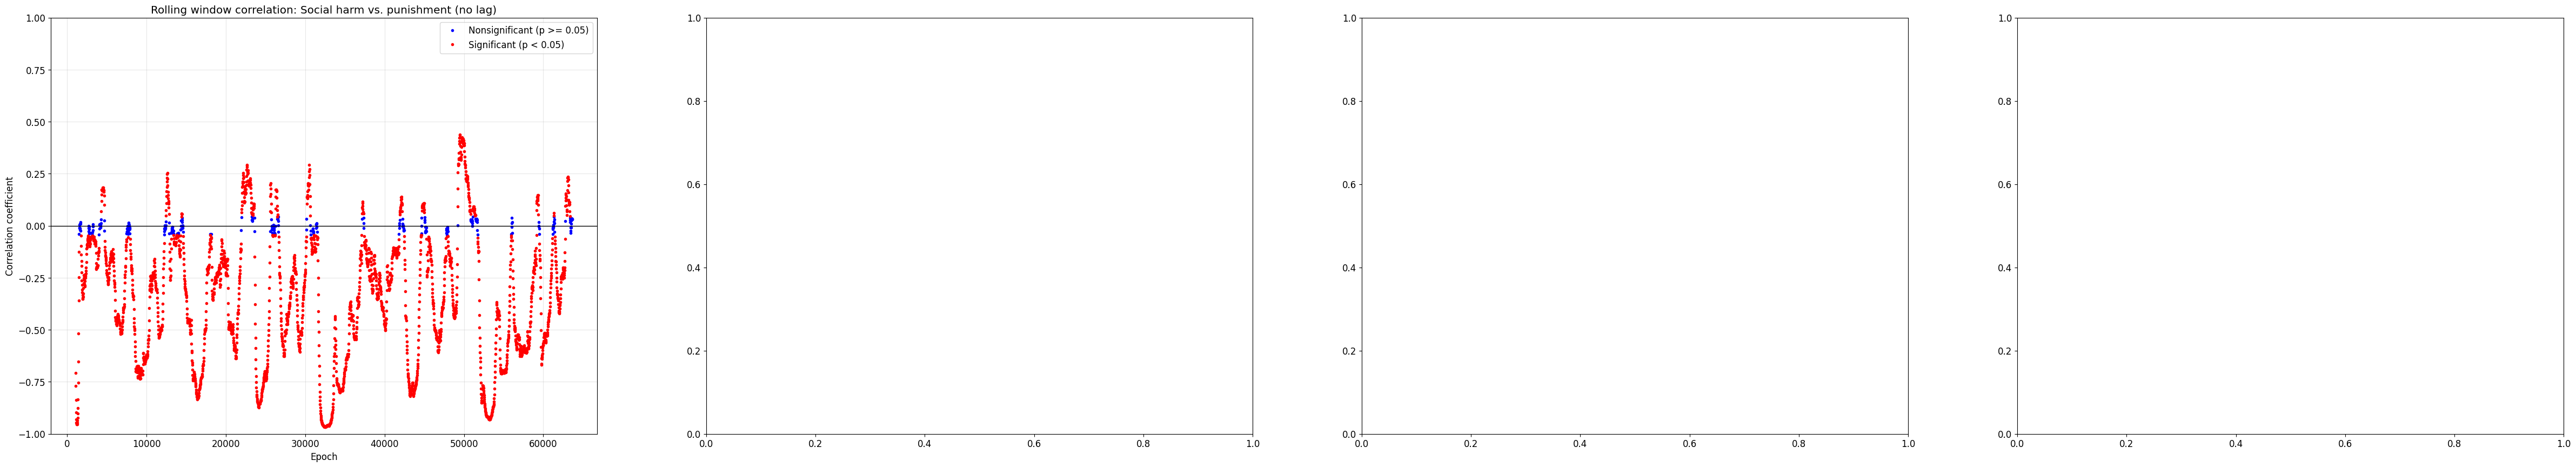

In [26]:
system_analysis(
    f, 
    include_controls=True,
    use_rate=True,
    factorized_actions=True,
    smooth_social_harm_window=80, 
    smooth_punishment_window=80,
    window_size=2000, 
    step_size=20, 
    lag=1, 
    start_timepoint=0, 
    xlim=None)

In [ ]:
import seaborn as sns

plot_type = all_results_df['title'].unique()
model_type = 'iqn'
use_cpc = 1

# setup figure
# fig, axes = plt.subplot(len(plot_type), 1, (len(plot_type)*5, 5))
for plot in plot_type:
    df_ = all_results_df[(all_results_df.use_cpc==use_cpc)&(all_results_df.title==plot)&(all_results_df.model_type==model_type)&(all_results_df.study_number==1)].reset_index(drop=True)
    # Use a colorblind-friendly palette such as 'colorblind' from seaborn
    palette = sns.color_palette("colorblind")
    sns.scatterplot(
        data = df_,
        x = 'window_centers_',
        y = 'correlations_',
        hue = 'use_cpc',
        palette = palette,
        s = 1
    )
    plt.title(plot)
    # plt.ylim(-1, 1)
    plt.axhline(0, linestyle='dotted', linewidth=1)
    ax = plt.gca()
    ax.legend(title="use cpc", markerscale=6)
    # plot a vertical line every 10000 timepoints within the current axes, after plotting
    for v in range(0, lims[idx]+1, 10000):
        plt.axvline(v, color='red', linestyle='--', linewidth=0.7, alpha=0.4)
    plt.ylabel('Coefficient')
    plt.show()

    

    

In [ ]:
fs

In [ ]:
lims = [60000 for _ in range(len(fs))]
all_results_df = []
for idx, f in enumerate(fs):
    # res_df = system_analysis(
    # f, 
    # include_controls=True,
    # use_rate=True,
    # factorized_actions=True,
    # smooth_social_harm_window=100, 
    # smooth_punishment_window=100,
    # window_size=1000, 
    # step_size=20, 
    # lag=1, 
    # start_timepoint=0, 
    # xlim=lims[idx])
    results_df, data_df = system_analysis_reactive_control(
    f=f,
    include_controls=True,
    use_rate=True,
    smooth_social_harm_window=5,
    smooth_punishment_window=5,
    window_size=1000,
    step_size=20,
    lag=1,
    start_timepoint=0,
    xlim=lims[idx],
    alpha=0.05,
    standardize=True,
    panel2_use_recent_avg_harm=True,
    panel2_recent_avg_window=100,
    make_plot=True,
    )
    
    # add info of the run
    use_cpc = '01_cpc' in f
    use_cpc_array = [use_cpc for _ in range(len(results_df))]
    model_type = 'ppo' if 'ppo' in f else 'iqn'
    model_type_array = [model_type for _ in range(len(results_df))]
    study_number = 1 if 'study1' in f else 2
    study_number_array = [study_number for _ in range(len(results_df))]

    results_df['use_cpc'] = use_cpc_array
    results_df['model_type'] = model_type_array
    results_df['study_number'] = study_number_array

    all_results_df.append(results_df)
    
all_results_df = pd.concat(all_results_df)

In [ ]:
lims = [100000, 160000, 100000, 160000]
for idx, f in enumerate(fs):
    system_analysis(
    f, 
    include_controls=True,
    use_rate=True,
    factorized_actions=True,
    smooth_social_harm_window=200, 
    smooth_punishment_window=200,
    window_size=3000, 
    step_size=20, 
    lag=2, 
    start_timepoint=0, 
    xlim=lims[idx])

In [ ]:
fs

In [ ]:
lims = [140000, 140000, 200000, 200000]
for idx, f in enumerate(fs):
    system_analysis(
    f, 
    include_controls=True,
    use_rate=True,
    factorized_actions=True,
    smooth_social_harm_window=200, 
    smooth_punishment_window=200,
    window_size=3000, 
    step_size=20, 
    lag=1, 
    start_timepoint=0, 
    xlim=lims[idx])

In [ ]:
fs

In [ ]:
system_analysis(
    f, 
    True,
    True,
    factorized_actions=True,
    smooth_social_harm_window=40, 
    smooth_punishment_window=40,
    window_size=2000, 
    step_size=20, 
    lag=1, 
    start_timepoint=0, 
    xlim=None)

In [ ]:
system_analysis(
    f, 
    True,
    True,
    factorized_actions=False,
    smooth_social_harm_window=40, 
    smooth_punishment_window=40,
    window_size=2000, 
    step_size=20, 
    lag=1, 
    start_timepoint=0, 
    xlim=None)

In [ ]:
system_analysis(
    f, 
    True,
    smooth_social_harm_window=1, 
    smooth_punishment_window=1,
    window_size=2000, 
    step_size=20, 
    lag=1, 
    start_timepoint=0, 
    xlim=None)

# correlation analysis

In [ ]:
# plot the overall punishment level trajectory of multiple conditions
fs = [
    'res/runs_Nov14/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251114-200030',
    # 'res/runs_Nov14/epsilon0.0_v2_det_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251114-200443',
    "res/runs_Nov14/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_punkn_sknown_20251114-200134",
]

fs = [
    "res/runs_Nov16/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251116-221557",
    "res/runs_Nov26/epsilon0.0_v2_prob_ext_charm_immed_silly_pobs_pothobs_noapp_norep_sp_r0.005_v4_m10_cvTrue_meTrue_2a_punkn_sknown_20251126-164048"
]

fs = [
    'res/runs_simple_params/epsilon0.0_v2_prob_ext_charm_immed_silly_pobs_pothobs_noapp_norep_sp_r0.005_v4_m10_cvTrue_meTrue_2a_pknown_sknown_20251201-143655',
    'res/runs_simple_params/epsilon0.0_v2_prob_ext_charm_immed_silly_pobs_pothobs_noapp_norep_sp_r0.005_v4_m10_cvTrue_meTrue_2a_punkn_sknown_20251201-143521'
]

fs = [
    'res/runs_debug1/corrected_orig_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_single_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251209-134348',
    'res/runs_debug2/p25_simple_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251209-163058'
]
conditions = [
    'pknown_sknown',
    'punkn_sknown',
]

wsize = 200
last_n_epochs = 20000
for ind, c in enumerate(conditions):
    # f = [f for f in fs if c in f][0]
    f = fs[ind]
    punishment_levels = pd.read_csv(f'{f}/Global_current_punishment_level_data.csv')['Value'].rolling(window=wsize).mean()[wsize:]
    plt.plot(punishment_levels.rolling(window=wsize).mean(), label=['punishment level visible', 'punishment level hidden'][ind], linestyle='-', linewidth=1, color=['tab:blue', 'tab:orange'][ind])
    plt.axhline(np.mean(punishment_levels[-last_n_epochs:]), label=['punishment level visible', 'punishment level hidden'][ind]+'_mean_last_200k_epochs', linestyle='--', linewidth=2, color=['tab:blue', 'tab:orange'][ind])
plt.legend()
plt.show()


In [ ]:
os.listdir('res/runs_debug1/')[2]

### collective harm at T ~ punishment at T

In [ ]:
## correlation bewteen social harm and punishment (correlation test + scatter plot)

import numpy as np
import pandas as pd

f = [
    'res/runs_Nov14/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251114-200030',
    'res/runs_Nov14/epsilon0.0_v2_det_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251114-200443',
    "res/runs_Nov14/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_punkn_sknown_20251114-200134"
][2]

# f = [
#       "res/runs_Nov16/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251116-221557",
#     "res/runs_Nov16/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_punkn_sknown_20251116-221629"
# ][1]

# f = [
#     "res/runs_Nov26/epsilon0.0_v2_prob_ext_charm_immed_silly_pobs_pothobs_noapp_norep_sp_r0.005_v4_m10_cvTrue_meTrue_2a_punkn_sknown_20251126-164048",
# ][0]

f = [
    'res/runs_simple_params/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251201-143529',
    'res/runs_simple_params/epsilon0.0_v2_prob_ext_charm_immed_silly_pobs_pothobs_noapp_norep_sp_r0.005_v4_m10_cvTrue_meTrue_2a_pknown_sknown_20251201-143655',
    'res/runs_simple_params/epsilon0.0_v2_prob_ext_charm_immed_silly_pobs_pothobs_noapp_norep_sp_r0.005_v4_m10_cvTrue_meTrue_2a_punkn_sknown_20251201-143521'
][0]

f = [
    "res/runs_debug3/simple_params_v5_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-152834",
    "res/runs_debug3/corrected_simple_params_gamma0.95_v4_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-225406",
    "res/runs_debug3/corrected_simple_params_v4_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-225255",
    "res/runs_debug3/simple_params_v4_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-224938",
    "res/runs_debug3/original_params_learningparamsv2_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251215-152637",
    "res/runs_debug3/simple_params_v3_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251215-145855",
    "res/runs_debug3/simple_params_v3_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251214-204027",
    "res/runs_debug3/simple_params_v2_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251213-202005",
    'res/runs_debug3/orig_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251210-231740',
    'res/runs_debug1/simple_params_p25_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251208-223847',
    'res/runs_debug1/orig_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_single_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251208-224326',
    'res/runs_debug1/simple_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_single_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251208-224132',
    'res/runs_debug1/corrected_orig_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_single_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251209-134348',
    'res/runs_debug2/with_norm_enforcer_simple_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_ne_th50_dr990_is-05_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251210-003702',
    'res/runs_debug2/p25_simple_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251209-163058',
    'res/runs_debug2/p25_simple_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251209-162807',
    'res/runs_debug2/simple_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251209-162411'
][3]

f ='res/runs_debug3/validate_reward_structure_complex_para_3agents_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_3a_pknown_sknown_20251226-012952'
# parameters
wsize = 1
# Load social harm and punishment data
social_harm = pd.read_csv(f'{f}/Mean_mean_social_harm_received_data.csv')
punishment_levels = pd.read_csv(f'{f}/Global_average_punishment_level_data.csv')
vote_increase_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_increase_data.csv')
vote_decrease_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_decrease_data.csv')


# remove missing values
social_harm = social_harm.rename(columns={'Value': 'social_harm'})
punishment_levels = punishment_levels.rename(columns={'Value': 'punishment_levels'})
vote_increase_freq = vote_increase_freq.rename(columns={'Value': 'vote_increase_freq'})
vote_decrease_freq = vote_decrease_freq.rename(columns={'Value': 'vote_decrease_freq'})
df_harm_and_punishment = pd.concat([social_harm, punishment_levels], axis=1)
df_harm_and_punishment = df_harm_and_punishment.dropna()
social_harm = df_harm_and_punishment['social_harm'].rolling(window=wsize).mean()
punishment_levels = df_harm_and_punishment['punishment_levels'].rolling(window=wsize).mean()
# vote_increase_freq = df_harm_and_punishment['vote_increase_freq']
# vote_decrease_freq = df_harm_and_punishment['vote_decrease_freq']

# Check if lengths match (they should - both are logged once per epoch)
# However, unequal lengths can occur due to:
# 1. TensorBoard event file corruption/incomplete writes
# 2. Early experiment termination (crash/interrupt)
# 3. Tag name changes between code versions
# 4. Partial logging failures
print(f"Social harm length: {len(social_harm)}")
print(f"Punishment levels length: {len(punishment_levels)}")
if len(social_harm) != len(punishment_levels):
    print(f"⚠️  WARNING: Length mismatch detected!")
    print(f"   Difference: {abs(len(social_harm) - len(punishment_levels))} epochs")
    print(f"   Possible causes: event file corruption, early termination, or logging issues")
    min_len = min(len(social_harm), len(punishment_levels))
    social_harm = social_harm[:min_len]
    punishment_levels = punishment_levels[:min_len]
    print(f"   Truncated both to length: {min_len} (using first {min_len} epochs)")
else:
    print("✓ Lengths match - both metrics logged once per epoch")

#parameters
lag = 1
start_timepoint = 300000

social_harm_transformed = zscore(social_harm[start_timepoint:])
punishment_levels_transformed = zscore(punishment_levels[start_timepoint:])
# Calculate correlation, p-value
correlation, p_value = pearsonr(social_harm_transformed, punishment_levels_transformed)
print(f"Correlation between social harm and punishment: {correlation:.4f}, p-value: {p_value:.4f}")

# scatter plot
plt.scatter(punishment_levels_transformed, social_harm_transformed, s=0.1)
plt.xlabel("Punishment Level")
plt.ylabel("Social Harm")
plt.title("Scatter plot of punishment vs social harm")
# trendline fitted for the relation
z = np.polyfit(punishment_levels_transformed, social_harm_transformed, 1)
p = np.poly1d(z)
plt.plot(punishment_levels_transformed, p(punishment_levels_transformed), "r--")

plt.text(1.5, 3, f"correlation: {correlation:.4f}, p-value: {p_value:.4f}", color='red')
plt.show()



In [ ]:
vote_increase_freq.info()

In [ ]:
h_smooth_zscore = zscore(h_smooth)
s_smooth_zscore = zscore(s_smooth)
plt.plot(np.arange(len(s_smooth_zscore)), s_smooth_zscore, label='punishment')
plt.plot(np.arange(len(h_smooth_zscore)), h_smooth_zscore, label='social harm')
plt.legend()
plt.show()

In [ ]:
# ============================================================
# COMPLETE ANALYSIS CELL (all data loaded at the beginning)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ------------------------------------------------------------
# 0) LOAD DATA (ONLY PLACE WHERE DATA ENTERS THE PIPELINE)
# ------------------------------------------------------------
# Replace these with your actual loading code if needed
# Example: np.load(), pd.read_csv(), etc.

# social_harm = np.asarray(social_harm, dtype=float)
# punishment_levels = np.asarray(punishment_levels, dtype=float)

assert social_harm.ndim == 1
assert punishment_levels.ndim == 1
assert len(social_harm) == len(punishment_levels)

T = len(punishment_levels)

# ------------------------------------------------------------
# 1) PARAMETERS
# ------------------------------------------------------------
eps = 0.2          # threshold for "zero punishment"
k = 200             # smoothing window for harm
W = 500             # event-trigger window (+/- W)

# ------------------------------------------------------------
# 2) HELPER FUNCTIONS
# ------------------------------------------------------------
def moving_avg(x, k):
    if k <= 1:
        return x.copy()
    return np.convolve(x, np.ones(k) / k, mode="same")

def event_triggered_average(x, events, window):
    segments = []
    for t in events:
        if t - window >= 0 and t + window < len(x):
            segments.append(x[t - window : t + window + 1])
    return np.mean(segments, axis=0) if len(segments) > 0 else None

def plot_event(tgrid, y, title, ylabel):
    plt.figure(figsize=(10, 4))
    if y is not None:
        plt.plot(tgrid, y)
    plt.axvline(0, linestyle="--")
    plt.xlabel("time relative to transition")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 3) CORE VARIABLES
# ------------------------------------------------------------
s = punishment_levels
h = social_harm
h_smooth = moving_avg(h, k)
s_smooth = moving_avg(s, k)

Z = (s <= eps).astype(int)     # zero-punishment regime indicator
ds = np.diff(s)               # punishment change

# ------------------------------------------------------------
# 4) DETECT REGIME TRANSITIONS
# ------------------------------------------------------------
zero_to_pos = np.where((s[:-1] <= eps) & (s[1:] > eps))[0] + 1
pos_to_zero = np.where((s[:-1] > eps) & (s[1:] <= eps))[0] + 1

print(f"Total timesteps: {T}")
print(f"Zero → positive transitions: {len(zero_to_pos)}")
print(f"Positive → zero transitions: {len(pos_to_zero)}")

# ------------------------------------------------------------
# 5) EVENT-TRIGGERED AVERAGES (STRONGEST EVIDENCE)
# ------------------------------------------------------------
tgrid = np.arange(-W, W + 1)

avg_h_up = event_triggered_average(h_smooth, zero_to_pos, W)
avg_s_up = event_triggered_average(s, zero_to_pos, W)

avg_h_dn = event_triggered_average(h_smooth, pos_to_zero, W)
avg_s_dn = event_triggered_average(s, pos_to_zero, W)

plot_event(tgrid, avg_h_up, "Harm before zero → positive punishment", "harm")
plot_event(tgrid, avg_s_up, "Punishment around zero → positive transition", "punishment")

plot_event(tgrid, avg_h_dn, "Harm before positive → zero punishment", "harm")
plot_event(tgrid, avg_s_dn, "Punishment around positive → zero transition", "punishment")

# ------------------------------------------------------------
# 6) DIRECTIONAL ASYMMETRY ANALYSIS
# ------------------------------------------------------------
increase = np.clip(ds, 0, None)
decrease = -np.clip(ds, None, 0)

quantiles = np.quantile(h_smooth[:-1], [0.25, 0.5, 0.75])
bins = [-np.inf, *quantiles, np.inf]
labels = ["Q1 low harm", "Q2", "Q3", "Q4 high harm"]

def binned_mean(x, y, bins):
    return [
        y[(x > lo) & (x <= hi)].mean()
        for lo, hi in zip(bins[:-1], bins[1:])
    ]

inc_means = binned_mean(h_smooth[:-1], increase, bins)
dec_means = binned_mean(h_smooth[:-1], decrease, bins)

plt.figure(figsize=(8, 4))
plt.plot(inc_means, marker="o", label="increase")
plt.plot(dec_means, marker="o", label="decrease")
plt.xticks(range(4), labels, rotation=20)
plt.ylabel("mean magnitude")
plt.title("Directional punishment adjustment vs harm")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7) REGIME-CONDITIONAL REGRESSION
# ------------------------------------------------------------
X = np.column_stack([
    h_smooth[:-1],
    Z[:-1],
    h_smooth[:-1] * Z[:-1],
])

X = sm.add_constant(X)
y = ds

model = sm.OLS(y, X).fit()
print(model.summary())

# ------------------------------------------------------------
# END OF CELL
# ------------------------------------------------------------


In [ ]:
lag = 10
pearsonr(social_harm_transformed[:-lag], punishment_levels_transformed[lag:])

In [ ]:
# rolling window: correlation between social harm and punishment (social harm at time T ~ p_T)
# rolling window: correlation between social harm and punishment (social harm at time T ~ p_T)
window_size = 2000
step_size = 40
lag = 1
start_timepoint = 0
smooth_social_harm_window = 1
smooth_punishment_window = 1

correlations = []
p_values = []
window_centers = []

sh_win = social_harm[start_timepoint:].rolling(window=smooth_social_harm_window).mean()
p_win = punishment_levels[start_timepoint:].rolling(window=smooth_punishment_window).mean()

for start in range(0, len(sh_win) - window_size + 1, step_size):
    end = start + window_size
    x_win = p_win[start:end]
    y_win = sh_win[start:end]
    # Only compute correlation if window has varied data
    if np.std(x_win) > 0 and np.std(y_win) > 0:
        corr, pval = pearsonr(x_win, y_win)
    else:
        corr, pval = np.nan, np.nan
    correlations.append(corr)
    p_values.append(pval)
    window_centers.append(start + window_size // 2)

correlations = np.array(correlations)
p_values = np.array(p_values)
window_centers = np.array(window_centers)

# Plotting, red for significant (p < 0.05), blue for nonsignificant
fig, ax = plt.subplots(figsize=(20, 10))

mask_sig = p_values < 0.05
mask_nonsig = ~mask_sig

ax.plot(window_centers[mask_nonsig], correlations[mask_nonsig], 'o', color='blue', label='Nonsignificant (p >= 0.05)', markersize=3)
ax.plot(window_centers[mask_sig], correlations[mask_sig], 'o', color='red', label='Significant (p < 0.05)', markersize=3)

ax.set_xlabel("Epoch")
ax.set_ylabel("Correlation coefficient")
ax.set_title("Rolling window correlation: Social harm vs. punishment (no lag)")
ax.legend()
ax.axhline(0, color='black', linewidth=1)
ax.set_ylim(-1, 1)
# ax.set_xlim(0, 80000)
# ax.set_xticks([])

plt.show()




### punishment at T ~ collective harm change at T + 1

In [ ]:
# correlation between first derivative of social harm and punishment (p at time T ~ delta harm_T)
lag = 1
start_timepoint = 300000
# Calculate first derivative of social harm
# social_harm_diff = np.diff(social_harm[start_timepoint:], n=lag)
# social_harm_diff = social_harm[start_timepoint+lag:].values - social_harm[start_timepoint:-lag].values
social_harm_diff = social_harm[start_timepoint+1:].values - social_harm[start_timepoint:-1].values
social_harm_diff = social_harm_diff[lag-1:]

# Calculate correlation between first derivative of social harm and punishment
correlation, p_value = spearmanr(social_harm_diff, punishment_levels[start_timepoint:][:-lag])
print(f"Correlation between first derivative of social harm and punishment: {correlation:.4f}, p-value: {p_value:.4f}")

# scatter plot
plt.scatter(punishment_levels[start_timepoint:][:-lag], social_harm_diff, s=0.1)
plt.xlabel("Punishment Level")
plt.ylabel("First derivative of social harm")
plt.title("Scatter plot of punishment vs first derivative of social harm")
# trendline fitted for the relation
z = np.polyfit(punishment_levels[start_timepoint:][:-lag], social_harm_diff, 1)
p = np.poly1d(z)
plt.plot(punishment_levels[start_timepoint:][:-lag], p(punishment_levels[start_timepoint:][:-lag]), "r--")
plt.text(0, 0.1, f"correlation: {correlation:.4f}, p-value: {p_value:.4f}", color='red')


In [ ]:
import statsmodels.api as sm
import numpy as np

# define Δx_{t+1}
dx = social_harm[1:].values - social_harm[:-1].values

# align x_t and s_t to match Δx_{t+1}
x_t = social_harm[:-1].values
s_t = punishment_levels[:-1].values

# Mode switch: 'regression' or 'partial_corr'
mode = 'partial_corr'  # Change to 'partial_corr' for partial correlation

if mode == 'regression':
    # regression: Δx ~ x + s
    X = np.column_stack([x_t, s_t])
    X = sm.add_constant(X)
    model = sm.OLS(dx, X).fit()
    print("Regression: Δx ~ x + s")
    print(model.summary())
    
    X = np.column_stack([s_t])
    X = sm.add_constant(X)
    model_ = sm.OLS(dx, X).fit()
    print("\nRegression: Δx ~ s")
    print(model_.summary())
    
elif mode == 'partial_corr':
    # Partial correlation: Δx with s, controlling for x
    df = pd.DataFrame({'dx': dx, 'x': x_t, 's': s_t})
    partial_corr = pg.partial_corr(data=df, x='dx', y='s', covar='x')
    
    print("Partial correlation: Δx with s, controlling for x")
    print(partial_corr)
    
    # Simple correlation: Δx with s (no control)
    simple_corr = pg.corr(x=dx, y=s_t)
    print("\nSimple correlation: Δx with s")
    print(simple_corr)


In [ ]:
# rolling window: regression Δx_{t+1} ~ s
# Mode switch: 'regression' or 'partial_corr'
mode = 'regression'  # Change to 'partial_corr' for partial correlation

window_size = 2000
step_size = 20
lag = 1
start_timepoint = 0

correlations = []
p_values = []
window_centers = []

smoothing_window_social_harm = 100
smoothing_window_punishment = 100

social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smoothing_window_social_harm).mean())
punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smoothing_window_punishment).mean())

# social_harm_diff = np.diff(social_harm[start_timepoint:], n=lag)
social_harm_diff = social_harm_arr[start_timepoint+lag:] - social_harm_arr[start_timepoint:-lag]
punishment_for_corr = punishment_arr[start_timepoint:][:-lag]
social_harm_for_corr = social_harm_arr[start_timepoint:][:-lag]

s_coefs = []
s_pvalues = []
window_centers = []

for start in range(0, len(social_harm_diff) - window_size + 1, step_size):
    end = start + window_size
    x_win = social_harm_for_corr[start:end]
    s_win = punishment_for_corr[start:end]
    y_win = social_harm_diff[start:end]

    # z-score all variables
    x_win_z = zscore(x_win)
    s_win_z = zscore(s_win)
    y_win_z = zscore(y_win)

    # Check for invalid values (inf or nan) that can occur when variance is zero
    if (np.any(~np.isfinite(y_win_z)) or 
        np.any(~np.isfinite(x_win_z)) or 
        np.any(~np.isfinite(s_win_z))):
        # Skip this window if any variable has invalid values
        s_coefs.append(np.nan)
        s_pvalues.append(np.nan)
        window_centers.append(start + window_size // 2)
        continue

    if mode == 'regression':
        # Prepare regression matrix: Δx_{t+1} ~ s
        X = np.column_stack([s_win_z])
        X = sm.add_constant(X)
        model = sm.OLS(y_win_z, X).fit()
        # Store coefficient and p-value of s (punishment)
        s_coefs.append(model.params[1])
        s_pvalues.append(model.pvalues[1])
    elif mode == 'partial_corr':
        # Partial correlation: Δx_{t+1} with s (no covariates, so it's simple correlation)
        df_win = pd.DataFrame({'y': y_win_z, 's': s_win_z})
        try:
            corr_result = pg.corr(x=df_win['y'], y=df_win['s'])
            s_coefs.append(corr_result['r'].values[0])
            s_pvalues.append(corr_result['p-val'].values[0])
        except:
            s_coefs.append(np.nan)
            s_pvalues.append(np.nan)
    
    window_centers.append(start + window_size // 2)

# Convert to arrays for plotting
s_coefs = np.array(s_coefs)
s_pvalues = np.array(s_pvalues)
window_centers = np.array(window_centers)

# Plot rolling coefficient for punishment (s) with significance
plt.figure(figsize=(12,6))
plt.axhline(0, color='k', linestyle='--', alpha=0.7)
# Significant: red; Not significant: blue
alpha = 0.05
is_significant = s_pvalues < alpha
plt.scatter(window_centers[is_significant], s_coefs[is_significant], color='red', label='Significant (p < 0.05)', s=1)
plt.scatter(window_centers[~is_significant], s_coefs[~is_significant], color='blue', label='Not significant', s=1)
plt.xlabel("Timepoint (window center)")
plt.ylabel("Regression coefficient (punishment)")
plt.title(f"Rolling window regression (Δ social harm at T+{lag} ~ punishment at T)")
plt.legend()
plt.ylim(-1, 1)
# plt.xticks([])
plt.grid(alpha=0.3)
plt.show()




In [ ]:
# rolling window: regression Δx_{t+1} ~ x_t + s
# Mode switch: 'regression' or 'partial_corr'
mode = 'regression'  # Change to 'partial_corr' for partial correlation

window_size = 2000
step_size = 20
lag = 1
start_timepoint = 0
smoothing_window_punishment = 200
smoothing_window_social_harm = 200

correlations = []
p_values = []
window_centers = []

social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smoothing_window_social_harm).mean())
punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smoothing_window_punishment).mean())

# social_harm_diff = np.diff(social_harm[start_timepoint:], n=lag)
social_harm_diff = social_harm_arr[start_timepoint+lag:] - social_harm_arr[start_timepoint:-lag]
punishment_for_corr = punishment_arr[start_timepoint:][:-lag]
social_harm_for_corr = social_harm_arr[start_timepoint:][:-lag]

s_coefs = []
s_pvalues = []
window_centers = []

for start in range(0, len(social_harm_diff) - window_size + 1, step_size):
    end = start + window_size
    x_win = social_harm_for_corr[start:end]
    s_win = punishment_for_corr[start:end]
    y_win = social_harm_diff[start:end]

    # z-score all variables
    x_win_z = zscore(x_win)
    s_win_z = zscore(s_win)
    y_win_z = zscore(y_win)

    # Check for invalid values (inf or nan) that can occur when variance is zero
    if (np.any(~np.isfinite(y_win_z)) or 
        np.any(~np.isfinite(x_win_z)) or 
        np.any(~np.isfinite(s_win_z))):
        # Skip this window if any variable has invalid values
        s_coefs.append(np.nan)
        s_pvalues.append(np.nan)
        window_centers.append(start + window_size // 2)
        continue

    if mode == 'regression':
        # Prepare regression matrix: Δx_{t+1} ~ x_t + s
        X = np.column_stack([x_win_z, s_win_z])
        X = sm.add_constant(X)
        model = sm.OLS(y_win_z, X).fit()
        # Store coefficient and p-value of s (punishment)
        s_coefs.append(model.params[2])
        s_pvalues.append(model.pvalues[2])
    elif mode == 'partial_corr':
        # Partial correlation: Δx_{t+1} with s, controlling for x_t
        df_win = pd.DataFrame({'y': y_win_z, 'x': x_win_z, 's': s_win_z})
        try:
            partial_corr_result = pg.partial_corr(data=df_win, x='y', y='s', covar='x')
            s_coefs.append(partial_corr_result['r'].values[0])
            s_pvalues.append(partial_corr_result['p-val'].values[0])
        except:
            s_coefs.append(np.nan)
            s_pvalues.append(np.nan)
    
    window_centers.append(start + window_size // 2)

# Convert to arrays for plotting
s_coefs = np.array(s_coefs)
s_pvalues = np.array(s_pvalues)
window_centers = np.array(window_centers)

# Plot rolling coefficient for punishment (s) with significance
plt.figure(figsize=(12,6))
plt.axhline(0, color='k', linestyle='--', alpha=0.7)
# Significant: red; Not significant: blue
alpha = 0.05
is_significant = s_pvalues < alpha
plt.scatter(window_centers[is_significant], s_coefs[is_significant], color='red', label='Significant (p < 0.05)', s=1)
plt.scatter(window_centers[~is_significant], s_coefs[~is_significant], color='blue', label='Not significant', s=1)
plt.xlabel("Timepoint (window center)")
plt.ylabel("Regression coefficient (punishment)")
plt.title(f"Rolling window regression (Δ social harm at T+{lag} ~ punishment at T + social harm at T)")
plt.legend()
plt.ylim(-1, 1)
# plt.xticks([])
plt.grid(alpha=0.3)
plt.show()




In [ ]:
df_model = pd.DataFrame({'coef':s_coefs, 'index':np.arange(len(s_coefs))})
model = sm.OLS.from_formula('coef ~ index', data=df_model).fit()
print(model.summary())

# rolling window: correlation between first derivative of social harm and punishment (p at time T ~ delta harm_T)

In [ ]:
# rolling window: correlation between first derivative of social harm and punishment (p at time T ~ delta harm_T)
window_size = 2000
step_size = 100
lag = 1
start_timepoint = 0

correlations = []
p_values = []
window_centers = []

# social_harm_diff = np.diff(social_harm[start_timepoint:], n=lag)
social_harm_diff = social_harm[start_timepoint+lag:].values - social_harm[start_timepoint:-lag].values
punishment_for_corr = punishment_levels[start_timepoint:][:-lag]

for start in range(0, len(social_harm_diff) - window_size + 1, step_size):
    end = start + window_size
    x_win = punishment_for_corr[start:end]
    y_win = social_harm_diff[start:end]
    # Only compute correlation if window has varied data
    if np.std(x_win) > 0 and np.std(y_win) > 0:
        corr, pval = spearmanr(x_win, y_win)
    else:
        corr, pval = np.nan, np.nan
    correlations.append(corr)
    p_values.append(pval)
    window_centers.append(start + window_size // 2)

# plt.figure(figsize=(12,6))
# plt.plot(window_centers, correlations, marker="o")
# plt.xlabel("Timepoint (window center)")
# plt.ylabel("Spearman Correlation")
# plt.title("Rolling window correlation (punishment ~ Δ social harm)")
# plt.grid()
# plt.show()
# Redo plot as scatter, red for significant, blue for not significant
plt.figure(figsize=(12,6))
correlations = np.array(correlations)
p_values = np.array(p_values)
window_centers = np.array(window_centers)

alpha = 0.05
is_significant = p_values < alpha

# Plot significant (red) and not significant (blue) points
plt.scatter(window_centers[is_significant], correlations[is_significant], s=1, color='red', label="Significant (p < 0.05)")
plt.scatter(window_centers[~is_significant], correlations[~is_significant], s=1, color='blue', label="Not significant (p ≥ 0.05)")

plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Timepoint (window center)")
plt.ylabel("Spearman Correlation")
plt.title(f"Rolling window correlation (punishment at T ~ Δ social harm at T+{lag})")
plt.legend()
# plt.xticks([])
plt.ylim(-1, 1)
plt.grid()
plt.show()



### collective harm at T ~ punishment delta at T + 1

In [ ]:
# correlation between social harm and the first derivative of punishment (social harm at time T ~ delta p_T)
lag = 1
start_timepoint = 10000
# Calculate first derivative of punishment
# punishment_diff = np.diff(punishment_levels[start_timepoint:], n=lag)
punishment_diff = punishment_levels[start_timepoint+lag:].values - punishment_levels[start_timepoint:-lag].values

# Calculate correlation between social harm and first derivative of punishment
correlation, p_value = spearmanr(social_harm[start_timepoint:][:-lag], punishment_diff)
print(f"Correlation between social harm and first derivative of punishment: {correlation:.4f}, p-value: {p_value:.4f}")

# scatter plot
plt.scatter(social_harm[start_timepoint:][:-lag], punishment_diff, s=0.1)
plt.xlabel("Social Harm")
plt.ylabel("First derivative of punishment")
plt.title("Scatter plot of social harm vs first derivative of punishment")
# trendline fitted for the relation
z = np.polyfit(social_harm[start_timepoint:][:-lag], punishment_diff, 1)
p = np.poly1d(z)
plt.plot(social_harm[start_timepoint:][:-lag], p(social_harm[start_timepoint:][:-lag]), "r--")
plt.text(0, 0.0, f"correlation: {correlation:.4f}, p-value: {p_value:.4f}", color='red')

In [ ]:
# rolling window: correlation between social harm and the first derivative of punishment (social harm at time T ~ delta p_T)

# rolling window: correlation between social harm and the first derivative of punishment (social harm at time T ~ delta p_T)
import numpy as np
from scipy.stats import spearmanr

window_size = 3000
step_size = 20
start_timepoint = 0
lag = 1

social_harm_arr = np.array(social_harm[start_timepoint:])
punishment_arr = np.array(punishment_levels[start_timepoint:])

social_harm_windows = []
correlations = []
p_values = []
window_centers = []
var_social_harm = []
var_punishment = []

for start in range(0, len(social_harm_arr) - window_size - lag + 1, step_size):
    stop = start + window_size
    # x: social harm (T), y: change in punishment (T+lag - T)
    x = social_harm_arr[start:stop-lag]
    # y = np.diff(punishment_arr[start:(stop+lag)], n=lag)
    y = punishment_arr[start+lag:stop] - punishment_arr[start:stop-lag]

    var_social_harm.append(np.var(x))
    var_punishment.append(np.var(y))

    # z-score x and y
    x = zscore(x)
    y = zscore(y)

    if np.all(np.isnan(x)) or np.all(np.isnan(y)):
        corr = np.nan
        p = np.nan
    else:
        corr, p = spearmanr(x, y)
    correlations.append(corr)
    p_values.append(p)
    window_centers.append(start + window_size//2)

correlations = np.array(correlations)
p_values = np.array(p_values)
window_centers = np.array(window_centers)

alpha = 0.05
is_significant = p_values < alpha

plt.figure(figsize=(10,6))
plt.scatter(window_centers[is_significant], correlations[is_significant], s=1, color='red', label="Significant (p < 0.05)")
plt.scatter(window_centers[~is_significant], correlations[~is_significant], s=1, color='blue', label="Not significant (p ≥ 0.05)")
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Timepoint (window center)")
plt.ylabel("Spearman Correlation")
plt.title(f"Rolling window correlation (social harm at T ~ Δ punishment at T+{lag})")
plt.legend()
plt.ylim(-1, 1)
plt.grid()
plt.show()
# plot variance of social harm and punishment in subplots (2, 1)
fig, axs = plt.subplots(2, 1, figsize=(10,6))
axs[0].plot(window_centers, var_social_harm, label='social harm')
axs[0].legend()
# axs[0].set_ylim(min=0)
axs[0].set_ylabel("Variance")
axs[0].set_title("Variance of social harm over time")
axs[1].plot(window_centers, var_punishment, label='punishment')
axs[1].legend()
axs[1].set_xlabel("Timepoint (window center)")
axs[1].set_ylabel("Variance")
plt.tight_layout()
plt.title("Variance of social harm and punishment over time")









In [ ]:
# Mode switch: 'regression' or 'partial_corr'
mode = 'regression'  # Change to 'partial_corr' for partial correlation

import statsmodels.api as sm

window_size = 1000
step_size = 10
lag = 1
smoothing_window_social_harm = 200
smoothing_window_punishment = 200

regression_coefs = []
regression_pvals = []
window_centers = []

y_label = f"Δ punishment at T+{lag}"
x_label = "social_harm at T"

social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smoothing_window_social_harm).mean())
punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smoothing_window_punishment).mean())

for start in range(0, len(social_harm_arr) - window_size - lag + 1, step_size):
    stop = start + window_size
    # The outcome: difference in punishment at T+lag vs T
    y = punishment_arr[start+lag:stop] - punishment_arr[start:stop-lag]
    # The regressors: social harm at T, punishment at T
    x1 = social_harm_arr[start:stop-lag]
    x2 = punishment_arr[start:stop-lag]  

    # z-score
    y = zscore(y)
    x1 = zscore(x1)
    x2 = zscore(x2)
   
    # Check for invalid values (inf or nan) or zero variance that can occur when variance is zero
    if (np.any(~np.isfinite(y)) or np.any(~np.isfinite(x1)) or np.any(~np.isfinite(x2)) or
        np.var(y) == 0 or np.var(x1) == 0 or np.var(x2) == 0):
        regression_coefs.append(np.nan)
        regression_pvals.append(np.nan)
    else:
        if mode == 'regression':
            X = np.column_stack([x1, x2])
            X = sm.add_constant(X)
            model = sm.OLS(y, X).fit()
            # coef for "social_harm at T" is at index 1 (const, x1, x2)
            regression_coefs.append(model.params[1])
            regression_pvals.append(model.pvalues[1])
        elif mode == 'partial_corr':
            # Partial correlation: y (Δ punishment) with x1 (social harm), controlling for x2 (punishment)
            df_win = pd.DataFrame({'y': y, 'x1': x1, 'x2': x2})
            try:
                partial_corr_result = pg.partial_corr(data=df_win, x='y', y='x1', covar='x2')
                regression_coefs.append(partial_corr_result['r'].values[0])
                regression_pvals.append(partial_corr_result['p-val'].values[0])
            except:
                regression_coefs.append(np.nan)
                regression_pvals.append(np.nan)
 

    window_centers.append(start + window_size//2)

regression_coefs = np.array(regression_coefs)
regression_pvals = np.array(regression_pvals)
window_centers = np.array(window_centers)

alpha = 0.05
is_significant = regression_pvals < alpha

plt.figure(figsize=(10,6))
plt.scatter(window_centers[is_significant], regression_coefs[is_significant], s=2, color='red', label="Significant (p < 0.05)")
plt.scatter(window_centers[~is_significant], regression_coefs[~is_significant], s=2, color='blue', label="Not significant (p ≥ 0.05)")
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Timepoint (window center)")
if mode == 'regression':
    plt.ylabel("Regression coefficient for social harm at T")
    plt.title(f"Rolling window regression: Δ punishment at T+{lag} ~ social harm at T + punishment at T")
elif mode == 'partial_corr':
    plt.ylabel("Partial correlation coefficient (social harm at T | punishment at T)")
    plt.title(f"Rolling window partial correlation: Δ punishment at T+{lag} with social harm at T (controlling for punishment at T)")
plt.legend()
# plt.ylim(np.nanmin(regression_coefs)-.1, np.nanmax(regression_coefs)+.1)
plt.grid()
plt.show()

In [ ]:
import statsmodels.api as sm

window_size = 2000
step_size = 20
lag = 50

regression_coefs = []
regression_pvals = []
window_centers = []

y_label = f"Δ punishment at T+{lag}"
x_label = "social_harm at T"

for start in range(0, len(social_harm_arr) - window_size - lag + 1, step_size):
    stop = start + window_size
    # The outcome: difference in punishment at T+lag vs T
    y = punishment_arr[start+lag:stop] - punishment_arr[start:stop-lag]
    # The regressors: social harm at T, punishment at T
    x1 = social_harm_arr[start:stop-lag]
    x2 = punishment_arr[start:stop-lag]  

    # z-score
    y = zscore(y)
    x1 = zscore(x1)
    x2 = zscore(x2)
   
    # Check for invalid values (inf or nan) or zero variance that can occur when variance is zero
    if (np.any(~np.isfinite(y)) or np.any(~np.isfinite(x1)) or np.any(~np.isfinite(x2)) or
        np.var(y) == 0 or np.var(x1) == 0 or np.var(x2) == 0):
        regression_coefs.append(np.nan)
        regression_pvals.append(np.nan)
    else:
        X = np.column_stack([x1, x2])
        X = sm.add_constant(X)
        model = sm.OLS(y, X).fit()
        # coef for "social_harm at T" is at index 1 (const, x1, x2)
        regression_coefs.append(model.params[1])
        regression_pvals.append(model.pvalues[1])
 

    window_centers.append(start + window_size//2)

regression_coefs = np.array(regression_coefs)
regression_pvals = np.array(regression_pvals)
window_centers = np.array(window_centers)

alpha = 0.05
is_significant = regression_pvals < alpha

plt.figure(figsize=(10,6))
plt.scatter(window_centers[is_significant], regression_coefs[is_significant], s=2, color='red', label="Significant (p < 0.05)")
plt.scatter(window_centers[~is_significant], regression_coefs[~is_significant], s=2, color='blue', label="Not significant (p ≥ 0.05)")
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Timepoint (window center)")
plt.ylabel("Regression coefficient for social harm at T")
plt.title(f"Rolling window regression: Δ punishment at T+{lag} ~ social harm at T + punishment at T")
plt.legend()
plt.ylim(np.nanmin(regression_coefs)-.1, np.nanmax(regression_coefs)+.1)
plt.grid()
plt.show()


### delta collective harm ~ delta punishment level

In [ ]:
# correlation between first derivative of social harm at T + 1 and the first derivative of punishment at T
lag = 1
start_timepoint = 10000


# social_harm_diff = social_harm[start_timepoint+lag:].values - social_harm[start_timepoint:-lag].values
# social_harm_diff = social_harm_diff[lag:]
# punishment_diff = punishment_levels[start_timepoint+lag:].values - punishment_levels[start_timepoint:-lag].values
# punishment_diff = punishment_diff[:-lag]
social_harm_diff = social_harm[start_timepoint+1:].values - social_harm[start_timepoint:-1].values
print(len(social_harm_diff))
social_harm_diff = social_harm_diff[lag:]
punishment_diff = punishment_levels[start_timepoint+1:].values - punishment_levels[start_timepoint:-1].values
print(len(punishment_diff))
len_ = len(punishment_diff)
punishment_diff = punishment_diff[:len_-lag]
print(len(punishment_diff))
correlation, p_value = pearsonr(social_harm_diff, punishment_diff)
print(f"Correlation between first derivative of social harm and first derivative of punishment: {correlation:.4f}, p-value: {p_value:.4f}")

# scatter plot
plt.scatter(social_harm_diff, punishment_diff, s=0.1)
plt.xlabel("First derivative of social harm")
plt.ylabel("First derivative of punishment")
plt.title("Scatter plot of first derivative of social harm vs first derivative of punishment")
# trendline fitted for the relation
z = np.polyfit(social_harm_diff, punishment_diff, 1)
p = np.poly1d(z)
plt.plot(social_harm_diff, p(social_harm_diff), "r--")
plt.text(-22, 0.75, f"correlation: {correlation:.4f}, p-value: {p_value:.4f}", color='red')
# plt.tight_layout()



In [ ]:
# define Δx_{t+1}
start_timepoint = 250000
social_harm_ = social_harm[start_timepoint:]
punishment_ = punishment_levels[start_timepoint:]
dx = social_harm_[1:].values - social_harm_[:-1].values
dx = dx[1:]

# align x_t and s_t to match Δx_{t+1}
x_t = social_harm_[1:-1].values
s_t = punishment_[:-1].values
ds = s_t[1:] - s_t[:-1]


# regression: Δx+1 ~ x+1 + Δs
X = np.column_stack([x_t, ds])
X = sm.add_constant(X)

model = sm.OLS(dx, X).fit()
print(model.summary())

In [ ]:
# rolling window: regression Δx_{t+1} ~ x_t + Δs_t

import statsmodels.api as sm

from scipy.stats import zscore

window_size = 2500
step_size = 20
start_timepoint = 0
smoothing_window_social_harm = 100
smoothing_window_punishment = 100
# Prepare the series
social_harm_arr = np.array(social_harm[start_timepoint:].rolling(window=smoothing_window_social_harm).mean())
punishment_arr = np.array(punishment_levels[start_timepoint:].rolling(window=smoothing_window_punishment).mean())

dx = social_harm_arr[1:] - social_harm_arr[:-1]
dx = dx[1:]
xvals = social_harm_arr[1:-1]
svals = punishment_arr[:-1]
ds = svals[1:] - svals[:-1]


dx = dx[:]
x_t = xvals[:]
ds_t = ds[:]

n_points = len(x_t)
rolling_coefs = []
rolling_pvalues = []
window_centers = []

for start in range(0, n_points - window_size + 1, step_size):
    end = start + window_size

    # Prepare variables for regression in the window
    y_win = dx[start:end]
    x_win = x_t[start:end]
    ds_win = ds_t[start:end]
    
    # z-score all variables
    y_win_z = zscore(y_win)
    x_win_z = zscore(x_win)
    ds_win_z = zscore(ds_win)

    # Check for invalid values (inf or nan) that can occur when variance is zero
    if (np.any(~np.isfinite(y_win_z)) or 
        np.any(~np.isfinite(x_win_z)) or 
        np.any(~np.isfinite(ds_win_z))):
        # Skip this window if any variable has invalid values
        rolling_coefs.append(np.nan)
        rolling_pvalues.append(np.nan)
        window_centers.append(start + window_size // 2)
        continue

    # Design matrix: x_t, Δs_t (with constant intercept)
    X = np.column_stack([x_win_z, ds_win_z])
    X = sm.add_constant(X)
    model = sm.OLS(y_win_z, X).fit()
    
    rolling_coefs.append(model.params[2])        # coefficients [x_t, Δs_t]
    rolling_pvalues.append(model.pvalues[2])     # p-values [x_t, Δs_t]
    window_centers.append(start + window_size // 2)

rolling_coefs = np.array(rolling_coefs)     # shape: [windows, 2]
rolling_pvalues = np.array(rolling_pvalues) # shape: [windows, 2]
window_centers = np.array(window_centers)

# Plot, marking statistically significant coefficients as in prior code
alpha = 0.05
# Filter out nan values for plotting
valid_mask = np.isfinite(rolling_coefs) & np.isfinite(rolling_pvalues)
is_significant_ds = (rolling_pvalues < alpha) & valid_mask

plt.figure(figsize=(12,6))
plt.scatter(window_centers[is_significant_ds], rolling_coefs[is_significant_ds], s=2, color='red', label="Δs_t significant (p<0.05)")
plt.scatter(window_centers[valid_mask & ~is_significant_ds], rolling_coefs[valid_mask & ~is_significant_ds], s=2, color='blue', label="Δs_t not significant")
plt.axhline(0, color='black', linewidth=1)
plt.ylim(-1, 1)
plt.xlabel("Timepoint (window center)")
plt.ylabel("Beta coefficient")
plt.title(r"Rolling window regression: $\Delta x_t+1 \sim x_t + \Delta s_t$")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# instead of looking the collective level metrics, we look at the individual voting behaviors and the harm they received


In [ ]:
# calculate the correlation between the encounters of entity e at time t and the change of punishment at time t+1

import numpy as np
import pandas as pd

# Load entity E encounter data and punishment level data
# Assume the encounter data is in a CSV with a 'Value' column, one value per epoch
entity_e_encounters = pd.read_csv(
    'res/runs_Nov14/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251114-200030/Mean_mean_e_encounters_data.csv'
)['Value']

punishment_levels = pd.read_csv(
    'res/runs_Nov14/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251114-200030/Global_average_punishment_level_data.csv'
)['Value']

# Calculate the change in punishment at t+1
punishment_diff = punishment_levels.values[1:] - punishment_levels.values[:-1]
punishment_diff = punishment_diff[:1000]

# Truncate to the same length
min_len = min(len(entity_e_encounters)-1, len(punishment_diff))
entity_e_encounters = entity_e_encounters[:min_len]
punishment_diff = punishment_diff[:min_len]

# Calculate correlation
correlation, p_value = pearsonr(entity_e_encounters, punishment_diff)
print(f"Correlation between mean entity E encounters at time t and change of punishment at time t+1: {correlation:.4f}, p-value: {p_value:.4f}")


In [ ]:
# calculate the correlation between the reward at time t and the change of punishment at time t+1
import numpy as np
import pandas as pd

# Load reward and punishment data
reward_series = pd.read_csv(
    'res/runs_Nov14/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251114-200030/Mean_mean_individual_score_data.csv'
)['Value']

punishment_levels = pd.read_csv(
    'res/runs_Nov14/epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251114-200030/Global_average_punishment_level_data.csv'
)['Value']


# Align lengths after rolling
min_len = min(len(reward_series)-1, len(punishment_levels)-1)
reward_series = reward_series[:min_len]
punishment_levels = punishment_levels[:min_len]

# Calculate the change in punishment at t+1
punishment_diff = punishment_levels.values[1:] - punishment_levels.values[:-1]
reward_series_aligned = reward_series.values[:-1]  # reward at time t

# Truncate to same length
min_len2 = min(len(reward_series_aligned), len(punishment_diff))
reward_series_aligned = reward_series_aligned[:min_len2]
punishment_diff = punishment_diff[:min_len2]

# Calculate correlation
correlation = np.corrcoef(reward_series_aligned, punishment_diff)[0, 1]
print(f"Correlation between reward at time t and change of punishment at time t+1: {correlation:.4f}")

window_size = 50
# For plotting, align the x-axis to the center of each window
corrs, pvals, _ = rolling_window_correlation(reward_series_aligned, punishment_diff, window_size)

x = np.arange(len(corrs)) + window_size // 2

plt.figure(figsize=(12,6))
# Color by p-value: red if p < 0.05, blue otherwise
colors = np.where(pvals < 0.05, 'red', 'blue')
plt.scatter(x, corrs, c=colors, alpha=0.6, label='Rolling correlation')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel(f"Time (center of {window_size}-step window)")
plt.ylabel("Correlation between reward and Δpunishment")
plt.title(f"Rolling window correlation (window={window_size})\nRed: p < 0.05, Blue: p ≥ 0.05")
plt.show()


In [ ]:
# calculate the correlation between the punishment at time t and the change of reward at time t+1

import numpy as np
import pandas as pd

# Load punishment levels and rewards
punishment_levels = pd.read_csv('res/runs_p48_a2_deterministic/collective_harm_state_punishment_respawn_0.005_vision_4_map_10_composite_views_False_multi_env_True__2agents_20250923-143956/Global_average_punishment_level_data.csv')['Value']
# punishment_levels = punishment_levels.rolling(window=2000).mean()
# punishment_levels = punishment_levels.dropna()
# For reward, we need a time series matching the epochs of punishment_levels
# we will use the same reward time series as above
reward_series = pd.read_csv('res/runs_p48_a2_deterministic/collective_harm_state_punishment_respawn_0.005_vision_4_map_10_composite_views_False_multi_env_True__2agents_20250923-143956/Mean_mean_individual_score_data.csv')['Value']
# reward_series = reward_series.rolling(window=2000).mean()
# reward_series = reward_series.dropna()


# Calculate the change in reward at t+1

reward_diff = reward_series.values[2:] - reward_series.values[:-2]

# Truncate to the same length
min_len = min(len(punishment_levels), len(reward_diff))
punishment_levels = punishment_levels[:min_len]
reward_diff = reward_diff[:min_len]

# Calculate correlation
correlation = np.corrcoef(punishment_levels, reward_diff)[0, 1]
print(f"Correlation between punishment at time t and change in reward at t+1: {correlation:.4f}")


window_size = 50
# For plotting, align the x-axis to the center of each window
corrs, pvals, prop = rolling_window_correlation(punishment_levels, reward_diff, window_size)

x = np.arange(len(corrs)) + window_size // 2

plt.figure(figsize=(12,6))
# Color by p-value: red if p < 0.05, blue otherwise
colors = np.where(pvals < 0.05, 'red', 'blue')
# red if -1, blue if 1, otherwise gray
# colors = np.where(prop == -1, 'red', np.where(prop == 1, 'blue', 'gray'))
plt.scatter(x, corrs, c=colors, alpha=0.6, label='Rolling correlation')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel(f"Time (center of {window_size}-step window)")
plt.ylabel("Correlation between punishment and Δreward")
plt.title(f"Rolling window correlation (window={window_size})\nRed: p < 0.05, Blue: p ≥ 0.05")
plt.show()



In [ ]:
system_analysis(f, 100, 100, 2000, 25, 1, 10000)

In [ ]:
system_analysis(f, 100, 100, 2000, 25, 1, 10000)

## plot state punishment, social harm received, and actions

In [ ]:
fs.remove(fs[2])

In [ ]:
fs

In [54]:
fs

['res/runs_bandit_study2_v2/np_00_cpc_iqn_lstm_cpc_bandit_study2_k3_seed1_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260522-201100',
 'res/runs_bandit_study2_v2/np_00_cpc_iqn_lstm_cpc_bandit_study2_k3_seed2_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260522-201100',
 'res/runs_bandit_study2_v2/np_00_cpc_iqn_lstm_cpc_bandit_study2_k3_seed3_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260526-125254',
 'res/runs_bandit_study2_v2/np_00_cpc_iqn_lstm_cpc_bandit_study2_k3_seed4_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meFalse_10a_punkn_sknown_20260526-125254',
 'res/runs_bandit_study2_v2/np_00_cpc_iqn_lstm_cpc_bandit_study2_k5_seed4_v2_prob_ext_nocharm_immed_silly_pnoobs_pothnoobs_n

In [30]:


fs_ = [fs[1], fs[3]]
# fs = [
#     'res/runs_debug7/00_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-122249',
#     'res/runs_debug7/01_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-122210'
# ]
# f = 'res/runs_debug3/validate_ppo_10agents_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260104-200742'
# f = 'res/runs_debug4/replacement_orig_iqn_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min5000_start5000_ten5000_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260117-215755'# f = 'res/runs_debug4/iqn_corrected_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260114-164739'
# f = 'res/runs_debug4/replacement_factorized_iqn_fast_orig_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min5000_start5000_ten5000_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260120-210234'
# f = 'res/runs_debug4/replacement_slow_orig_iqn_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260120-210152'
# f = 'res/runs_debug4/spawn_issue_fixed_replacement_slow_iqn_orign_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260121-143501'
# # f = 'res/runs_debug4/spawn_issue_fixed_replacement_factorized_iqn_fast_orig_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min5000_start5000_ten5000_none_iqn_preset_sp_r0.000_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260121-143728'
# f = 'res/runs_debug4/v2_spawn_issue_fixed_replacement_slow_iqn_orign_param_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.010_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260122-152635'
def load_step_series(filepath, ref_steps, fill_value=0.0):
    """Load a TensorBoard CSV aligned to ref_steps by the Step column.

    Missing steps (epochs where the metric was not logged, e.g. zero-count actions
    in older runs) are filled with fill_value instead of being interpolated, which
    prevents artificial inflation when summing across action types.
    """
    df = pd.read_csv(filepath)
    s = df.set_index('Step')['Value']
    return s.reindex(ref_steps, fill_value=fill_value).reset_index(drop=True)

state_punishment_level_lst = []
social_harm_received_lst = []
reward_series_lst = []
vote_increase_lst = []
vote_decrease_lst = []
action_1_lst = []
action_4_lst = []
action_7_lst = []
action_10_lst = []
action_13_lst = []
action_2_lst = []
action_5_lst = []
action_8_lst = []
action_11_lst = []
action_14_lst = []
resource_A_lst = []
resource_B_lst = []
resource_C_lst = []
resource_D_lst = []
resource_E_lst = []
resource_total_lst = []

for f in fs_:
    ref_df = pd.read_csv(f'{f}/Global_average_punishment_level_data.csv')
    ref_steps = ref_df['Step'].values
    state_punishment_level = ref_df['Value'].reset_index(drop=True)

    social_harm_received = load_step_series(f'{f}/Mean_mean_social_harm_received_data.csv', ref_steps)
    reward_series = load_step_series(f'{f}/Mean_mean_individual_score_data.csv', ref_steps)

    state_punishment_level_lst.append(state_punishment_level)
    social_harm_received_lst.append(social_harm_received)
    reward_series_lst.append(reward_series)

    factorized_actions = True  # always factorized

    vote_increase = load_step_series(f'{f}/Global_vote_increase_data.csv', ref_steps)
    vote_decrease = load_step_series(f'{f}/Global_vote_decrease_data.csv', ref_steps)
    vote_increase_lst.append(vote_increase)
    vote_decrease_lst.append(vote_decrease)

    # if not factorized_actions:
    #     vote_increase = load_step_series(f'{f}/Mean_mean_action_freq_vote_increase_data.csv', ref_steps)
    #     vote_decrease = load_step_series(f'{f}/Mean_mean_action_freq_vote_decrease_data.csv', ref_steps)
    #     vote_increase_lst.append(vote_increase)
    #     vote_decrease_lst.append(vote_decrease)
    # else:
    #     vote_inc_ids = [4] #[1, 4, 7, 10, 13]
    #     vote_dec_ids = [5] #[2, 5, 8, 11, 14]
    #     action_lsts = {
    #         1: action_1_lst, 4: action_4_lst, 7: action_7_lst, 10: action_10_lst, 13: action_13_lst,
    #         2: action_2_lst, 5: action_5_lst, 8: action_8_lst, 11: action_11_lst, 14: action_14_lst,
    #     }
    #     loaded = {}
    #     for a in vote_inc_ids + vote_dec_ids:
    #         s = load_step_series(f'{f}/Mean_mean_action_freq_action_{a}_data.csv', ref_steps)
    #         loaded[a] = s
    #         action_lsts[a].append(s)

    #     vote_increase = sum(loaded[a] for a in vote_inc_ids)
    #     vote_decrease = sum(loaded[a] for a in vote_dec_ids)
    #     vote_increase_lst.append(vote_increase)
    #     vote_decrease_lst.append(vote_decrease)

    resource_names = ['a', 'b', 'c', 'd', 'e']
    resources = {
        name: load_step_series(f'{f}/Mean_mean_{name}_encounters_data.csv', ref_steps)
        for name in resource_names
    }
    resource_A, resource_B, resource_C, resource_D, resource_E = (
        resources['a'], resources['b'], resources['c'], resources['d'], resources['e']
    )
    resource_total = sum(resources.values())

    resource_A_lst.append(resource_A)
    resource_B_lst.append(resource_B)
    resource_C_lst.append(resource_C)
    resource_D_lst.append(resource_D)
    resource_E_lst.append(resource_E)
    resource_total_lst.append(resource_total)

# action frequency
# action_freq_down_data = pd.read_csv(f'{f}/Mean_mean_action_freq_down_data.csv')['Value']
# action_freq_up_data = pd.read_csv(f'{f}/Mean_mean_action_freq_up_data.csv')['Value']
# action_freq_left_data = pd.read_csv(f'{f}/Mean_mean_action_freq_left_data.csv')['Value']
# action_freq_right_data = pd.read_csv(f'{f}/Mean_mean_action_freq_right_data.csv')['Value']
# action_freq_vote_increase_data = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_increase_data.csv')['Value']
# action_freq_vote_decrease_data = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_decrease_data.csv')['Value']
# action_freq_noop_data = pd.read_csv(f'{f}/Mean_mean_action_freq_noop_data.csv')['Value']
# action_freq_total_data = action_freq_down_data + action_freq_up_data + action_freq_left_data + action_freq_right_data + action_freq_vote_increase_data + action_freq_vote_decrease_data 


97.24525001907348
97.31644997024536
2.7547499991059303
2.6835499990582465
0.0
0.0
0.0
0.0
0.0
0.0


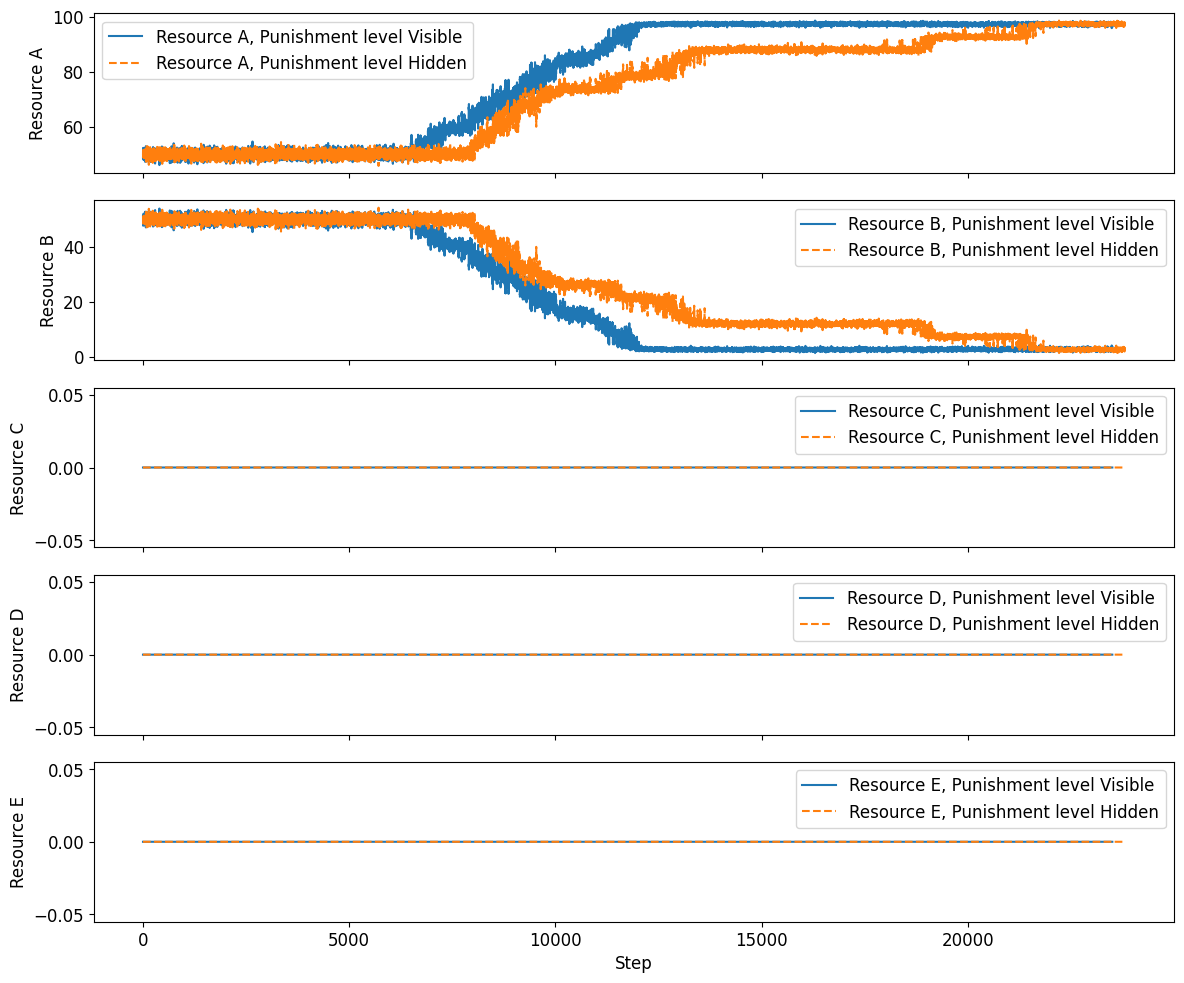

In [32]:
# plot the metrics for each resource separately

wsize = 2
ylim = 12
end = None
condition_tags = [['Punishment level Visible', 'Punishment level Hidden'], ['w/o CPC', 'w/ CPC']][0]
resource_labels = ['Resource A', 'Resource B', 'Resource C', 'Resource D', 'Resource E']
resource_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

fig, axs = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

for i, (resource_label, color) in enumerate(zip(resource_labels, resource_colors)):
    for count, f in enumerate(fs_):
        # Choose which resource list to use based on i
        resource_data = [
            resource_A_lst,
            resource_B_lst,
            resource_C_lst,
            resource_D_lst,
            resource_E_lst,
        ][i][count]
        axs[i].plot(
            resource_data[:end].rolling(window=wsize).mean(),
            label=f"{resource_label}, {condition_tags[count]}",
            color=color if len(fs) == 1 else None,  # use color only if single line per ax
            linestyle="-" if count == 0 else "--"
        )
        print(resource_data[-2000:end].mean())
        end_ = end if end is not None else len(resource_data)
        # for j in range(min(end_, len(resource_data))//10000 + 1):
        #     if j > 0:
        #         axs[i].axvline(9999+10000*(j-1), color='red', linestyle='--', linewidth=1)
    axs[i].set_ylabel(resource_label)
    # axs[i].set_ylim(0, ylim)
    axs[i].legend()

plt.xlabel('Step')
plt.tight_layout()
# Remove plt.legend() here, since legends for each ax
plt.show()


In [35]:
from scipy.signal import detrend

signal = resource_A_lst[0]
# signal = state_punishment_level_lst[0]
signal_d = detrend(signal)

plot_acf(signal_d, lags=40000)
plt.show()

NameError: name 'plot_acf' is not defined

Vote increase 168.0833
Vote increase 204.7771
Vote decrease 559.7575
Vote decrease 491.5134
-3221.73725
-3053.48485


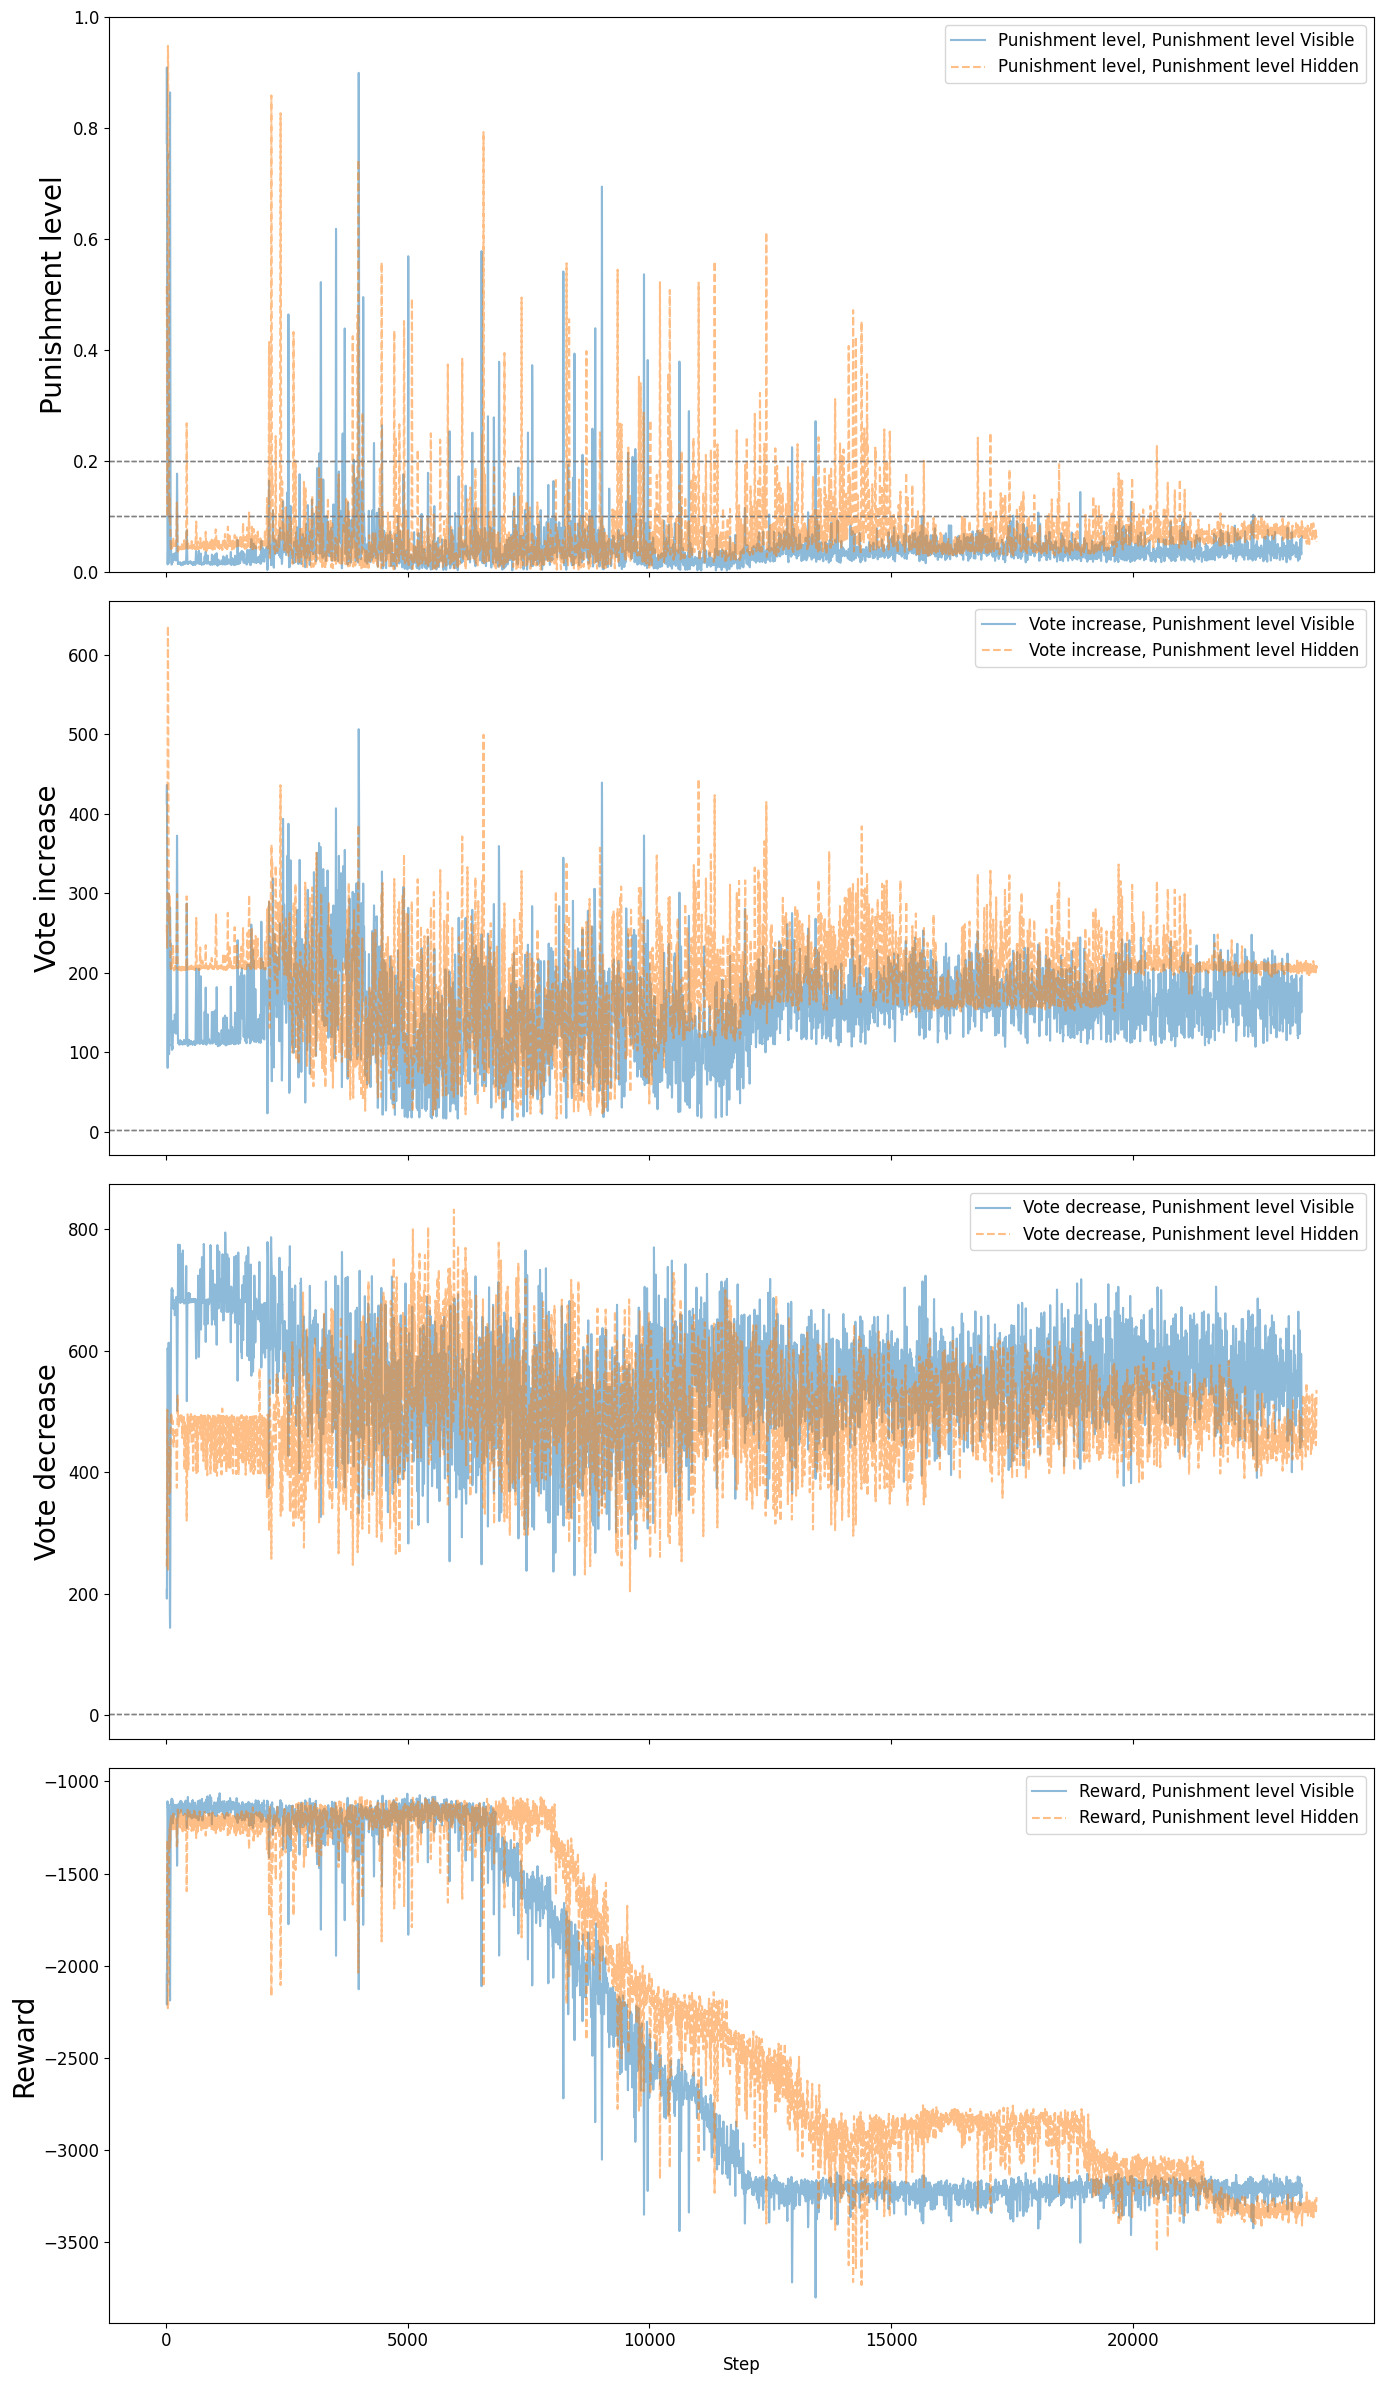

In [33]:
wsize = 10
ylim = 10
end = None
# condition_tags = ['No CPC', 'CPC']  # exactly as in the resources plot

metric_labels = [
    ('Punishment level', 'tab:blue'),
    # ('Collective Harm', 'tab:orange'),
    ('Vote increase', 'tab:green'),
    ('Vote decrease', 'tab:red'),
    ('Reward', 'tab:purple'),
]
metric_data_lsts = [
    state_punishment_level_lst,
    # social_harm_received_lst,
    vote_increase_lst,
    vote_decrease_lst,
    reward_series_lst,
]

fig, axs = plt.subplots(len(metric_labels), 1, figsize=(14, 24), sharex=True)

for i, ((label, color), metric_lst) in enumerate(zip(metric_labels, metric_data_lsts)):
    for count, f in enumerate(fs_):
        
        # check number of nans
        # print(np.sum(np.isnan(metric_lst[count])))
        try:
            series = metric_lst[count]
        except (IndexError, NameError):
            continue
        axs[i].plot(
            series[:end].rolling(window=wsize).mean(),
            label=f"{label}, {condition_tags[count]}",
            color=color if len(fs_) == 1 else None,
            linestyle="-" if count == 0 else "--",
            alpha=0.5
        )
        axs[i].set_ylabel(label, fontsize=20)
        if end is None:
            end_ = len(state_punishment_level_lst[0])
        else:
            end_ = end
        # for j in range(min(end_, len(state_punishment_level_lst[0]))//10000 + 1):
        #     if j > 0:
        #         axs[i].axvline(9999+10000*(j-1), color='red', linestyle='--', linewidth=1)
        axs[i].set_ylabel(label)
        if label == 'Punishment level':
            punishment_data = series
            axs[i].set_ylim(0, 1)
            # axs[i].set_xlim(80000, 81000)
            axs[i].axhline(0.1, color='gray', linestyle='--', linewidth=1)
            axs[i].axhline(0.2, color='gray', linestyle='--', linewidth=1)
        if label in ['Vote increase', 'Vote decrease']:
            axs[i].axhline(2, color='gray', linestyle='--', linewidth=1)
            print(label, series[-10000:].mean())
        if label == 'Reward':
            print(series[-10000:].mean())
        axs[i].legend()

axs[-1].set_xlabel('Step')
plt.tight_layout()
plt.show()


# print('social harm received', social_harm_received[30000:40000].mean())
# print('state punishment level', state_punishment_level[30000:40000].mean())

In [45]:
resource_A_lst[0].values

array([20.        , 20.5       , 21.29999924, ...,  2.0999999 ,
        1.39999998,  2.0999999 ])

                          band  period_min  period_max  band_power  \
0   high_freq_fast_corrections           1        1000    0.990792   
1         mid_freq_adjustments        1000        5000    0.004519   
2       low_freq_regime_cycles        5000       30000    0.000608   
3   high_freq_fast_corrections           1        1000    1.018580   
4         mid_freq_adjustments        1000        5000    0.005118   
5       low_freq_regime_cycles        5000       30000    0.001675   
6   high_freq_fast_corrections           1        1000    0.005164   
7         mid_freq_adjustments        1000        5000    0.000885   
8       low_freq_regime_cycles        5000       30000    0.004901   
9   high_freq_fast_corrections           1        1000    0.992957   
10        mid_freq_adjustments        1000        5000    0.001681   
11      low_freq_regime_cycles        5000       30000    0.000579   

    band_power_ratio  total_analyzed_power  nperseg  frequency_resolution  \
0           

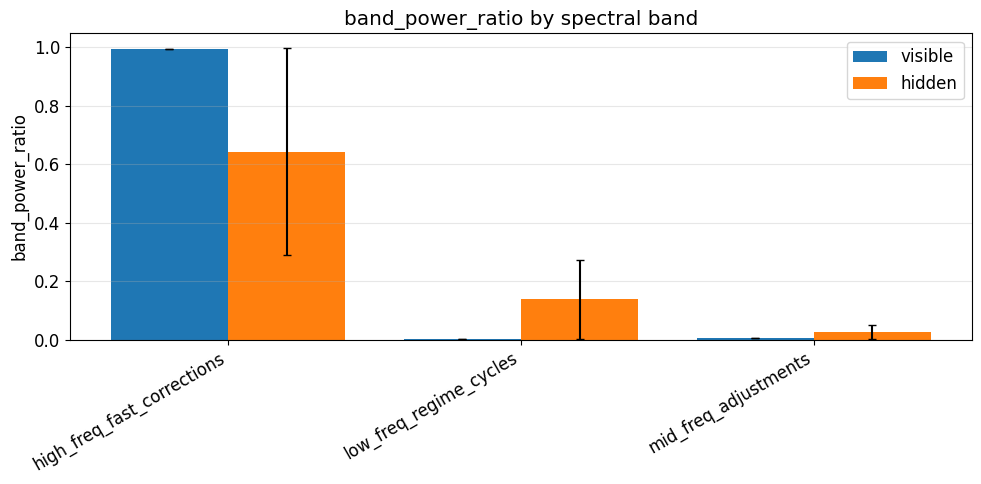

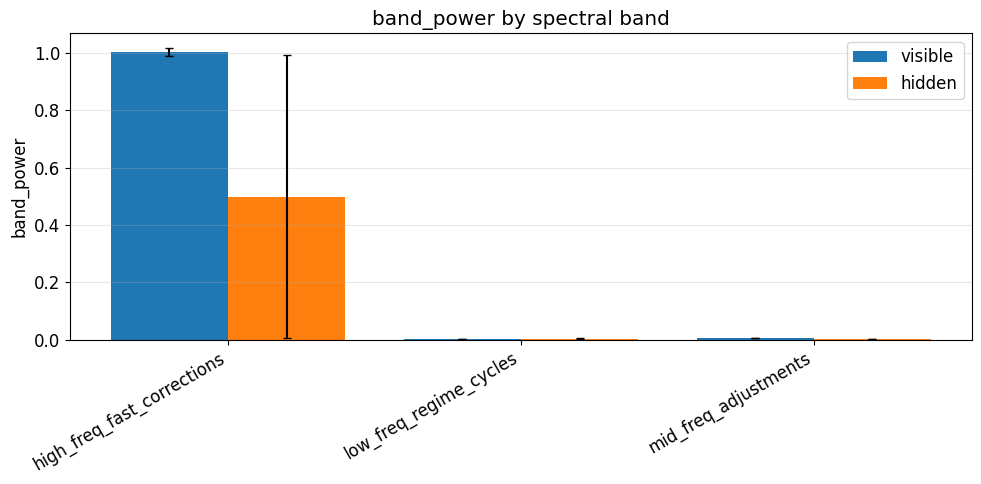

In [81]:
# plot spectral band analysis

period_bands = {
    "high_freq_fast_corrections": (1, 1000),
    "mid_freq_adjustments": (1000, 5000),
    "low_freq_regime_cycles": (5000, 30000),
}

runs = {
    "visible": [resource_A_lst[0].values[20000:], resource_A_lst[1].values[20000:]],
    "hidden": [resource_A_lst[2].values[20000:], resource_A_lst[3].values[20000:]],
}

run_band_df = spectral_summary_across_runs(
    runs,
    period_bands=period_bands,
    fs=1.0,
    nperseg=80000,
    analysis_period_range=(1, 40000),
    detrend_type="linear",
    standardize=True,
)

comparison_df = compare_all_bands(
    run_band_df,
    condition_a="visible",
    condition_b="hidden",
    value_cols=("band_power_ratio", "band_power"),
    paired=True,
    test="t",
)

print(run_band_df)
print(comparison_df)

plot_band_power_by_condition(
    run_band_df,
    value_col="band_power_ratio",
    condition_order=["visible", "hidden"],
)

plot_band_power_by_condition(
    run_band_df,
    value_col="band_power",
    condition_order=["visible", "hidden"],
)

In [ ]:
results = bidirectional_change_prediction(
    s_t=state_punishment_level_lst[0][2000:].rolling(window=1).mean(),
    x_t=resource_A_lst[0][2000:].rolling(window=1).mean(),
    H=1,
    K=1,
    standardize=True,
    hac=True,
    verbose=True,
)
coef_x_to_delta_s = results["coef_x_to_delta_s"]
coef_s_to_delta_x = results["coef_s_to_delta_x"]



In [ ]:
plot_joint_coefficient_distributions(results, bins=15)

In [ ]:
plot_change_prediction_coefficients(results)

In [ ]:
rolling_stats, all_coef_long = rolling_bidirectional_change_prediction_full(
    s_t=state_punishment_level_lst[0].rolling(window=1).mean(),
    x_t=resource_A_lst[0].rolling(window=1).mean(),
    window_size=1000,
    step_size=10,
    H=1,
    K=1,
    standardize=True,
    hac=True,
)

In [ ]:
plot_all_rolling_coefficient_trajectories(
    all_coef_long,
    direction="x_to_delta_s",
    show_legend=True,
)

plot_all_rolling_coefficient_trajectories(
    all_coef_long,
    direction="s_to_delta_x",
    show_legend=True,
)

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def phase_portrait_xy(
    x,
    y,
    x_name="s_t",
    y_name="x_t",
    title="Phase portrait",
    start=None,
    end=None,
    step=1,
    arrows=True,
    arrow_every=50,
    color_by_time=False,
    connect=False,
    point_size=10,
    line_alpha=0.25,
    point_alpha=0.5,
    arrow_scale=1,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    if start is None:
        start = 0
    if end is None:
        end = len(x)

    x = x[start:end:step]
    y = y[start:end:step]

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    t = np.arange(len(x))

    plt.figure(figsize=(7, 6))

    if connect:
        plt.plot(x, y, linewidth=1, alpha=line_alpha)

    if color_by_time:
        sc = plt.scatter(x, y, c=t, s=point_size, alpha=point_alpha)
        plt.colorbar(sc, label="time order")
    else:
        plt.scatter(x, y, s=point_size, alpha=point_alpha)

    if arrows and len(x) > 1:
        idx = np.arange(0, len(x) - 1, arrow_every)
        dx = x[idx + 1] - x[idx]
        dy = y[idx + 1] - y[idx]
        plt.quiver(
            x[idx],
            y[idx],
            dx,
            dy,
            angles="xy",
            scale_units="xy",
            scale=arrow_scale,
            width=0.006,
            alpha=0.8,
        )

    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

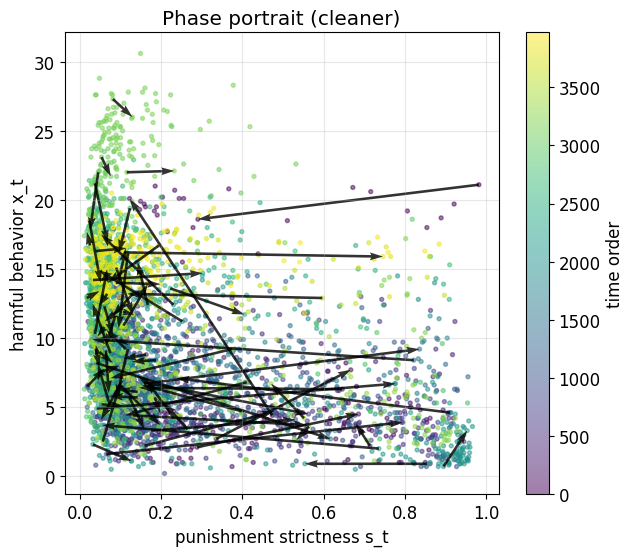

In [28]:
phase_portrait_xy(
    state_punishment_level_lst[0].rolling(window=1).mean(),
    resource_A_lst[0].rolling(window=1).mean(),
    x_name="punishment strictness s_t",
    y_name="harmful behavior x_t",
    title="Phase portrait (cleaner)",
    step=20,
    connect=False,
    color_by_time=True,
    arrows=True,
    arrow_every=50,
    point_size=8,
)

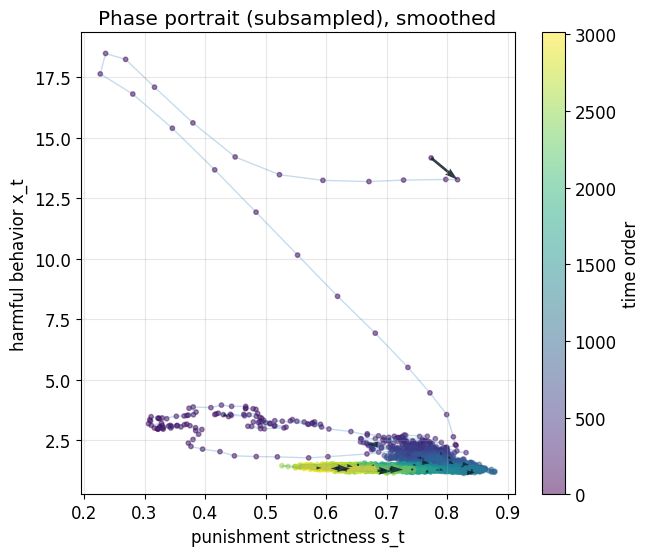

In [114]:
phase_portrait_xy(
    state_punishment_level_lst[0].rolling(window=200).mean(),
    resource_A_lst[0].rolling(window=200).mean(),
    x_name="punishment strictness s_t",
    y_name="harmful behavior x_t",
    title="Phase portrait (subsampled), smoothed",
    step=20,            # only every 50th point
    connect=True,      # no spaghetti line
    arrows=True,
    arrow_every=100,     # arrows every 20 plotted points
    color_by_time=True # cleaner
)

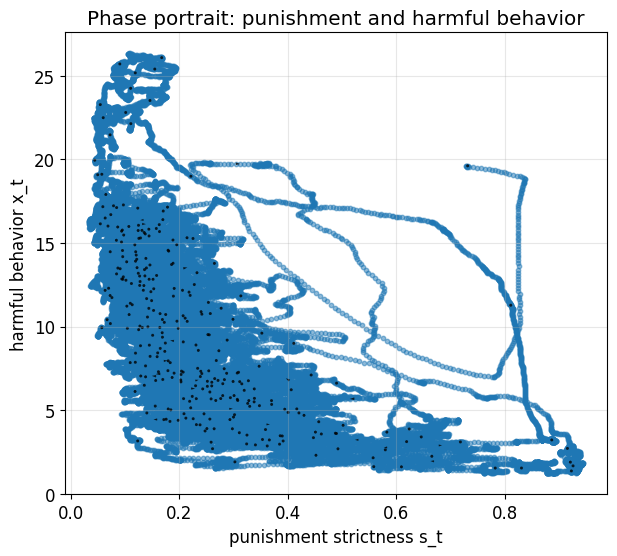

In [30]:
phase_portrait_xy(
    state_punishment_level_lst[0].rolling(window=100).mean(),
    resource_A_lst[0].rolling(window=100).mean(),
    x_name="punishment strictness s_t",
    y_name="harmful behavior x_t",
    title="Phase portrait: punishment and harmful behavior",
    arrow_every=250,
)

In [ ]:
fs

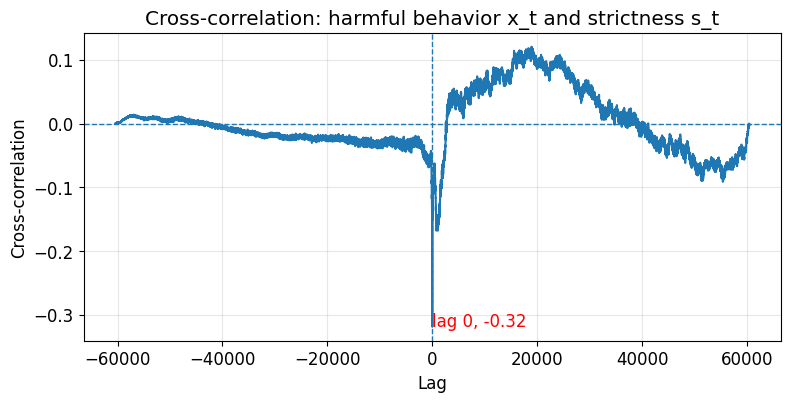

In [84]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import correlate, correlation_lags


x_t = resource_A_lst[0]
s_t = state_punishment_level_lst[0]



# x_t = harmful behavior
# s_t = punishment strictness

x0 = (x_t - np.mean(x_t)) / np.std(x_t)
s0 = (s_t - np.mean(s_t)) / np.std(s_t)

ccf = correlate(s0, x0, mode="full") / len(x0)
lags = correlation_lags(len(s0), len(x0), mode="full")

plt.figure(figsize=(9, 4))
plt.plot(lags, ccf)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

# find the lag with the lowest correlation and plot a vertical line at that lag, also add a text label with the correlation value
lag_with_lowest_correlation = np.argmin(ccf)
# plt.axvline(lags[lag_with_lowest_correlation], color="red", linestyle="--", linewidth=1)
plt.text(
    lags[lag_with_lowest_correlation], 
    ccf[lag_with_lowest_correlation], 
    f"lag {lags[lag_with_lowest_correlation]}, {ccf[lag_with_lowest_correlation]:.2f}",
    color="red",
    fontsize=12
)

plt.xlabel("Lag")
plt.ylabel("Cross-correlation")
# plt.xlim(-5000, 5000)
plt.title("Cross-correlation: harmful behavior x_t and strictness s_t")
plt.grid(alpha=0.3)
plt.show()




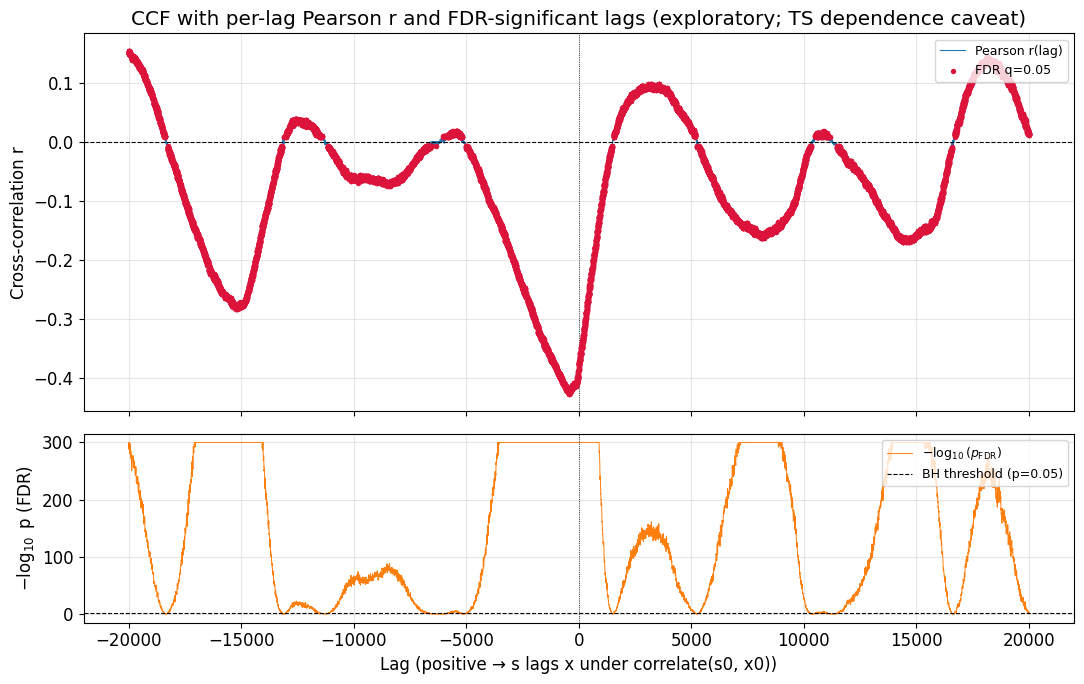

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests


def ccf_pearson_with_pvalues(s0, x0, max_lag=None):
    """Pearson r and two-sided p-value at each lag (alignment matches correlate(s0, x0))."""
    n = len(x0)
    if len(s0) != n:
        raise ValueError("s0 and x0 must have the same length")
    if max_lag is None:
        max_lag = n - 1
    max_lag = int(min(max_lag, n - 1))

    lags = np.arange(-max_lag, max_lag + 1)
    r = np.empty(len(lags))
    p = np.empty(len(lags))

    for i, k in enumerate(lags):
        if k >= 0:
            a, b = s0[k:], x0[: n - k]
        else:
            h = -k
            a, b = s0[: n - h], x0[h:]
        ri, pi = pearsonr(a, b)
        r[i] = ri
        p[i] = pi

    return lags, r, p


# --- data: use your z-scored series ---
# s0 = (s_t - np.mean(s_t)) / np.std(s_t)
# x0 = (x_t - np.mean(x_t)) / np.std(x_t)

# Limit |lag| for runtime (raise or set None for full range if n is modest)
max_lag = min(len(x0) - 1, 20000)

lags, r, p_raw = ccf_pearson_with_pvalues(s0, x0, max_lag=max_lag)

reject_fdr, p_fdr, _, _ = multipletests(p_raw, method="fdr_bh", alpha=0.05)

# --- plots ---
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
ax.plot(lags, r, lw=0.8, color="C0", label="Pearson r(lag)")
sig = reject_fdr
if np.any(sig):
    ax.scatter(lags[sig], r[sig], s=8, c="crimson", zorder=5, label="FDR q=0.05")
ax.axhline(0, color="k", ls="--", lw=0.8)
ax.axvline(0, color="k", ls=":", lw=0.6)
ax.set_ylabel("Cross-correlation r")
ax.set_title("CCF with per-lag Pearson r and FDR-significant lags (exploratory; TS dependence caveat)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

axp = axes[1]
logp = -np.log10(np.clip(p_fdr, 1e-300, None))
axp.plot(lags, logp, lw=0.7, color="C1", label=r"$-\log_{10}(p_{\mathrm{FDR}})$")
axp.axhline(-np.log10(0.05), color="k", ls="--", lw=0.8, label="BH threshold (p=0.05)")
axp.axvline(0, color="k", ls=":", lw=0.6)
axp.set_xlabel("Lag (positive → s lags x under correlate(s0, x0))")
axp.set_ylabel(r"$-\log_{10}$ p (FDR)")
axp.legend(loc="upper right", fontsize=9)
axp.grid(alpha=0.3)

plt.tight_layout()
plt.show()

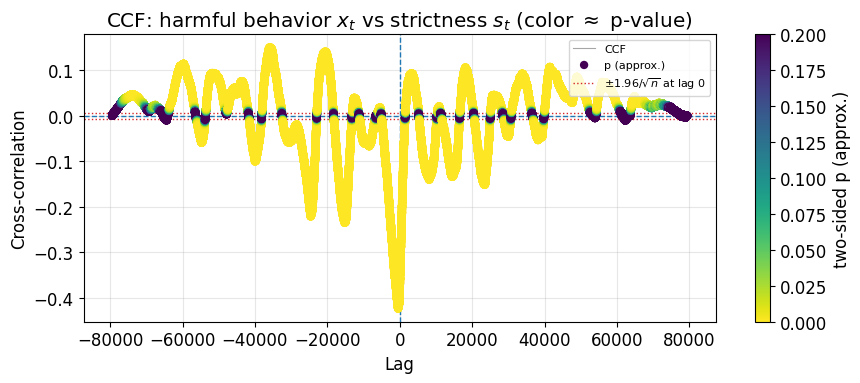

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.signal import correlate, correlation_lags

x_t = resource_A_lst[0]
s_t = state_punishment_level_lst[0]

x0 = (x_t - np.mean(x_t)) / np.std(x_t)
s0 = (s_t - np.mean(s_t)) / np.std(s_t)

n = len(x0)
ccf = correlate(s0, x0, mode="full") / n
lags = correlation_lags(len(s0), len(x0), mode="full")

# Overlapping sample count at each lag (equal-length series)
n_overlap = n - np.abs(lags)
n_overlap = np.maximum(n_overlap, 1)

# Approximate null: r_k ~ N(0, 1/n_overlap)  =>  z = r / SE
stderr = 1.0 / np.sqrt(n_overlap.astype(float))
z = np.abs(ccf) / stderr
p_two_sided = 2.0 * stats.norm.sf(z)

alpha = 0.05
sig = p_two_sided < alpha

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lags, ccf, color="0.5", linewidth=0.8, alpha=0.7, label="CCF")
sc = ax.scatter(
    lags,
    ccf,
    c=p_two_sided,
    cmap="viridis_r",
    s=25,
    vmin=0,
    vmax=0.2,
    zorder=3,
    label="p (approx.)",
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("two-sided p (approx.)")

ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(0, linestyle="--", linewidth=1)
ax.axhline(1.96 / np.sqrt(n), linestyle=":", color="C3", linewidth=1, label=r"$\pm 1.96/\sqrt{n}$ at lag 0")
ax.axhline(-1.96 / np.sqrt(n), linestyle=":", color="C3", linewidth=1)

ax.set_xlabel("Lag")
ax.set_ylabel("Cross-correlation")
ax.set_title("CCF: harmful behavior $x_t$ vs strictness $s_t$ (color $\\approx$ p-value)")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
specific_agent = 6
wsize = 10
end = None

In [ ]:
# ── config ──────────────────────────────────────────────────────────────────
resources = ["a", "b"]   # which resources to plot (one panel each)
# ────────────────────────────────────────────────────────────────────────────

def load_agent_encounter(folder, agent_idx, resource):
    fpath = f"{folder}/Agent_{agent_idx}_{resource}_encounters_data.csv"
    df = pd.read_csv(fpath)
    return df.set_index("Step")["Value"].sort_index()

for count, f in enumerate(fs_):
    agent_csv = find_agent_names_csv(f)
    if agent_csv:
        try:
            replacement_events, step_to_agent = get_agent_replacement_steps(agent_csv, specific_agent)
        except Exception as e:
            print(f"Error parsing {agent_csv}: {e}")
            replacement_events, step_to_agent = [], {}
    else:
        print(f"Missing agent_names.csv for {f}")
        replacement_events, step_to_agent = [], {}

    n_agents = sum(1 for fname in os.listdir(f) if fname.startswith("Agent_") and fname.endswith("_a_encounters_data.csv"))
    length = len(state_punishment_level_lst[count])
    end_ = length if end is None else end

    replacement_steps = set(ev[0] for ev in replacement_events)
    epoch_steps = range(0, end_, 10000)

    fig, axs = plt.subplots(len(resources), 1, figsize=(14, 4 * len(resources)), sharex=True)
    if len(resources) == 1:
        axs = [axs]

    agent_range = [specific_agent] if specific_agent is not None else range(n_agents)

    for ax, res in zip(axs, resources):
        for agent_i in agent_range:
            fpath = os.path.join(f, f"Agent_{agent_i}_{res}_encounters_data.csv")
            if not os.path.isfile(fpath):
                continue
            enc = load_agent_encounter(f, agent_i, res)
            ax.plot(enc[:end_].rolling(window=wsize).mean(), alpha=0.5, label=f"Agent {agent_i}")
            # ax.set_xlim(29800, 30200)
            if specific_agent is not None:
                break

        ax.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax.set_ylabel(f"Resource {res.upper()} encounters")
        ax.legend(loc="upper right", ncol=5, fontsize=7)
        for step in epoch_steps:
            ax.axvline(step,
                       color='red' if step in replacement_steps else 'gray',
                       linestyle=':', linewidth=2,
                       alpha=0.8 if step in replacement_steps else 0.5)

    axs[-1].set_xlabel("Step")
    plt.suptitle(f"Individual agent resource encounters — {condition_tags[count]}")
    plt.tight_layout()
    plt.show()

In [ ]:
specific_agent = 2
end = 60000
wsize = 1

In [ ]:
# Plot voting behaviors for a specific agent (per condition)
import csv, os

vote_increase_actions = [1, 4, 7, 10, 13]
vote_decrease_actions = [2, 5, 8, 11, 14]

def load_agent_vote(folder, agent_idx, action_idxs, length):
    total = None
    for a in action_idxs:
        df = pd.read_csv(f"{folder}/Agent_{agent_idx}_action_freq_action_{a}_data.csv")
        vals = df.set_index("Step")["Value"]  # align by actual epoch step
        total = vals if total is None else total.add(vals, fill_value=0)
    return total.sort_index()

def find_agent_names_csv(run_folder):
    base = os.path.basename(os.path.normpath(run_folder))
    here = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
    rp = here
    for _ in range(10):
        if os.path.basename(rp) == "state_punishment": break
        rp = os.path.dirname(rp)
    anims_root = os.path.join(rp, "data", "anims")
    head = os.path.join(anims_root, base)
    for _ in range(5):
        f = os.path.join(head, "agent_generation_reference", "agent_names.csv")
        if os.path.isfile(f): return f
        parent = os.path.dirname(head)
        if os.path.normpath(parent) == os.path.normpath(anims_root): break
        head = parent
    return None

def parse_agent_names(csv_path):
    rows = []
    with open(csv_path, newline='') as f:
        for row in csv.reader(f):
            if len(row) < 3: continue
            try:
                agent, ancestor, step = int(row[0]), int(row[1]), int(row[2])
                rows.append((step, ancestor, agent))
            except: continue
    return sorted(rows)

def get_agent_replacement_steps(csv_path, ancestor_id):
    events = []
    st2a = {}
    last_id = None
    filtered = sorted((s, aid) for (s, anc, aid) in parse_agent_names(csv_path) if anc == ancestor_id)
    for idx, (s, aid) in enumerate(filtered):
        if idx > 0 and aid != last_id: events.append((s, last_id, aid))
        last_id = aid
        st2a[s] = aid
    return events, st2a

for count, f in enumerate(fs_):
    agent_csv = find_agent_names_csv(f)
    if agent_csv:
        try:
            replacement_events, step_to_agent = get_agent_replacement_steps(agent_csv, specific_agent)
        except Exception as e:
            print(f"Error parsing {agent_csv}: {e}")
            replacement_events, step_to_agent = [], {}
    else:
        print(f"Missing agent_names.csv for {f}")
        replacement_events, step_to_agent = [], {}

    n_agents = sum(1 for fname in os.listdir(f) if fname.startswith("Agent_") and fname.endswith("_action_freq_action_1_data.csv"))
    length = len(state_punishment_level_lst[count])
    end_ = length if end is None else end

    replacement_steps = set(ev[0] for ev in replacement_events)
    epoch_steps = range(0, end_, 10000)

    fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    agent_range = [specific_agent] if specific_agent is not None else range(n_agents)
    for agent_i in agent_range:
        inc = load_agent_vote(f, agent_i, vote_increase_actions, length)
        dec = load_agent_vote(f, agent_i, vote_decrease_actions, length)
        diff = inc[:end_].rolling(window=wsize).mean() - dec[:end_].rolling(window=wsize).mean()
        axs[0].plot(inc[:end_].rolling(window=wsize).mean(), alpha=0.5, label=f"Agent {agent_i}")
        axs[1].plot(dec[:end_].rolling(window=wsize).mean(), alpha=0.5, label=f"Agent {agent_i}")
        axs[2].plot(diff, alpha=0.5, label=f"Agent {agent_i}")
        for ax in axs:
            ax.set_xlim(49900, 50100)
        if specific_agent is not None:
            break

    # axs[0].plot(vote_increase_lst[count][:end_].rolling(window=wsize).mean(), color="black", lw=2, ls="--", label="Mean")
    # axs[1].plot(vote_decrease_lst[count][:end_].rolling(window=wsize).mean(), color="black", lw=2, ls="--", label="Mean")
    combined_diff = vote_increase_lst[count][:end_].rolling(window=wsize).mean() - vote_decrease_lst[count][:end_].rolling(window=wsize).mean()
    # axs[2].plot(combined_diff, color="black", lw=2, ls="--", label="Mean")

    labels = ["Vote increase (per agent)", "Vote decrease (per agent)", "Vote increase - decrease (per agent)"]
    for ax, ylabel in zip(axs, labels):
        ax.axhline(2 if ylabel != labels[2] else 0, color="gray", linestyle="--", linewidth=1)
        ax.set_ylabel(ylabel)
        ax.legend(loc="upper right", ncol=5, fontsize=7)
        for step in epoch_steps:
            ax.axvline(step, color='red' if step in replacement_steps else 'gray', linestyle=':', linewidth=2, alpha=0.8 if step in replacement_steps else 0.5)
    axs[-1].set_xlabel("Step")
    plt.suptitle(f"Individual agent voting — {condition_tags[count]}")
    plt.tight_layout()
    plt.show()

In [ ]:
condition_tags = ['Punishment level visible']

In [ ]:
fs_

In [ ]:
wsize = 50
end = 200000

In [ ]:
def get_agent_statuses_v2(agent_names_csv):
    """
    Same as get_agent_statuses but also returns name_to_slot:
      name_to_slot[unique_agent_name] -> file slot (0-9)
    For original agents slot == name; for replacements slot == ancestor slot.
    """
    parsed = parse_agent_names(agent_names_csv)  # [(step, ancestor, agent)]
    if not parsed:
        return [], {}

    pop_by_step = {}
    name_to_slot = {}  # unique agent name -> file slot (0-9)
    for step, anc, agent in parsed:
        pop_by_step.setdefault(step, set()).add(agent)
        if agent not in name_to_slot:
            # originals: anc == agent -> slot = agent
            # replacements: slot = ancestor's slot (transitive)
            name_to_slot[agent] = name_to_slot.get(anc, anc)

    events = []
    prev_set = set()
    for epoch in sorted(pop_by_step):
        arr_now = pop_by_step[epoch]
        new     = arr_now - prev_set
        removed = prev_set - arr_now
        if new or removed or not prev_set:
            events.append({
                "step":          epoch,
                "present":       frozenset(arr_now),
                "removed":       removed,
                "new":           new,
                "old_survivors": arr_now & prev_set if prev_set else set(),
            })
        prev_set = set(arr_now)
    return events, name_to_slot


for count, f in enumerate(fs_):
    agent_csv = find_agent_names_csv(f)
    if not (agent_csv and os.path.exists(agent_csv)):
        print(f"Missing agent_names.csv for {f}")
        continue

    length = len(state_punishment_level_lst[count])
    end_   = length if end is None else end

    event_list, name_to_slot = get_agent_statuses_v2(agent_csv)

    replacement_events = [e for e in event_list if e["removed"] or e["new"]]
    relevant_events  = []
    new_agent_events = []
    for i, event in enumerate(replacement_events):
        if i == 0:
            continue
        next_step = replacement_events[i + 1]["step"] if i + 1 < len(replacement_events) else end_
        relevant_events.append((event["step"], event["old_survivors"], min(next_step, end_)))
        new_agent_events.append((event["step"], event["new"],           min(next_step, end_)))

    if not relevant_events and not new_agent_events:
        print(f"No replacement events for {condition_tags[count]}")
        continue

    # Pre-load diff series for all agents (old survivors + new agents)
    all_agent_ids = set()
    for _, agents, _ in relevant_events:  all_agent_ids |= set(agents)
    for _, agents, _ in new_agent_events: all_agent_ids |= set(agents)

    agent_diffs = {}
    for agent_i in sorted(all_agent_ids):
        slot  = name_to_slot.get(agent_i, agent_i)  # resolve file slot
        fname = os.path.join(f, f"Agent_{slot}_action_freq_action_1_data.csv")
        if not os.path.isfile(fname):
            continue
        try:
            inc = load_agent_vote(f, slot, vote_increase_actions, length)
            dec = load_agent_vote(f, slot, vote_decrease_actions, length)
            agent_diffs[agent_i] = (inc - dec).loc[:end_].fillna(0)
        except Exception as e:
            print(f"  Failed agent {agent_i} (slot {slot}): {e}")

    def plot_cohort(events, title_suffix, ylabel_suffix, ax_obj):
        has_data = False
        for ei, (step, agents, next_step) in enumerate(events):
            t0, t1 = step, next_step
            segs = []
            for agent_i in agents:
                series = agent_diffs.get(agent_i)
                if series is None:
                    continue
                seg = series.loc[t0:t1]
                if seg.empty:
                    continue
                seg_smoothed = seg.rolling(window=wsize, min_periods=1).mean()
                if np.all(np.isnan(seg_smoothed.values)):
                    continue
                segs.append(seg_smoothed)
            if not segs:
                ax_obj.axvline(step, color="red", linestyle=":", linewidth=2, alpha=0.4)
                continue
            combined = pd.concat(segs, axis=1)
            mean_seg = combined.mean(axis=1)
            ax_obj.plot(mean_seg.index.values, mean_seg.values,
                    color=f"C{ei % 10}", lw=1.5, alpha=0.85, label=f"after step {step}")
            ax_obj.axvline(step, color="red", linestyle=":", linewidth=2, alpha=0.7)
            has_data = True
        # if has_data:
            # ax_obj.legend(fontsize=8, loc="upper right")
        ax_obj.set_xlabel("Step")
        ax_obj.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax_obj.set_ylabel(f"Mean vote ↑ − ↓ (smoothed, {ylabel_suffix})")
        ax_obj.set_title(f"{title_suffix} — {condition_tags[count]}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
    plot_cohort(relevant_events,  "Old surviving agents avg, vote ↑ − ↓ after replacement", "old survivors", ax1)
    plot_cohort(new_agent_events, "New agents avg, vote ↑ − ↓ after replacement",           "new agents",    ax2)
    plt.tight_layout()
    plt.show()

In [ ]:
ax1_twin = ax1.twinx()
ax1_twin.plot(np.arange(len(punishment_data)), punishment_data, color='b', alpha=0.25)
ax2_twin = ax2.twinx()
ax2_twin.plot(np.arange(len(punishment_data)), punishment_data, color='b', alpha=0.25)
ax1_twin.set_ylabel('Punishment level')
ax2_twin.set_ylabel('Punishment level')
fig

In [ ]:
wsize=1

In [ ]:
from turnover_cohort_vote_trajectories import (
    plot_turnover_vote_cohorts,
    aligned_turnover_cohort_means,
    find_agent_names_csv,
)
X = 0
Y = 20000
wsize = 1
for count, f in enumerate(fs_):
    # One run (e.g. inside your loop over fs_):
    fig, axes, res = plot_turnover_vote_cohorts(
        f,
        length=len(state_punishment_level_lst[count]),
        end_=end,  # or None for full length
        vote_increase_actions=vote_increase_actions,
        vote_decrease_actions=vote_decrease_actions,
        window_before=X,
        window_after=Y,
        smooth_window=wsize,
        title_prefix=f"{condition_tags[count]} — ",
    )
    for k in range(Y//10000):
        for ax in axes:
            ax.axvline(0 + k * 10000, color="red", linestyle=":", linewidth=2, alpha=0.7)
    plt.show()

    # Or only the series (e.g. custom plots / stats):
    agent_csv = find_agent_names_csv(f)
    res = aligned_turnover_cohort_means(
        f, agent_csv,
        length=len(state_punishment_level_lst[count]),
        end_=end,
        vote_increase_actions=vote_increase_actions,
        vote_decrease_actions=vote_decrease_actions,
        window_before=X,
        window_after=Y,
        smooth_window=wsize,
    )
# res["old_survivors"], res["new_agents"] — Series on res["offsets"]
# res["n_episodes_old"], res["n_episodes_new"]

In [ ]:
wsize = 10

In [ ]:
# ── config ──────────────────────────────────────────────────────────────────
resource = "a"   # change to "b", "c", "d", "e", etc.
# ────────────────────────────────────────────────────────────────────────────

def load_agent_encounter(folder, slot, resource, length):
    """Load a single resource-encounter series for one agent slot."""
    fpath = os.path.join(folder, f"Agent_{slot}_{resource}_encounters_data.csv")
    df = pd.read_csv(fpath)
    vals = df.set_index("Step")["Value"]
    return vals.sort_index()


def get_agent_statuses_v2(agent_names_csv):
    parsed = parse_agent_names(agent_names_csv)  # [(step, ancestor, agent)]
    if not parsed:
        return [], {}

    pop_by_step = {}
    name_to_slot = {}
    for step, anc, agent in parsed:
        pop_by_step.setdefault(step, set()).add(agent)
        if agent not in name_to_slot:
            name_to_slot[agent] = name_to_slot.get(anc, anc)

    events = []
    prev_set = set()
    for epoch in sorted(pop_by_step):
        arr_now = pop_by_step[epoch]
        new     = arr_now - prev_set
        removed = prev_set - arr_now
        if new or removed or not prev_set:
            events.append({
                "step":          epoch,
                "present":       frozenset(arr_now),
                "removed":       removed,
                "new":           new,
                "old_survivors": arr_now & prev_set if prev_set else set(),
            })
        prev_set = set(arr_now)
    return events, name_to_slot


for count, f in enumerate(fs_):
    agent_csv = find_agent_names_csv(f)
    if not (agent_csv and os.path.exists(agent_csv)):
        print(f"Missing agent_names.csv for {f}")
        continue

    length = len(state_punishment_level_lst[count])
    end_   = length if end is None else end

    event_list, name_to_slot = get_agent_statuses_v2(agent_csv)

    replacement_events = [e for e in event_list if e["removed"] or e["new"]]
    relevant_events  = []
    new_agent_events = []
    for i, event in enumerate(replacement_events):
        if i == 0:
            continue
        next_step = replacement_events[i + 1]["step"] if i + 1 < len(replacement_events) else end_
        relevant_events.append((event["step"], event["old_survivors"], min(next_step, end_)))
        new_agent_events.append((event["step"], event["new"],           min(next_step, end_)))

    if not relevant_events and not new_agent_events:
        print(f"No replacement events for {condition_tags[count]}")
        continue

    all_agent_ids = set()
    for _, agents, _ in relevant_events:  all_agent_ids |= set(agents)
    for _, agents, _ in new_agent_events: all_agent_ids |= set(agents)

    agent_series = {}
    for agent_i in sorted(all_agent_ids):
        slot  = name_to_slot.get(agent_i, agent_i)
        fname = os.path.join(f, f"Agent_{slot}_{resource}_encounters_data.csv")
        if not os.path.isfile(fname):
            continue
        try:
            series = load_agent_encounter(f, slot, resource, length)
            agent_series[agent_i] = series.loc[:end_].fillna(0)
        except Exception as e:
            print(f"  Failed agent {agent_i} (slot {slot}): {e}")

    def plot_cohort(events, title_suffix, ylabel_suffix, ax_obj):
        has_data = False
        for ei, (step, agents, next_step) in enumerate(events):
            t0, t1 = step, next_step
            segs = []
            for agent_i in agents:
                series = agent_series.get(agent_i)
                if series is None:
                    continue
                seg = series.loc[t0:t1]
                if seg.empty:
                    continue
                seg_smoothed = seg.rolling(window=wsize, min_periods=1).mean()
                if np.all(np.isnan(seg_smoothed.values)):
                    continue
                segs.append(seg_smoothed)
            if not segs:
                ax_obj.axvline(step, color="red", linestyle=":", linewidth=2, alpha=0.4)
                continue
            combined = pd.concat(segs, axis=1)
            mean_seg = combined.mean(axis=1)
            ax_obj.plot(mean_seg.index.values, mean_seg.values,
                    color=f"C{ei % 10}", lw=1.5, alpha=0.85, label=f"after step {step}")
            ax_obj.axvline(step, color="red", linestyle=":", linewidth=2, alpha=0.7)
            has_data = True
        # if has_data:
        #     ax_obj.legend(fontsize=8, loc="upper right")
        ax_obj.set_xlabel("Step")
        # ax_obj.set_xlim(143000, 151100)
        ax_obj.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax_obj.set_ylabel(f"Mean {resource.upper()} encounters (smoothed, {ylabel_suffix})")
        ax_obj.set_title(f"{title_suffix} — {condition_tags[count]}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
    plot_cohort(relevant_events,  f"Old survivors — resource {resource.upper()} encounters after replacement", "old survivors", ax1)
    plot_cohort(new_agent_events, f"New agents — resource {resource.upper()} encounters after replacement",    "new agents",    ax2)
    plt.tight_layout()
    plt.show()

In [ ]:
ax1_twin = ax1.twinx()
ax1_twin.plot(np.arange(len(punishment_data)), punishment_data, color='b', alpha=0.25)
ax2_twin = ax2.twinx()
ax2_twin.plot(np.arange(len(punishment_data)), punishment_data, color='b', alpha=0.25)
ax1_twin.set_ylabel('Punishment level')
ax2_twin.set_ylabel('Punishment level')

fig

In [ ]:
from cohort_turnover import plot_turnover_encounter_cohorts
X = 1000
Y = 1000
end = None
wsize = 1
fig, axes, res = plot_turnover_encounter_cohorts(
    f,
    resource="a",
    length=len(state_punishment_level_lst[count]),
    end_=end,
    window_before=X,
    window_after=Y,
    smooth_window=wsize,
    max_turnover_events=18,  # optional
    title_prefix=f"{condition_tags[count]} — ",
)
plt.show()

In [ ]:
(vote_increase_lst[0][:10] - vote_decrease_lst[0][:10]).mean()

In [ ]:
np.mean(reward_series_lst[0][20000:120000]) - np.mean(reward_series_lst[1][20000:120000])

In [ ]:
plt.plot(np.arange(60000), reward_series_lst[0][20000:80000] - reward_series_lst[1][20000:80000])

In [ ]:
fs_

In [ ]:
diff = reward_series_lst[0][20000:90000] - reward_series_lst[1][20000:90000]
plt.plot(diff)
plt.show()

In [ ]:
plt.hist(state_punishment_level_lst[0][20000:90000], bins=100, label='Punishment level invisible', alpha=0.5)
plt.hist(state_punishment_level_lst[1][20000:90000], bins=100, label='Punishment level visible', alpha=0.5)
plt.legend()
plt.show()

In [ ]:
plt.hist(reward_series_lst[0][20000:90000], bins=100, label='Punishment level invisible', alpha=0.5)
plt.hist(reward_series_lst[1][20000:90000], bins=100, label='Punishment level visible', alpha=0.5)
plt.legend()
plt.show()



In [ ]:
np.std(reward_series_lst[0][50000:130000]) - np.std(reward_series_lst[1][50000:130000])

In [ ]:
np.std(state_punishment_level_lst[0][10000:60000]) - np.std(state_punishment_level_lst[1][10000:60000])

In [ ]:
policy_entropy(state_punishment_level_lst[0][40000:120000]) - policy_entropy(state_punishment_level_lst[1][40000:120000])

In [ ]:
np.mean(state_punishment_level_lst[0][60000:120000]) - np.mean(state_punishment_level_lst[1][60000:120000])

In [ ]:
policy_entropy(state_punishment_level_lst[0][20000:140000]) - policy_entropy(state_punishment_level_lst[1][20000:140000])

In [ ]:
len(state_punishment_level_lst[0][40000:170000]), len(state_punishment_level_lst[1][40000:170000])

In [ ]:
fs_

In [ ]:
x_cpc = state_punishment_level_lst[1][20000:90000]
x_no_cpc = state_punishment_level_lst[0][20000:90000]
xs = np.sort(np.unique(np.concatenate([x_cpc, x_no_cpc])))

S_cpc = np.array([np.mean(x_cpc > t) for t in xs])
S_no  = np.array([np.mean(x_no_cpc > t) for t in xs])

plt.plot(xs, S_no, label="Punishment level invisible")
plt.plot(xs, S_cpc, label="Punishment level visible")

plt.xlabel("x")
plt.ylabel("P(X > x)")
plt.legend()
plt.show()

In [ ]:
plt.hist(state_punishment_level_lst[0][20000:140000], bins=100, label='No CPC', alpha=0.5)
plt.hist(state_punishment_level_lst[1][20000:140000], bins=100, label='CPC', alpha=0.5)
plt.legend()
plt.show()

In [ ]:
from scipy.signal import welch
import numpy as np

def spectral_centroid_scipy(x, fs=1.0):
    x = x - np.mean(x)
    freqs, power = welch(x, fs=fs, nperseg=min(256, len(x)))
    
    # remove DC
    freqs = freqs[1:]
    power = power[1:]
    
    return np.sum(freqs * power) / np.sum(power)

In [ ]:
spectral_centroid_scipy(state_punishment_level_lst[0][10000:]) - spectral_centroid_scipy(state_punishment_level_lst[1][10000:])

In [ ]:

def lag1_autocorrelation(x):
    """
    Compute lag-1 autocorrelation of a time series.

    Parameters
    ----------
    x : array-like
        1D time series

    Returns
    -------
    rho1 : float
        Lag-1 autocorrelation
    """
    x = np.asarray(x)
    if len(x) < 2:
        return np.nan
    
    x = x - np.mean(x)
    return np.dot(x[:-1], x[1:]) / np.dot(x, x)

In [ ]:
lag1_autocorrelation(state_punishment_level_lst[0][10000:]) - lag1_autocorrelation(state_punishment_level_lst[1][10000:])

In [ ]:
import numpy as np

import numpy as np

def dwell_total_extremes(x, low_q=0.1, high_q=0.9):
    """
    Compute total time spent in low and high extreme regimes.

    Parameters
    ----------
    x : array-like
        1D time series
    low_q : float
        Lower quantile threshold (default 0.1)
    high_q : float
        Upper quantile threshold (default 0.9)

    Returns
    -------
    result : dict
        {
            "low_total": total steps in low regime,
            "high_total": total steps in high regime,
            "extreme_total": total steps in either extreme,
            "low_fraction": fraction of time low,
            "high_fraction": fraction of time high,
            "extreme_fraction": fraction of time extreme
        }
    """
    x = np.asarray(x)
    n = len(x)
    
    low_th = np.quantile(x, low_q)
    high_th = np.quantile(x, high_q)
    
    low_mask = x <= low_th
    high_mask = x >= high_th
    
    low_total = np.sum(low_mask)
    high_total = np.sum(high_mask)
    
    return {
        "low_total": int(low_total),
        "high_total": int(high_total),
        "extreme_total": int(low_total + high_total),
        "low_fraction": low_total / n,
        "high_fraction": high_total / n,
        "extreme_fraction": (low_total + high_total) / n
    }

In [ ]:
dwell_total_extremes(state_punishment_level_lst[0][10000:60000]), dwell_total_extremes(state_punishment_level_lst[1][10000:60000])

In [ ]:
reward_series_1 = reward_series

In [ ]:
plt.plot(reward_series_1.rolling(window=wsize).mean(), label='reward_ppo', color='tab:purple')
plt.plot(reward_series.rolling(window=wsize).mean(), label='reward_iqn', color='tab:blue')
plt.legend()
plt.show()


In [ ]:
wsize = 100
# plot the metrics separately
plt.figure(figsize=(12, 10))
plt.subplot(6, 1, 1)
plt.plot(state_punishment_level.rolling(window=wsize).mean(), label='state punishment level', color='tab:blue')
plt.ylabel('Punishment level')
plt.ylim(0, 1)
plt.legend()
plt.subplot(6, 1, 2)
plt.plot(social_harm_received.rolling(window=wsize).mean(), label='social harm received', color='tab:orange')
plt.ylabel('Collective Harm')
plt.legend()
plt.subplot(6, 1, 3)
plt.plot(vote_increase.rolling(window=wsize).mean(), label='vote increase', color='tab:green')
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Vote increase')
plt.legend()
plt.subplot(6, 1, 4)
plt.plot(vote_decrease.rolling(window=wsize).mean(), label='vote decrease', color='tab:red')
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Vote decrease')
plt.legend()
plt.subplot(6, 1, 5)
plt.plot(reward_series.rolling(window=wsize).mean(), label='reward', color='tab:purple')
plt.ylabel('Reward')
plt.legend()
plt.subplot(6, 1, 6)
plt.plot(resource_total.rolling(window=wsize).mean(), label='resource total', color='tab:purple')
plt.ylabel('Resource total')
plt.legend()
# plt.ylim(0, 7)
# plt.xticks([])
# plt.xlabel('Step')
plt.tight_layout()
plt.show()



In [ ]:
# only plot the state punishment level
plt.figure(figsize=(12, 6))
wsize = 100
plt.plot(state_punishment_level.rolling(window=wsize).mean(), label='state punishment level', color='tab:blue')
plt.ylabel('Punishment Level')
plt.axhline()
plt.ylim(0, 1)
plt.legend()
plt.show()

In [ ]:
social_harm_received_smooth

In [ ]:
# plot the social harm and punishment levels together
wsize = 500
plt.figure(figsize=(12, 6))
social_harm_received_smooth = moving_avg(social_harm_received, wsize)
state_punishment_level_smooth = moving_avg(state_punishment_level, wsize)
zscore_social_harm_received = zscore(social_harm_received_smooth)
zscore_state_punishment_level = zscore(state_punishment_level_smooth)
plt.plot(np.arange(len(zscore_social_harm_received)), zscore_social_harm_received, label='social harm', color='tab:orange')
plt.plot(np.arange(len(zscore_state_punishment_level)), zscore_state_punishment_level, label='punishment', color='tab:blue')
plt.legend()
# plt.xlim(0, 120000)
plt.show()


In [ ]:
# plot the social harm and punishment levels together
wsize = 500
plt.figure(figsize=(12, 6))
social_harm_received_smooth = moving_avg(social_harm_received, wsize)
state_punishment_level_smooth = moving_avg(state_punishment_level, wsize)
zscore_social_harm_received = zscore(social_harm_received_smooth)
zscore_state_punishment_level = zscore(state_punishment_level_smooth)
plt.plot(np.arange(len(zscore_social_harm_received)), zscore_social_harm_received, label='social harm', color='tab:orange')
plt.plot(np.arange(len(zscore_state_punishment_level)), zscore_state_punishment_level, label='punishment', color='tab:blue')
plt.legend()
plt.show()


## cross corr analyses

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ============================================================
# 0) LOAD DATA (ONLY PLACE WHERE DATA ENTERS THE PIPELINE)
# ============================================================
# These must exist in your session. Replace with your own loading if needed.
# social_harm = ...
# punishment_levels = ...
# social_harm = np.asarray(social_harm, dtype=float)
# punishment_levels = np.asarray(punishment_levels, dtype=float)

assert social_harm.ndim == 1 and punishment_levels.ndim == 1
assert len(social_harm) == len(punishment_levels)

# ============================================================
# 1) PARAMETERS
# ============================================================
k = 400           # smoothing window for harm (set 1 to disable)
max_lag = 2000    # max lag for cross-correlation (steps)
train_frac = 0.7  # train/test split
start_timepoint = 10000
# ============================================================
# 2) HELPERS
# ============================================================
def moving_avg(x, k):
    if k <= 1:
        return x.copy()
    return np.convolve(x, np.ones(k)/k, mode="same")

def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / (x.std() + 1e-12)

def mse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.mean((a-b)**2))

def fit_ols(y, X, train_idx):
    model = sm.OLS(y[train_idx], X[train_idx]).fit()
    pred = model.predict(X)
    return model, pred

def crosscorr(h, s, max_lag):
    """
    corr(h_t, s_{t+lag}) for lag in [-max_lag, +max_lag].
    Positive lag => harm leads punishment.
    """
    h = zscore(h)
    s = zscore(s)
    lags = np.arange(-max_lag, max_lag+1)
    cc = np.empty_like(lags, dtype=float)
    for i, L in enumerate(lags):
        if L < 0:
            hh = h[-L:]
            ss = s[:len(hh)]
        elif L > 0:
            hh = h[:-L]
            ss = s[L:]
        else:
            hh = h
            ss = s
        if len(hh) < 5:
            cc[i] = np.nan
        else:
            cc[i] = np.corrcoef(hh, ss)[0, 1]
    return lags, cc

# ============================================================
# 3) PREP DATA
# ============================================================
h = np.array(social_harm[start_timepoint:])
s = np.array(punishment_levels[start_timepoint:])
s = moving_avg(s, k)
# s = moving_avg(s_raw, k)
h_smooth = moving_avg(h, k)

ds = np.diff(s)   # Δs_t
dh = np.diff(h)   # Δh_t

T = len(h)
N = T - 1
split = int(train_frac * N)
train_idx = np.arange(split)
test_idx = np.arange(split, N)

st = s[:-1]
ht = h_smooth[:-1]

print(f"T={T} (N for diffs={N}); train={len(train_idx)}, test={len(test_idx)}")

# ============================================================
# 4) (A) TRACKING: Δs_t ~ 1 + h_smooth_t + s_t
# ============================================================
X_track = np.column_stack([np.ones(N), ht, st])
model_track, pred_track = fit_ols(ds, X_track, train_idx)

print("\n=== Tracking model: Δs_t ~ 1 + h_smooth_t + s_t ===")
print(model_track.summary())

# Noise-only comparator: Δs_t ~ 1 + s_t
X_noise = np.column_stack([np.ones(N), st])
model_noise, pred_noise = fit_ols(ds, X_noise, train_idx)

mse_track = mse(ds[test_idx], pred_track[test_idx])
mse_noise = mse(ds[test_idx], pred_noise[test_idx])

print("\nOut-of-sample MSE (lower is better):")
print(f"  noise-only (Δs~s): {mse_noise:.6g}")
print(f"  tracking (Δs~h+s): {mse_track:.6g}")

plt.figure(figsize=(9,4))
plt.plot(ds[test_idx], label="actual Δs (test)")
plt.plot(pred_noise[test_idx], label="pred noise-only")
plt.plot(pred_track[test_idx], label="pred tracking")
plt.axhline(0, linestyle="--")
plt.title("Δs prediction on test set")
plt.xlabel("test index (time)")
plt.ylabel("Δ punishment")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 5) (B) SUPPRESSION: Δh_t ~ 1 + s_t + h_smooth_t
# ============================================================
X_suppress = np.column_stack([np.ones(N), st, ht])
model_suppress, pred_suppress = fit_ols(dh, X_suppress, train_idx)

print("\n=== Suppression model: Δh_t ~ 1 + s_t + h_smooth_t ===")
print(model_suppress.summary())

plt.figure(figsize=(9,4))
plt.plot(dh[test_idx], label="actual Δh (test)")
plt.plot(pred_suppress[test_idx], label="pred suppression")
plt.axhline(0, linestyle="--")
plt.title("Δh prediction on test set")
plt.xlabel("test index (time)")
plt.ylabel("Δ harm")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 6) (C) CROSS-CORRELATION: corr(h_t, s_{t+lag})
# ============================================================
h_smooth = h_smooth[lag:]
s = s[lag:] - s[:-lag]
lags, cc = crosscorr(h_smooth, s, max_lag=max_lag)

plt.figure(figsize=(10,4))
plt.plot(lags, cc)
plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.title("Cross-correlation: corr(h_t, s_{t+lag})  (positive lag = harm leads)")
plt.xlabel("lag (steps)")
plt.ylabel("correlation")
plt.tight_layout()
plt.show()

valid = np.isfinite(cc)
lags_v = lags[valid]
cc_v = cc[valid]

# best lags on each side
pos_mask = lags_v >= 0
neg_mask = lags_v <= 0
if np.any(pos_mask):
    best_pos_lag = lags_v[pos_mask][np.argmax(cc_v[pos_mask])]
    best_pos_corr = cc[lags == best_pos_lag][0]
    print(f"\nPeak corr at lag>=0: lag={best_pos_lag}, corr={best_pos_corr:.4f}")
if np.any(neg_mask):
    best_neg_lag = lags_v[neg_mask][np.argmax(cc_v[neg_mask])]
    best_neg_corr = cc[lags == best_neg_lag][0]
    print(f"Peak corr at lag<=0: lag={best_neg_lag}, corr={best_neg_corr:.4f}")


In [ ]:
f = [
    "res/runs_debug3/validation_punishment_structure_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251219-004358",
    "res/runs_debug3/simple_params_v5_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-152834",
    "res/runs_debug3/corrected_simple_params_gamma0.95_v4_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-225406",
    "res/runs_debug3/corrected_simple_params_v4_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-225255",
    "res/runs_debug3/simple_params_v4_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251216-224938",
    "res/runs_debug3/original_params_learningparamsv2_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251215-152637",
    'res/runs_debug2/p25_simple_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251209-163058',
    'res/runs_debug2/p25_simple_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251209-162807',
    'res/runs_debug2/simple_params_epsilon0.0_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_2a_pknown_sknown_20251209-162411'
][0]
f= 'res/runs_debug3/validate_10agents_complex_params_corrected_values_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260101-203440'# parameters
f = 'res/runs_debug3/validate_3agents_complex_params_corrected_values_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_iqn_sp_r0.005_v4_m10_cvFalse_meTrue_3a_pknown_sknown_20260101-203024'
f = 'res/runs_debug3/validate_ppo_10agents_orginal_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_norep_none_ppo_dual_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260104-200742'

wsize = 1
# Load social harm and punishment data
social_harm = pd.read_csv(f'{f}/Mean_mean_social_harm_received_data.csv')
punishment_levels = pd.read_csv(f'{f}/Global_average_punishment_level_data.csv')
vote_increase_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_increase_data.csv')
vote_decrease_freq = pd.read_csv(f'{f}/Mean_mean_action_freq_vote_decrease_data.csv')


# remove missing values
social_harm = social_harm.rename(columns={'Value': 'social_harm'})
punishment_levels = punishment_levels.rename(columns={'Value': 'punishment_levels'})
vote_increase_freq = vote_increase_freq.rename(columns={'Value': 'vote_increase_freq'})
vote_decrease_freq = vote_decrease_freq.rename(columns={'Value': 'vote_decrease_freq'})
df_harm_and_punishment = pd.concat([social_harm, punishment_levels], axis=1)
df_harm_and_punishment = df_harm_and_punishment.dropna()
social_harm = df_harm_and_punishment['social_harm'].rolling(window=wsize).mean()
punishment_levels = df_harm_and_punishment['punishment_levels'].rolling(window=wsize).mean()

In [ ]:
# ============================================================
# (C) Lag/Delay evidence for the two legs of the loop
#   Leg 1: harm -> punishment updates   corr(h_t, Δs_{t+lag})
#   Leg 2: punishment -> harm changes   corr(s_t, Δh_{t+lag})
#
# All data must be loaded/defined AT THE TOP.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 0) LOAD DATA HERE
# ----------------------------
# social_harm = ...
# punishment_levels = ...

# social_harm = np.asarray(social_harm, dtype=float)
# punishment_levels = np.asarray(punishment_levels, dtype=float)
assert social_harm.ndim == 1 and punishment_levels.ndim == 1
assert len(social_harm) == len(punishment_levels)
T = len(social_harm)

# ----------------------------
# 1) PARAMETERS (edit freely)
# ----------------------------
k_h = 200      # smooth harm (set 1 to disable)
k_s = 200          # optionally smooth punishment too (try 1, 50, 200)
max_lag = 5000   # lags in steps to evaluate
min_pairs = 50   # minimum aligned samples per lag
start_timepoint = 10000
# ----------------------------
# 2) HELPERS
# ----------------------------
def moving_avg(x, k):
    if k <= 1:
        return x.copy()
    return np.convolve(x, np.ones(k)/k, mode="same")

def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / (x.std() + 1e-12)

def lagged_corr(x, y, lags, min_pairs=50):
    """
    Compute corr(x_t, y_{t+lag}) across lags.
    Positive lag => x leads y.
    """
    x = zscore(x)
    y = zscore(y)
    cc = np.full_like(lags, np.nan, dtype=float)
    for i, L in enumerate(lags):
        if L < 0:
            xx = x[-L:]
            yy = y[:len(xx)]
        elif L > 0:
            xx = x[:-L]
            yy = y[L:]
        else:
            xx = x
            yy = y
        if len(xx) >= min_pairs:
            cc[i] = np.corrcoef(xx, yy)[0, 1]
    return cc

def peak_info(cc, lags, direction="max", lag_domain="pos"):
    mask = np.isfinite(cc)
    if lag_domain == "pos":
        mask &= (lags >= 0)
    elif lag_domain == "neg":
        mask &= (lags <= 0)
    if not np.any(mask):
        return None
    vals = cc[mask]
    idx = int(np.argmax(vals)) if direction == "max" else int(np.argmin(vals))
    return int(lags[mask][idx]), float(vals[idx])

# ----------------------------
# 3) PREP SIGNALS
# ----------------------------
h = np.array(social_harm[start_timepoint:])
s = np.array(punishment_levels[start_timepoint:])

h_smooth = moving_avg(h, k_h)
s_smooth = moving_avg(s, k_s)

ds = np.diff(s_smooth)   # Δs_t, length T-1
dh = np.diff(h_smooth)   # Δh_t, length T-1

# Drivers at time t (also length T-1)
h_t = h_smooth[:-1]
s_t = s_smooth[:-1]

lags = np.arange(-max_lag, max_lag + 1)

# ----------------------------
# 4) LEG-SPECIFIC LAG CORRS
# ----------------------------
# Leg 1 (expected positive at lag>=0): harm leads punishment updates
cc_h_to_ds = lagged_corr(h_t, ds, lags, min_pairs=min_pairs)

# Leg 2 (expected negative at lag>=0): punishment leads harm changes
cc_s_to_dh = lagged_corr(s_t, dh, lags, min_pairs=min_pairs)

# ----------------------------
# 5) PLOTS
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(lags, cc_h_to_ds)
plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.title("Leg 1: corr(hₜ, Δsₜ₊ₗₐg)  (positive lag => harm leads punishment updates)")
plt.xlabel("lag (steps)")
plt.ylabel("correlation")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(lags, cc_s_to_dh)
plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.title("Leg 2: corr(sₜ, Δhₜ₊ₗₐg)  (positive lag => punishment leads harm changes)")
plt.xlabel("lag (steps)")
plt.ylabel("correlation")
plt.tight_layout()
plt.show()

# ----------------------------
# 6) QUICK SUMMARIES
# ----------------------------
# Expectation for delayed negative feedback:
# - Leg 1: peak (max) at lag >= 0
# - Leg 2: trough (min / most negative) at lag >= 0
info1 = peak_info(cc_h_to_ds, lags, direction="max", lag_domain="pos")
info2 = peak_info(cc_s_to_dh, lags, direction="min", lag_domain="pos")

print("\nExpected if delayed negative feedback is present:")
print(" - Leg 1 peak (max) at lag >= 0")
print(" - Leg 2 trough (min) at lag >= 0\n")
print("Leg 1 (harm -> Δs):", info1)
print("Leg 2 (s -> Δh):  ", info2)


## lagged linear regression (variant of cross corr)

In [ ]:
# ============================================================
# (C) Lag/Delay evidence for the two legs of the loop
#
#   Leg 1: harm -> punishment updates
#          Δs_{t+lag} ~ h_t + s_t
#
#   Leg 2: punishment -> harm changes
#          Δh_{t+lag} ~ s_t + h_t
#
# All data must be loaded/defined AT THE TOP.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 0) LOAD DATA HERE
# ----------------------------
# social_harm = ...
# punishment_levels = ...

social_harm = np.asarray(social_harm, dtype=float)
punishment_levels = np.asarray(punishment_levels, dtype=float)

assert social_harm.ndim == 1 and punishment_levels.ndim == 1
assert len(social_harm) == len(punishment_levels)

T = len(social_harm)

# ----------------------------
# 1) PARAMETERS
# ----------------------------
start_timepoint = 0

k_h = 300        # smooth harm (set 1 to disable)
k_s = 300        # smooth punishment (set 1 to disable)

max_lag = 500   # lags in steps to evaluate
min_pairs = 50   # minimum aligned samples per lag

zscore_vars = True   # standardize before regression

# ----------------------------
# 2) HELPERS
# ----------------------------
def moving_avg(x, k):
    if k <= 1:
        return x.copy()
    return np.convolve(x, np.ones(k) / k, mode="same")

def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / (x.std() + 1e-12)

def lagged_regression(x1, x2, y, lags, min_pairs=50, zscore_vars=True):
    """
    For each lag L, regress y_{t+L} ~ x1_t + x2_t
    Returns arrays: beta_x1, beta_x2, R^2
    """
    x1 = np.asarray(x1, float)
    x2 = np.asarray(x2, float)
    y  = np.asarray(y, float)

    if zscore_vars:
        x1 = zscore(x1)
        x2 = zscore(x2)
        y  = zscore(y)

    b1 = np.full(len(lags), np.nan)
    b2 = np.full(len(lags), np.nan)
    r2 = np.full(len(lags), np.nan)

    for i, L in enumerate(lags):
        if L < 0:
            X1 = x1[-L:]
            X2 = x2[-L:]
            Y  = y[:len(X1)]
        elif L > 0:
            X1 = x1[:-L]
            X2 = x2[:-L]
            Y  = y[L:]
        else:
            X1, X2, Y = x1, x2, y

        if len(Y) < min_pairs:
            continue

        X = np.column_stack([np.ones(len(Y)), X1, X2])
        beta, *_ = np.linalg.lstsq(X, Y, rcond=None)

        yhat = X @ beta
        ssr = np.sum((Y - yhat) ** 2)
        sst = np.sum((Y - Y.mean()) ** 2)

        b1[i] = beta[1]
        b2[i] = beta[2]
        r2[i] = 1 - ssr / sst if sst > 0 else np.nan

    return b1, b2, r2

def peak_info(arr, lags, direction="max", lag_domain="pos"):
    mask = np.isfinite(arr)
    if lag_domain == "pos":
        mask &= (lags >= 0)
    elif lag_domain == "neg":
        mask &= (lags <= 0)
    if not np.any(mask):
        return None
    vals = arr[mask]
    idx = int(np.argmax(vals)) if direction == "max" else int(np.argmin(vals))
    return int(lags[mask][idx]), float(vals[idx])

# ----------------------------
# 3) PREP SIGNALS
# ----------------------------
h = social_harm[start_timepoint:]
s = punishment_levels[start_timepoint:]

h_smooth = moving_avg(h, k_h)
s_smooth = moving_avg(s, k_s)

dh = np.diff(h_smooth)   # Δh_t
ds = np.diff(s_smooth)   # Δs_t

# predictors at time t
h_t = h_smooth[:-1]
s_t = s_smooth[:-1]

lags = np.arange(-max_lag, max_lag + 1)

# ----------------------------
# 4) LAGGED REGRESSIONS
# ----------------------------

# Leg 1: harm -> punishment update
b_h_to_ds, b_s_to_ds, r2_ds = lagged_regression(
    h_t, s_t, ds, lags,
    min_pairs=min_pairs,
    zscore_vars=zscore_vars
)

# Leg 2: punishment -> harm change
b_s_to_dh, b_h_to_dh, r2_dh = lagged_regression(
    s_t, h_t, dh, lags,
    min_pairs=min_pairs,
    zscore_vars=zscore_vars
)

# ----------------------------
# 5) PLOTS
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(lags, b_h_to_ds, label="β(hₜ)")
plt.plot(lags, b_s_to_ds, label="β(sₜ)", linestyle="--")
plt.axvline(0, linestyle=":")
plt.axhline(0, linestyle=":")
plt.title("Leg 1: Δsₜ₊ₗₐg ~ hₜ + sₜ")
plt.xlabel("lag (steps)")
plt.ylabel("standardized coefficient")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(lags, b_s_to_dh, label="β(sₜ)")
plt.plot(lags, b_h_to_dh, label="β(hₜ)", linestyle="--")
plt.axvline(0, linestyle=":")
plt.axhline(0, linestyle=":")
plt.title("Leg 2: Δhₜ₊ₗₐg ~ sₜ + hₜ")
plt.xlabel("lag (steps)")
plt.ylabel("standardized coefficient")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 6) QUICK SUMMARIES
# ----------------------------
info_leg1 = peak_info(b_h_to_ds, lags, direction="max", lag_domain="pos")
info_leg2 = peak_info(b_s_to_dh, lags, direction="min", lag_domain="pos")

print("\nExpected if delayed negative feedback is present:")
print(" - Leg 1: β(hₜ) positive at lag >= 0")
print(" - Leg 2: β(sₜ) negative at lag >= 0\n")

print("Leg 1 peak β(hₜ):", info_leg1)
print("Leg 2 trough β(sₜ):", info_leg2)


In [ ]:
# ============================================================
# MAXIMUM-SPEED Lagged Partial Regression (Numba + closed form)
#
#   Leg 1: Δs_{t+lag} ~ h_t + s_t
#   Leg 2: Δh_{t+lag} ~ s_t + h_t
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# ----------------------------
# 0) LOAD DATA HERE
# ----------------------------
# social_harm = ...
# punishment_levels = ...

social_harm = np.asarray(social_harm, dtype=float)
punishment_levels = np.asarray(punishment_levels, dtype=float)

assert social_harm.ndim == 1
assert punishment_levels.ndim == 1
assert len(social_harm) == len(punishment_levels)

# ----------------------------
# 1) PARAMETERS
# ----------------------------
start_timepoint = 0
k_h = 400
k_s = 400
max_lag = 2000
min_pairs = 50

# ----------------------------
# 2) HELPERS
# ----------------------------
def moving_avg(x, k):
    if k <= 1:
        return x.copy()
    return np.convolve(x, np.ones(k) / k, mode="same")

def zscore(x):
    x = np.asarray(x, float)
    return (x - x.mean()) / (x.std() + 1e-12)

# ----------------------------
# 3) PREP SIGNALS
# ----------------------------
h = social_harm[start_timepoint:]
s = punishment_levels[start_timepoint:]

h_s = zscore(moving_avg(h, k_h))
s_s = zscore(moving_avg(s, k_s))

dh = zscore(np.diff(h_s))
ds = zscore(np.diff(s_s))

h_t = h_s[:-1]
s_t = s_s[:-1]

lags = np.arange(-max_lag, max_lag + 1)

# ----------------------------
# 4) CORE FAST KERNEL
# ----------------------------
@njit
def lagged_partial_beta(x, z, y, lags, min_pairs):
    """
    Computes standardized beta for:
        y_{t+lag} ~ x_t + z_t

    Closed-form:
        beta_x = (r_yx - r_yz * r_xz) / (1 - r_xz^2)
    """
    n_lags = len(lags)
    beta = np.full(n_lags, np.nan)

    for i in range(n_lags):
        L = lags[i]

        if L < 0:
            xx = x[-L:]
            zz = z[-L:]
            yy = y[:len(xx)]
        elif L > 0:
            xx = x[:-L]
            zz = z[:-L]
            yy = y[L:]
        else:
            xx = x
            zz = z
            yy = y

        n = len(yy)
        if n < min_pairs:
            continue

        r_yx = np.dot(yy, xx) / n
        r_yz = np.dot(yy, zz) / n
        r_xz = np.dot(xx, zz) / n

        denom = 1.0 - r_xz * r_xz
        if denom > 1e-12:
            beta[i] = (r_yx - r_yz * r_xz) / denom

    return beta

# ----------------------------
# 5) RUN FAST ANALYSIS
# ----------------------------

# Leg 1: Δs ~ h + s
beta_h_to_ds = lagged_partial_beta(h_t, s_t, ds, lags, min_pairs)

# Leg 2: Δh ~ s + h
beta_s_to_dh = lagged_partial_beta(s_t, h_t, dh, lags, min_pairs)

# ----------------------------
# 6) PLOTS
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(lags, beta_h_to_ds)
plt.axvline(0, linestyle=":")
plt.axhline(0, linestyle=":")
plt.title("Leg 1: Δsₜ₊ₗₐg ~ hₜ + sₜ  (β(hₜ))")
plt.xlabel("lag (steps)")
plt.ylabel("standardized beta")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(lags, beta_s_to_dh)
plt.axvline(0, linestyle=":")
plt.axhline(0, linestyle=":")
plt.title("Leg 2: Δhₜ₊ₗₐg ~ sₜ + hₜ  (β(sₜ))")
plt.xlabel("lag (steps)")
plt.ylabel("standardized beta")
plt.tight_layout()
plt.show()

# ----------------------------
# 7) QUICK SUMMARY
# ----------------------------
def peak_info(arr, lags, direction="max"):
    mask = np.isfinite(arr) & (lags >= 0)
    if not np.any(mask):
        return None
    vals = arr[mask]
    idx = np.argmax(vals) if direction == "max" else np.argmin(vals)
    return int(lags[mask][idx]), float(vals[idx])

print("\nExpected delayed negative feedback:")
print(" - Leg 1: β(hₜ) > 0 at lag ≥ 0")
print(" - Leg 2: β(sₜ) < 0 at lag ≥ 0\n")

print("Leg 1 peak β(hₜ):", peak_info(beta_h_to_ds, lags, "max"))
print("Leg 2 trough β(sₜ):", peak_info(beta_s_to_dh, lags, "min"))


# replacement dynamics: does naive agents take more bads than agents who have internalized norms?

In [ ]:
# run_name = "01_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-122210"
# run_name = "00_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-122249"
run_name = "01_cpc_iqn_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-121824"
run_name = "00_cpc_iqn_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-121922"

In [ ]:
runs_folder = "runs_debug15"
runs = os.listdir(f"res/{runs_folder}")
runs.sort()
run_name = runs[0]
print(run_name)

In [ ]:
# inspect whether a turnover happens at epoch X
agent_names_path = f"../data/anims/{run_name}/agent_generation_reference/agent_names.csv"
agent_names_df = pd.read_csv(agent_names_path)
agent_names_df.columns
# get the difference between the two epochs
def print_agent_diff(df, epoch):
    arr_now = df[df['Epoch'] == epoch]['Name'].unique()
    arr_prev = df[df['Epoch'] == (epoch - 1)]['Name'].unique()

    new_agents = np.setdiff1d(arr_now, arr_prev)
    removed_agents = np.setdiff1d(arr_prev, arr_now)

    # print(f"New agents at epoch {epoch}:", new_agents)
    # print(f"Removed agents at epoch {epoch}:", removed_agents)

    return new_agents, removed_agents

# Example usage:
dict_new_and_removed = {'new': [], 'removed': [], 'epoch': []}
for i in range(agent_names_df['Epoch'].max()):
    new_agents, removed_agents = print_agent_diff(agent_names_df, i)
    if len(new_agents) > 0 or len(removed_agents) > 0:
        dict_new_and_removed['new'].append(new_agents)
        dict_new_and_removed['removed'].append(removed_agents)
        dict_new_and_removed['epoch'].append(i)

# convert list_new_and_removed_tuples to dataframe
df_new_and_removed = pd.DataFrame(dict_new_and_removed)
df_new_and_removed


In [ ]:

## Agent Age and Resource Consumption Analysis
# ============================================
# This analysis:
# 1. Creates a dataframe with epoch, agent_name, and age
# 2. Maps agent names to agent IDs (0-9) by tracing dropped agents
# 3. Adds resource consumption columns from resource encounter data
# 4. Performs correlation analysis between resource consumption and age

# Configuration
# run_name = "replacement_orig_iqn_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min5000_start5000_ten5000_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260117-215755"
# run_name = "replacement_slow_orig_iqn_params_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_iqn_preset_sp_r0.005_v4_m10_cvFalse_meTrue_10a_pknown_sknown_20260120-210152"
# Avoid OverflowError when line has very many points (exceeded cell block limit in Agg)
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000

agent_names_path = f"../data/anims/{run_name}/agent_generation_reference/agent_names.csv"
res_dir = f"res/{runs_folder}/{run_name}"
resources = ["A", "B", "C", "D", "E"]  # Resource types

# Step 1: Load agent names data
print("Loading agent names data...")
agent_names_df = pd.read_csv(agent_names_path)
# agent_names_df = agent_names_df[['Name', 'Epoch']]
agent_names_df.rename(columns={'Name': 'agent_name', 'Epoch': 'epoch'}, inplace=True)  # Rename columns for clarity

# Find the first epoch each agent appears (entry epoch)
print("Calculating agent entry epochs...")
agent_entry_epochs = agent_names_df.groupby('agent_name')['epoch'].min().to_dict()

# Calculate age for each row (current epoch - entry epoch)
agent_names_df['age'] = agent_names_df.apply(
    lambda row: row['epoch'] - agent_entry_epochs[row['agent_name']], 
    axis=1
)

print(f"Loaded {len(agent_names_df)} agent-epoch records")
print(f"Unique agents: {agent_names_df['agent_name'].nunique()}")
print(f"Epoch range: {agent_names_df['epoch'].min()} to {agent_names_df['epoch'].max()}")

# Step 2: Function to map agent names to agent IDs (0-9) by tracing replacements
def map_agent_names_to_ids(agent_names_df):
    """
    Maps agent names to agent IDs (0-9) by tracing dropped agents.
    
    Logic: For each epoch, track which agent name occupies each ID position (0-9).
    When an agent is dropped and replaced, the new agent inherits the ID position.
    
    Returns:
        dict: Mapping of (epoch, agent_name) -> agent_id
    """
    # Get all unique epochs sorted
    epochs = sorted(agent_names_df['epoch'].unique())
    
    # Initialize: epoch 0 has agents 0-9 with names 0-9
    epoch_to_agent_map = {}  # epoch -> {agent_id: agent_name}
    name_to_id_map = {}  # (epoch, agent_name) -> agent_id
    
    # Process each epoch
    for epoch in epochs:
        # Get all agent names for this epoch
        epoch_agents = agent_names_df[agent_names_df['epoch'] == epoch]['agent_name'].tolist()
        
        if epoch == 0:
            # Initial epoch: agents 0-9 have names 0-9
            epoch_to_agent_map[epoch] = {i: name for i, name in enumerate(sorted(epoch_agents))}
        else:
            # For subsequent epochs, trace which agent name replaced which ID
            prev_map = epoch_to_agent_map[epoch - 1]
            curr_map = {}
            
            # Find which agents from previous epoch are still present
            prev_agents = set(prev_map.values())
            curr_agents = set(epoch_agents)
            
            # Agents that disappeared (were dropped)
            dropped_agents = prev_agents - curr_agents
            # Agents that appeared (new agents)
            new_agents = curr_agents - prev_agents
            
            # First, assign IDs to agents that persisted
            for agent_id, agent_name in prev_map.items():
                if agent_name in curr_agents:
                    curr_map[agent_id] = agent_name
            
            # Then, assign dropped agent IDs to new agents
            dropped_ids = [agent_id for agent_id, agent_name in prev_map.items() 
                          if agent_name in dropped_agents]
            new_agents_list = sorted(new_agents)
            
            for i, new_agent in enumerate(new_agents_list):
                if i < len(dropped_ids):
                    # Assign dropped ID to new agent
                    curr_map[dropped_ids[i]] = new_agent
                else:
                    # If more new agents than dropped, assign to next available ID
                    # (This shouldn't happen if population size is constant, but handle it)
                    next_id = max(curr_map.keys()) + 1 if curr_map else 0
                    curr_map[next_id] = new_agent
            
            epoch_to_agent_map[epoch] = curr_map
        
        # Create reverse mapping: (epoch, agent_name) -> agent_id
        for agent_id, agent_name in epoch_to_agent_map[epoch].items():
            name_to_id_map[(epoch, agent_name)] = agent_id
    
    return name_to_id_map

print("\nMapping agent names to IDs...")
# name_to_id_map = map_agent_names_to_ids(agent_names_df)

# Add agent_id to the dataframe
# agent_names_df['agent_id'] = agent_names_df.apply(
#     lambda row: name_to_id_map.get((row['epoch'], row['agent_name']), None),
#     axis=1
# )
agent_names_df['agent_id'] = agent_names_df['Ancestor_Name']
print(f"Mapped {agent_names_df['agent_id'].notna().sum()} agent-epoch records to IDs")
print(f"Agent ID range: {agent_names_df['agent_id'].min():.0f} to {agent_names_df['agent_id'].max():.0f}")

# Step 3: Load resource encounter data and add consumption columns
print("\nLoading resource encounter data...")

# Initialize resource consumption columns
for resource in resources:
    agent_names_df[f'resource_{resource}_consumption'] = 0.0

# Load resource data for each agent ID and epoch
for agent_id in range(10):  # Agent IDs are 0-9
    for resource in resources:
        resource_file = f"{res_dir}/Agent_{agent_id}_{resource.lower()}_encounters_data.csv"
        
        if os.path.exists(resource_file):
            resource_df = pd.read_csv(resource_file)
            # Resource data has Step (epoch) and Value (consumption)
            resource_df.columns = ['epoch', 'consumption']
            resource_df['agent_id'] = agent_id
            
            # Create a lookup dictionary for faster access
            consumption_dict = dict(zip(
                zip(resource_df['agent_id'], resource_df['epoch']),
                resource_df['consumption']
            ))
            
            # Update consumption values for matching agent_id and epoch
            mask = agent_names_df['agent_id'] == agent_id
            agent_names_df.loc[mask, f'resource_{resource}_consumption'] = agent_names_df.loc[mask].apply(
                lambda row: consumption_dict.get((agent_id, row['epoch']), 0.0),
                axis=1
            )
        else:
            print(f"Warning: File not found: {resource_file}")

print("Resource consumption data loaded")

# Display summary
print("\n=== Data Summary ===")
print(f"Total records: {len(agent_names_df)}")
print(f"Epochs: {agent_names_df['epoch'].min()} to {agent_names_df['epoch'].max()}")
print(f"Agent names: {agent_names_df['agent_name'].nunique()}")
print(f"Age range: {agent_names_df['age'].min()} to {agent_names_df['age'].max()}")
print("\nResource consumption summary:")
for resource in resources:
    col = f'resource_{resource}_consumption'
    print(f"  {col}: mean={agent_names_df[col].mean():.2f}, max={agent_names_df[col].max():.2f}")

# Display first few rows
print("\n=== First 10 rows ===")
print(agent_names_df.head(10))

# Step 4: Correlation test between resource_A_consumption and age
print("=== Correlation Analysis: Resource A Consumption vs Age ===\n")

# Remove rows with missing data
analysis_df = agent_names_df[agent_names_df['epoch'] > 10000][['age', 'resource_A_consumption', 'resource_B_consumption', 'resource_C_consumption', 'resource_D_consumption', 'resource_E_consumption']].dropna()
analysis_df = analysis_df[analysis_df['age'] > 5000]
resource_A_rate = analysis_df['resource_A_consumption']/(analysis_df[['resource_A_consumption', 'resource_B_consumption', 'resource_C_consumption', 'resource_D_consumption', 'resource_E_consumption']].sum(axis=1))

# remove nans in resource_A_rate and analysis_df age together
analysis_df['resource_A_rate'] = resource_A_rate
analysis_df = analysis_df.dropna(subset=['age', 'resource_A_rate'])

if len(analysis_df) > 0:
    # Pearson correlation
    pearson_r, pearson_p = pearsonr(analysis_df['age'], analysis_df['resource_A_rate'])
    
    # Spearman correlation (non-parametric)
    spearman_r, spearman_p = spearmanr(analysis_df['age'], analysis_df['resource_A_rate'])
    
    print(f"Sample size: {len(analysis_df)}")
    print(f"\nPearson correlation:")
    print(f"  r = {pearson_r:.4f}")
    print(f"  p-value = {pearson_p:.4e}")
    
    print(f"\nSpearman correlation:")
    print(f"  ρ = {spearman_r:.4f}")
    print(f"  p-value = {spearman_p:.4e}")
    
    # # Visualization
    # plt.figure(figsize=(10, 6))
    # plt.scatter(analysis_df['age'], analysis_df['resource_A_consumption'], 
    #             alpha=0.5, s=10)
    # plt.xlabel('Agent Age (epochs since entry)')
    # plt.ylabel('Resource A Consumption')
    # plt.title('Resource A Consumption vs Agent Age')
    # add quadratic fit, plot in the scatter plot
    plt.scatter(analysis_df['age'], analysis_df['resource_A_rate'], 
                alpha=0.5, s=10)
    z = np.polyfit(analysis_df['age'], analysis_df['resource_A_rate'], 2)
    p = np.poly1d(z)
    plt.plot(analysis_df['age'], p(analysis_df['age']), "r--", 
             label=f'Quadratic fit: y = {z[0]:.4f}x^2 + {z[1]:.4f}x + {z[2]:.4f}')
    plt.legend()
    plt.show()

    # # Add regression line. mean standardize the data first
    # analysis_df['age'] = (analysis_df['age'] - analysis_df['age'].mean()) / analysis_df['age'].std()
    # analysis_df['resource_A_consumption'] = (analysis_df['resource_A_consumption'] - analysis_df['resource_A_consumption'].mean()) / analysis_df['resource_A_consumption'].std()
    # z = np.polyfit(analysis_df['age'], analysis_df['resource_A_consumption'], 1)
    # p = np.poly1d(z)
    # plt.plot(analysis_df['age'], p(analysis_df['age']), "r--", 
    #          label=f'Linear fit: y = {z[0]:.4f}x + {z[1]:.4f}')
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # plt.show()
    
    # Additional statistics
    print(f"\n=== Additional Statistics ===")
    print(f"Age statistics:")
    print(f"  Mean: {analysis_df['age'].mean():.2f}")
    print(f"  Median: {analysis_df['age'].median():.2f}")
    print(f"  Std: {analysis_df['age'].std():.2f}")
    print(f"  Min: {analysis_df['age'].min():.0f}")
    print(f"  Max: {analysis_df['age'].max():.0f}")
    
    print(f"\nResource A Consumption statistics:")
    print(f"  Mean: {analysis_df['resource_A_rate'].mean():.2f}")
    print(f"  Median: {analysis_df['resource_A_rate'].median():.2f}")
    print(f"  Std: {analysis_df['resource_A_rate'].std():.2f}")
    print(f"  Min: {analysis_df['resource_A_rate'].min():.2f}")
    print(f"  Max: {analysis_df['resource_A_rate'].max():.2f}")
    
else:
    print("No data available for correlation analysis")


In [ ]:
### analysis of multilevel models. The level is agent_id.
f = "res/runs_debug7/01_cpc_ppo_lstm_cpc_slow_v2_prob_ext_charm_immed_silly_pnoobs_pothnoobs_noapp_reprten_n1_min10000_start10000_ten10000_none_ppo_lstm_cpc_preset_sp_r0.010_v4_m10_cvTrue_meTrue_10a_pknown_sknown_20260217-122210"
state_punishment_level = pd.read_csv(f'{f}/Global_average_punishment_level_data.csv')['Value']

df = agent_names_df[agent_names_df['epoch'] > 10000][['epoch', 'agent_name', 'age', 'resource_A_consumption', 'resource_B_consumption', 'resource_C_consumption', 'resource_D_consumption', 'resource_E_consumption']].dropna()
df = df[(df['age'] < 10000)]
# make sure the max epoch in df is the same as the max epoch in state_punishment_level
df = df[df['epoch'] <= state_punishment_level.index.max()]
state_punishment_level = state_punishment_level[df['epoch']]
df['agent_name'] = df['agent_name'].astype(int)
df['state_punishment_level'] = state_punishment_level.values
resource_A_rate = df['resource_A_consumption']/(df[['resource_A_consumption', 'resource_B_consumption', 'resource_C_consumption', 'resource_D_consumption', 'resource_E_consumption']].sum(axis=1))
df['resource_A_rate'] = resource_A_rate
df = df.dropna(subset=['age', 'resource_A_rate', 'state_punishment_level'])
# standardize the data
df['age'] = (df['age'] - df['age'].mean()) / df['age'].std()
df['resource_A_rate'] = (df['resource_A_rate'] - df['resource_A_rate'].mean()) / df['resource_A_rate'].std()
df['state_punishment_level'] = (df['state_punishment_level'] - df['state_punishment_level'].mean()) / df['state_punishment_level'].std()
df.head()

# fit a multilevel model
import statsmodels.formula.api as smf

# Example: predict resource_A_consumption, fixed effect = age, random intercept per agent_id
# You can similarly change the dependent variable or add more predictors.
md = smf.mixedlm(
    "resource_A_rate ~ age + state_punishment_level",
    df,
    groups=df["agent_name"],
    re_formula="~age"
)
mdf = md.fit(method="lbfgs")
print(mdf.summary())



## New Agent vs Others: Resource A Rate at Each Generation

For every turnover (new agent enters), compare that agent's resource A rate to the average of other agents at that epoch. Results: `generation_index`, `epoch`, `diff`, `higher_than_others`. Plot: average trajectory of diff across steps after turnover (see PLAN_NEW_AGENT_RESOURCE_A_RATE.md).

In [ ]:
run_name

In [ ]:
# New Agent vs Others — Resource A rate (see plan: PLAN_NEW_AGENT_RESOURCE_A_RATE.md)
# Requires: agent_names_df, agent_entry_epochs, resources (A..E) from cell above

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Config ---
min_epoch = 10000  # Only analyze epochs >= min_epoch
trajectory_window = 200  # How many steps after turnover to analyze in trajectory plot
additional_gen = 3
gen_length = 10000
# --- Step 1: Add resource A rate per (epoch, agent) ---
consumption_cols = [f'resource_{r}_consumption' for r in resources]
agent_names_df = agent_names_df.copy()
total_consumption = agent_names_df[consumption_cols].sum(axis=1)
agent_names_df['resource_A_rate'] = np.where(
    total_consumption > 0, agent_names_df['resource_A_consumption'] / total_consumption, np.nan
)

# --- Step 2: Identify turnover events efficiently ---
generations_idx = (
    (agent_names_df['age'] == 0) &
    (agent_names_df['epoch'] > 0) &
    (agent_names_df['epoch'] >= min_epoch)
)
generations_df = agent_names_df.loc[generations_idx].sort_values(['epoch', 'agent_name']).copy()

# --- Step 3 & 4: For each generation, vectorized diffs instead of looping over rows ---
# Precompute for fast lookup
grouped = agent_names_df.groupby(['epoch'])

# Get all turnover epochs and agents
turnover_epochs = generations_df['epoch'].values
turnover_agents = generations_df['agent_name'].values

period_starts = turnover_epochs
period_ends = np.append(turnover_epochs[1:], agent_names_df['epoch'].max() + 1)

results_rows = []

# To optimize, process all generations in bulk and build a lookup DataFrame for each epoch
agent_epochs = agent_names_df[['epoch', 'agent_name', 'resource_A_rate']].copy()
agent_epochs.set_index(['epoch', 'agent_name'], inplace=True)

# Build for each epoch a quick mean of others
# This is a two-step process:
# 1. For each epoch, precompute mean for each agent-excluded set
# 2. For each gen/epoch, lookup both values in O(1)

# Precompute means by epoch for all agents present at each epoch
epoch_means = agent_names_df.groupby('epoch')['resource_A_rate'].mean().to_dict()

# Also for each (epoch, agent), precompute the agent's value
agent_rate_map = agent_names_df.set_index(['epoch', 'agent_name'])['resource_A_rate'].to_dict()

# For each epoch, also precompute number of agents at that epoch
epoch_counts = agent_names_df.groupby('epoch')['agent_name'].count().to_dict()

# For each unique (epoch, agent), precompute the "others" mean
# We'll do this vectorized.

# Build a wide df where rows are (epoch, agent), columns are rate_new, epoch_mean, n_agents
df_rates = agent_names_df[['epoch', 'agent_name', 'resource_A_rate']].copy()
df_rates['epoch_mean'] = df_rates['epoch'].map(epoch_means)
df_rates['epoch_n'] = df_rates['epoch'].map(epoch_counts)
# Use the optimized function from compute_rate_others_mean_older_vectorized.py for speed and correctness:
from compute_rate_others_mean_older_vectorized import compute_rate_others_mean_older_vectorized

rate_others_series = compute_rate_others_mean_older_vectorized(
    agent_names_df[["epoch", "agent_name", "age", "resource_A_rate"]]
)
df_rates['rate_others_mean'] = df_rates.set_index(['epoch', 'agent_name']).index.map(rate_others_series.to_dict().get)
# If only one agent, result will be nan

# For all periods, process in efficient block-wise order
for gen_idx, (start_e, end_e, focal_agent) in enumerate(zip(period_starts, period_ends, turnover_agents), 1):
    epoch_range = np.arange(start_e, end_e+additional_gen*gen_length)
    # Extract rows for this focal agent + relevant epochs
    focal_query = (df_rates['epoch'].isin(epoch_range)) & (df_rates['agent_name'] == focal_agent)
    focal_rows = df_rates.loc[focal_query].copy()
    if focal_rows.empty:
        continue
    # Calculate steps (epoch offset)
    focal_rows = focal_rows.sort_values('epoch')
    # Fix for SettingWithCopyWarning: assign via .loc
    focal_rows.loc[:, 'step'] = focal_rows['epoch'] - start_e
    focal_rows.loc[:, 'generation_index'] = gen_idx
    focal_rows.loc[:, 'focal_agent_name'] = focal_agent
    focal_rows.loc[:, 'rate_new'] = focal_rows['resource_A_rate']
    # Remove the nan ones (arising from single-agent epochs)
    valid_rows = focal_rows.dropna(subset=['rate_new', 'rate_others_mean']).copy()
    if valid_rows.empty:
        continue
    # Fix for SettingWithCopyWarning: assign via .loc
    valid_rows.loc[:, 'diff'] = valid_rows['rate_new'] - valid_rows['rate_others_mean']
    valid_rows.loc[:, 'higher_than_others'] = valid_rows['rate_new'] > valid_rows['rate_others_mean']
    results_rows.append(
        valid_rows[
            ['generation_index', 'epoch', 'step', 'focal_agent_name', 'rate_new', 'rate_others_mean', 'diff', 'higher_than_others']
        ]
    )

if not results_rows:
    raise ValueError("No valid (generation,epoch) rows for new vs old comparison (is data/epoch range valid?)")

results_df = pd.concat(results_rows, ignore_index=True)
results_df.sort_values(['generation_index', 'step'], inplace=True)

# --- Step 5a: Summary statistics (at turnover only: step==0) ---
step0 = results_df[results_df['step'] == 0].copy()

from scipy import stats

print("=== Summary (averaged over all steps) ===")
print(f"Generations: {results_df['generation_index'].nunique()}")
print(f"Proportion new agent higher than others: {results_df['higher_than_others'].mean():.3f}")
print(f"Mean diff (new-agent − others mean): {results_df['diff'].mean():.4f}")
print(f"Median diff: {results_df['diff'].median():.4f}")
print(f"Std diff: {results_df['diff'].std():.4f}")

# One-sample t-test: Is the average diff > 0?
# For t-test: each data point should be the average at step T across generations
trajectory = results_df.groupby('step').agg(
    mean_diff=('diff', 'mean'),
    n_generations=('diff', 'count')
).reset_index()

# Use only the average diff per step as data points for the t-test
# For t-test: each data point = average diff across all steps, within a generation
# Degrees of freedom should be (number of generations - 1)
mean_diff_per_generation = results_df.groupby('generation_index')['diff'].mean().dropna()
t_stat, p_value = stats.ttest_1samp(mean_diff_per_generation, 0)
dfree = len(mean_diff_per_generation) - 1
print(f"  Degrees of freedom: {dfree}")
print(f"\nOne-sample t-test for mean(diff) > 0:")
print(f"  t = {t_stat:.4f}, p = {p_value:.4e}")
if p_value / 2 < 0.05 and t_stat > 0:
    print("  Result: Mean diff is significantly greater than 0 (one-sided, p < 0.05)")
else:
    print("  Result: Mean diff is not significantly greater than 0 (one-sided, p >= 0.05)")

print("\nResults table (first rows, all steps):")
display(results_df.head(10))

# --- Step 5b: Trajectory plot: average diff at each step across generations ---
trajectory = results_df.groupby('step').agg(
    mean_diff=('diff', 'mean'),
    n_generations=('diff', 'count')
).reset_index()

steps = trajectory['step'].values
mean_diff = trajectory['mean_diff']
n_at_step = trajectory['n_generations'].values

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps, mean_diff.rolling(window=100).mean(), 'b-', label='mean diff')
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Step (0 = turnover epoch, 1 = one epoch after, ...)')
ax.set_ylabel('Average diff (new agent rate − others mean)')
ax.set_title('Average trajectory of diff across generations')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if len(n_at_step) > 0:
    print(f"\nTrajectory: steps 0..{steps[-1]}; at step 0, n={n_at_step[0]} generations; at step {steps[-1]}, n={n_at_step[-1]} generations.")




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

window = 50
mu0 = 0
step_size = 20
alpha = 0.05

# Rolling t-test (evaluated every step_size points)
t_stats = mean_diff.rolling(window=window, step=step_size).apply(
    lambda x: stats.ttest_1samp(x, popmean=mu0).statistic,
    raw=False
)

p_values = mean_diff.rolling(window=window, step=step_size).apply(
    lambda x: stats.ttest_1samp(x, popmean=mu0).pvalue,
    raw=False
)

# Align + masks (work on the rolling outputs directly)
# Indices where rolling results exist
valid = p_values.notna() & t_stats.notna()
sig = valid & (p_values < alpha)
nonsig = valid & ~sig

# Step locations (rolling output index)
x = p_values.index

plt.figure(figsize=(10, 5))
plt.scatter(x[nonsig], t_stats.loc[x[nonsig]], alpha=0.7, label='n.s.', color='blue')
plt.scatter(x[sig], t_stats.loc[x[sig]], alpha=0.8, label=f'p < {alpha}', color='red')
plt.axhline(0, linestyle='--')
plt.xlabel('Index')
plt.ylabel('Mean difference')
plt.title(f"Mean difference (window={window}, step={step_size})\nColored by rolling t-test significance")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.hist(mean_diff_per_generation, bins=8)
plt.axvline(0, color='red')

In [ ]:
from copy import deepcopy

In [ ]:
data = deepcopy(mean_diff.values)
t, pval =  stats.ttest_1samp(data, 0)
print(f"t-stat: {t}, p-value: {pval}")
# print(f"mean diff: {mean_diff.values.mean()}")


In [ ]:
plt.hist(mean_diff.values, bins=100)
plt.axvline(0, color='red')
plt.show()


In [ ]:
### visualizations of multilevel model results

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Visualizations for multilevel model results (allowing for random slopes per agent)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Scatter plot with regression line (Resource A Rate vs. Age)
sns.regplot(
    x='age',
    y='resource_A_rate',
    data=df,
    scatter_kws={'s': 10, 'alpha': 0.5},
    line_kws={'color': 'red'},
    ax=axes[0, 0]
)
axes[0, 0].set_title('Resource A Rate vs. Age (Standardized)')
axes[0, 0].set_xlabel('Age (z-score)')
axes[0, 0].set_ylabel('Resource A Rate (z-score)')

# 2. Histogram of Resource A Rates
sns.histplot(df['resource_A_rate'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Resource A Rate')
axes[0, 1].set_xlabel('Resource A Rate (z-score)')
axes[0, 1].set_ylabel('Frequency')

# 3. Histogram of Agent Ages
sns.histplot(df['age'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Agent Age (Standardized)')
axes[1, 0].set_xlabel('Age (z-score)')
axes[1, 0].set_ylabel('Frequency')

# 4. Predicted random slopes by agent (if available)
# If you have fit a random slopes model, you can visualize their distribution
if hasattr(mdf, 'random_effects'):
    # Statsmodels mixedlm stores random intercepts and slopes per group.
    # If only intercepts: v = {'Group': intercept}
    # If slopes: v = {'Intercept': intercept, 'age': slope}
    agent_effects = mdf.random_effects

    slopes = []
    intercepts = []
    for v in agent_effects.values():
        if isinstance(v, dict):
            if 'age' in v:
                slopes.append(v['age'])
            if 'Intercept' in v:
                intercepts.append(v['Intercept'])
            elif 'Group' in v:
                intercepts.append(v['Group'])
        # fallback for non-dict structure
        elif hasattr(v, '__iter__'):
            vals = list(v)
            if len(vals) > 1:
                intercepts.append(vals[0])
                slopes.append(vals[1])
            else:
                intercepts.append(vals[0])

    if slopes:
        sns.histplot(slopes, bins=30, kde=True, ax=axes[1, 1], color="orange")
        axes[1, 1].set_title('Distribution of Random Slopes (Agent Age Effect)')
        axes[1, 1].set_xlabel('Random Slope for Age')
        axes[1, 1].set_ylabel('Frequency')
    else:
        sns.histplot(intercepts, bins=30, kde=True, ax=axes[1, 1])
        axes[1, 1].set_title('Distribution of Random Intercepts (Agent Effects)')
        axes[1, 1].set_xlabel('Random Intercept Value')
        axes[1, 1].set_ylabel('Frequency')
else:
    axes[1, 1].set_visible(False)

plt.tight_layout()
plt.show()
